# Week 30

### Reasons not to use `check_connectivity=true`

- It does not guarantee the intended experimental training ratio.

- The scenarios no longer have equivalent splits. Comparing “60% vs 60%” is misleading if one has an actual training ratio of approximately 60% and the other 70%.

- It completely excludes 12 food webs.

- The test-set size depends on the structure of each network. Networks with little redundancy receive smaller test sets, while more redundant networks receive larger ones.

- It changes the difficulty of the test. It only allows links with an existing alternative path to be removed, so the test set is no longer a random sample of observed links.

- Performance differences combine several effects:

  - Path preservation
  - A higher effective training ratio
  - A smaller test set
  - A different test-set composition

## 1. Investigate the 11% Smaller-Consumer Distribution

In [1]:
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from IPython.display import display, Markdown


# ============================================================
# Configuration
# ============================================================

REPO_ROOT = Path(
    "/Users/acw792/Developer/qmul-phd-framework"
)

RAW_CSV = (
    REPO_ROOT
    / "data/raw/283_3_Dataset"
    / "283_2_FoodWebDataBase_2018_12_10.csv"
)

OUTPUT_DIR = (
    REPO_ROOT
    / "src/matlab/data"
    / "audit_observed_mass_ratio_290_foodwebs"
)

SAVE_OUTPUTS = False
MIN_VALID_LINKS_PER_WEB = 10

PARASITIC_INTERACTIONS = [
    "parasitic",
    "parasitoid",
]

THRESHOLDS = [
    (0.80, "mass_ratio < 0.80"),
    (0.90, "mass_ratio < 0.90"),
    (1.00, "mass_ratio < 1.00"),
]

pl.Config.set_tbl_cols(40)
pl.Config.set_tbl_rows(100)
pl.Config.set_tbl_width_chars(240)


# ============================================================
# Load raw observed-link records
#
# Unidad del análisis:
# cada registro raw identificado por autoID.
#
# No se eliminan registros repetidos silenciosamente.
# ============================================================

SOURCE_COLUMNS = [
    "autoID",
    "interaction.type",
    "interaction.classification",
    "ecosystem.type",
    "foodweb.name",
    "con.taxonomy",
    "con.common",
    "con.lifestage",
    "con.mass.mean.g.",
    "res.taxonomy",
    "res.common",
    "res.lifestage",
    "res.mass.mean.g.",
]

raw = (
    pl.read_csv(
        RAW_CSV,
        columns=SOURCE_COLUMNS,
        infer_schema_length=10_000,
        null_values=["NA"],
    )
    .with_row_index(
        "ObservedLinkRow",
        offset=1,
    )
    .rename({
        "interaction.type": "InteractionTypeRaw",
        "interaction.classification": (
            "InteractionClassification"
        ),
        "ecosystem.type": "EcosystemRaw",
        "foodweb.name": "FoodWebRaw",
        "con.taxonomy": "ConsumerTaxon",
        "con.common": "ConsumerCommonName",
        "con.lifestage": "ConsumerLifeStage",
        "con.mass.mean.g.": "ConsumerMass",
        "res.taxonomy": "ResourceTaxon",
        "res.common": "ResourceCommonName",
        "res.lifestage": "ResourceLifeStage",
        "res.mass.mean.g.": "ResourceMass",
    })
    .with_columns(
        pl.col(
            "ConsumerMass",
            "ResourceMass",
        ).cast(
            pl.Float64,
            strict=False,
        ),

        pl.col("ConsumerTaxon")
        .cast(pl.String)
        .str.strip_chars(),

        pl.col("ResourceTaxon")
        .cast(pl.String)
        .str.strip_chars(),

        pl.col("InteractionClassification")
        .cast(pl.String)
        .str.strip_chars(),
    )
    .with_columns(
        pl.when(
            pl.col("InteractionTypeRaw").is_null()
            | (
                pl.col("InteractionTypeRaw")
                .str.strip_chars()
                == ""
            )
        )
        .then(pl.lit("unspecified"))
        .otherwise(
            pl.col("InteractionTypeRaw")
            .str.strip_chars()
            .str.to_lowercase()
        )
        .alias("InteractionType"),

        pl.when(
            pl.col("EcosystemRaw").is_null()
            | (
                pl.col("EcosystemRaw")
                .str.strip_chars()
                == ""
            )
        )
        .then(pl.lit("unspecified"))
        .otherwise(
            pl.col("EcosystemRaw")
            .str.strip_chars()
            .str.to_lowercase()
        )
        .alias("Ecosystem"),

        pl.when(
            pl.col("FoodWebRaw").is_null()
            | (
                pl.col("FoodWebRaw")
                .str.strip_chars()
                == ""
            )
        )
        .then(pl.lit("unspecified"))
        .otherwise(
            pl.col("FoodWebRaw")
            .str.strip_chars()
        )
        .alias("FoodWeb"),
    )
)


# ============================================================
# Mass-validity and self-loop flags
# ============================================================

consumer_finite = (
    pl.col("ConsumerMass")
    .is_finite()
    .fill_null(False)
)

resource_finite = (
    pl.col("ResourceMass")
    .is_finite()
    .fill_null(False)
)

consumer_valid = (
    consumer_finite
    & (
        pl.col("ConsumerMass") > 0
    ).fill_null(False)
)

resource_valid = (
    resource_finite
    & (
        pl.col("ResourceMass") > 0
    ).fill_null(False)
)

raw = raw.with_columns(
    consumer_valid.alias(
        "ConsumerMassValid"
    ),

    resource_valid.alias(
        "ResourceMassValid"
    ),

    (
        consumer_valid
        & resource_valid
    ).alias("ValidMassLink"),

    (
        pl.col("ConsumerTaxon")
        == pl.col("ResourceTaxon")
    )
    .fill_null(False)
    .alias("IsSelfLoop"),
)


# ============================================================
# Valid observed links and mass ratios
# ============================================================

valid_links = (
    raw
    .filter(
        pl.col("ValidMassLink")
    )
    .with_columns(
        (
            pl.col("ConsumerMass")
            / pl.col("ResourceMass")
        ).alias("MassRatio"),

        # Igualdad exacta de los valores originales.
        (
            pl.col("ConsumerMass")
            == pl.col("ResourceMass")
        ).alias("EqualMass"),
    )
    .with_columns(
        pl.col("MassRatio")
        .log10()
        .alias("Log10MassRatio"),

        (
            pl.col("MassRatio") < 1.00
        ).alias("IsSmallerConsumer"),

        pl.when(
            pl.col("InteractionType")
            == "parasitic"
        )
        .then(pl.lit("Parasitic"))
        .when(
            pl.col("InteractionType")
            == "parasitoid"
        )
        .then(pl.lit("Parasitoid"))
        .when(
            pl.col("InteractionType")
            == "unspecified"
        )
        .then(pl.lit("Unspecified"))
        .otherwise(
            pl.lit("Known non-parasitic")
        )
        .alias("InteractionGroup"),

        # Bandas exclusivas.
        pl.when(
            pl.col("MassRatio") < 0.80
        )
        .then(pl.lit("< 0.80"))
        .when(
            pl.col("MassRatio") < 0.90
        )
        .then(pl.lit("0.80–<0.90"))
        .when(
            pl.col("MassRatio") < 1.00
        )
        .then(pl.lit("0.90–<1.00"))
        .when(
            pl.col("EqualMass")
        )
        .then(pl.lit("= 1.00"))
        .otherwise(pl.lit("> 1.00"))
        .alias("MassRatioBand"),

        pl.when(
            pl.col("MassRatio") < 0.80
        )
        .then(pl.lit(1))
        .when(
            pl.col("MassRatio") < 0.90
        )
        .then(pl.lit(2))
        .when(
            pl.col("MassRatio") < 1.00
        )
        .then(pl.lit(3))
        .when(
            pl.col("EqualMass")
        )
        .then(pl.lit(4))
        .otherwise(pl.lit(5))
        .alias("MassRatioBandOrder"),
    )
)


# ============================================================
# Required extracted datasets
# ============================================================

smaller_consumer_links_df = (
    valid_links
    .filter(
        pl.col("IsSmallerConsumer")
    )
)

equal_mass_links_df = (
    valid_links
    .filter(
        pl.col("EqualMass")
    )
)

nonself_valid_links = (
    valid_links
    .filter(
        ~pl.col("IsSelfLoop")
    )
)

known_nonparasitic_links = (
    valid_links
    .filter(
        pl.col("InteractionGroup")
        == "Known non-parasitic"
    )
)

known_nonparasitic_lt1_links = (
    known_nonparasitic_links
    .filter(
        pl.col("IsSmallerConsumer")
    )
)


# Columns retained in the two focused exports
LINK_EXPORT_COLUMNS = [
    "ObservedLinkRow",
    "autoID",
    "FoodWeb",
    "Ecosystem",
    "InteractionType",
    "InteractionClassification",
    "InteractionGroup",
    "ConsumerTaxon",
    "ConsumerCommonName",
    "ConsumerLifeStage",
    "ConsumerMass",
    "ResourceTaxon",
    "ResourceCommonName",
    "ResourceLifeStage",
    "ResourceMass",
    "MassRatio",
    "Log10MassRatio",
    "MassRatioBand",
    "IsSelfLoop",
]

smaller_consumer_links_export_df = (
    smaller_consumer_links_df
    .select(LINK_EXPORT_COLUMNS)
    .sort([
        "MassRatio",
        "FoodWeb",
    ])
)

equal_mass_links_export_df = (
    equal_mass_links_df
    .select(LINK_EXPORT_COLUMNS)
    .sort([
        "FoodWeb",
        "ConsumerTaxon",
        "ResourceTaxon",
    ])
)


# ============================================================
# Basic integrity checks
# ============================================================

assert (
    raw.get_column("autoID").n_unique()
    == raw.height
), "autoID no es único"

assert valid_links.filter(
    ~pl.col("MassRatio").is_finite()
    | (pl.col("MassRatio") <= 0)
).is_empty()

assert (
    valid_links.get_column("FoodWeb").n_unique()
    == 290
)

print("Celda 1 — Carga, limpieza, cociente y extracciones")

print(
    f"Observed records: {raw.height:,}"
)

print(
    f"Food webs: "
    f"{raw.get_column('FoodWeb').n_unique():,}"
)

print(
    f"Valid mass records: "
    f"{valid_links.height:,}"
)

print(
    f"mass_ratio < 1: "
    f"{smaller_consumer_links_df.height:,}"
)

print(
    f"mass_ratio = 1: "
    f"{equal_mass_links_df.height:,}"
)

Celda 1 — Carga, limpieza, cociente y extracciones
Observed records: 222,151
Food webs: 290
Valid mass records: 202,260
mass_ratio < 1: 22,618
mass_ratio = 1: 6,017


In [2]:
# ============================================================
# Helpers
# ============================================================

def round_float_columns(
    dataframe: pl.DataFrame,
    digits: int = 4,
) -> pl.DataFrame:

    float_columns = [
        column
        for column, dtype
        in dataframe.schema.items()
        if dtype in (
            pl.Float32,
            pl.Float64,
        )
    ]

    if not float_columns:
        return dataframe

    return dataframe.with_columns(
        pl.col(float_columns).round(digits)
    )


def ratio_summary(
    dataframe: pl.DataFrame,
    group_columns=None,
) -> pl.DataFrame:

    group_columns = group_columns or []

    aggregations = [
        pl.len().alias("ValidLinks"),

        pl.col("FoodWeb")
        .n_unique()
        .alias("FoodWebs"),

        (
            pl.col("MassRatio") < 0.80
        )
        .sum()
        .alias("RatioLT0p80"),

        (
            pl.col("MassRatio") < 0.90
        )
        .sum()
        .alias("RatioLT0p90"),

        (
            pl.col("MassRatio") < 1.00
        )
        .sum()
        .alias("RatioLT1"),

        pl.col("EqualMass")
        .sum()
        .alias("RatioEQ1"),

        (
            pl.col("MassRatio") > 1.00
        )
        .sum()
        .alias("RatioGT1"),

        pl.col("MassRatio")
        .median()
        .alias("MedianMassRatio"),

        pl.col("Log10MassRatio")
        .median()
        .alias("MedianLog10Ratio"),
    ]

    if group_columns:
        result = (
            dataframe
            .group_by(group_columns)
            .agg(aggregations)
        )
    else:
        result = dataframe.select(
            aggregations
        )

    result = result.with_columns(
        (
            100
            * pl.col("RatioLT0p80")
            / pl.col("ValidLinks")
        ).alias("WithinGroupLT0p80Pct"),

        (
            100
            * pl.col("RatioLT0p90")
            / pl.col("ValidLinks")
        ).alias("WithinGroupLT0p90Pct"),

        (
            100
            * pl.col("RatioLT1")
            / pl.col("ValidLinks")
        ).alias("WithinGroupLT1Pct"),

        (
            100
            * pl.col("RatioEQ1")
            / pl.col("ValidLinks")
        ).alias("WithinGroupEQ1Pct"),

        (
            100
            * pl.col("RatioGT1")
            / pl.col("ValidLinks")
        ).alias("WithinGroupGT1Pct"),
    )

    return round_float_columns(result)


def coverage_summary(
    dataframe: pl.DataFrame,
    group_column: str,
) -> pl.DataFrame:

    result = (
        dataframe
        .group_by(group_column)
        .agg(
            pl.len().alias("ObservedLinks"),

            pl.col("ValidMassLink")
            .sum()
            .alias("ValidMassLinks"),

            (
                pl.len()
                - pl.col("ValidMassLink").sum()
            ).alias("InvalidMassLinks"),

            (
                (
                    pl.col("ConsumerMass")
                    == -999
                )
                | (
                    pl.col("ResourceMass")
                    == -999
                )
            )
            .fill_null(False)
            .sum()
            .alias("LinksWithMinus999"),
        )
        .with_columns(
            (
                100
                * pl.col("ValidMassLinks")
                / pl.col("ObservedLinks")
            ).alias("ValidMassCoveragePct")
        )
    )

    return round_float_columns(result)


TOTAL_VALID_LINKS = valid_links.height
TOTAL_LT1 = smaller_consumer_links_df.height
TOTAL_KNOWN_NONPARASITIC_LT1 = (
    known_nonparasitic_lt1_links.height
)


# ============================================================
# Table 1 — Overall mass-data quality
# ============================================================

data_quality_overall_df = (
    raw
    .select(
        pl.len().alias("ObservedLinks"),

        pl.col("FoodWeb")
        .n_unique()
        .alias("FoodWebs"),

        (~consumer_finite)
        .sum()
        .alias(
            "ConsumerMassMissingOrNonFinite"
        ),

        (~resource_finite)
        .sum()
        .alias(
            "ResourceMassMissingOrNonFinite"
        ),

        (
            pl.col("ConsumerMass") == -999
        )
        .sum()
        .alias("ConsumerMassMinus999"),

        (
            pl.col("ResourceMass") == -999
        )
        .sum()
        .alias("ResourceMassMinus999"),

        (
            consumer_finite
            & (
                pl.col("ConsumerMass") <= 0
            ).fill_null(False)
            & (
                pl.col("ConsumerMass") != -999
            ).fill_null(False)
        )
        .sum()
        .alias("ConsumerOtherNonPositive"),

        (
            resource_finite
            & (
                pl.col("ResourceMass") <= 0
            ).fill_null(False)
            & (
                pl.col("ResourceMass") != -999
            ).fill_null(False)
        )
        .sum()
        .alias("ResourceOtherNonPositive"),

        pl.col("ValidMassLink")
        .sum()
        .alias("ValidMassLinks"),

        (
            pl.len()
            - pl.col("ValidMassLink").sum()
        ).alias("InvalidMassLinks"),
    )
    .with_columns(
        (
            100
            * pl.col("ValidMassLinks")
            / pl.col("ObservedLinks")
        ).alias("ValidMassCoveragePct"),

        pl.lit("grams").alias("BodyMassUnit"),
    )
)

data_quality_overall_df = (
    round_float_columns(
        data_quality_overall_df
    )
)


# ============================================================
# Tables 2–3 — Mass coverage
# ============================================================

coverage_by_ecosystem_df = (
    coverage_summary(
        raw,
        "Ecosystem",
    )
    .sort("Ecosystem")
)

coverage_by_interaction_df = (
    coverage_summary(
        raw,
        "InteractionType",
    )
    .sort(
        "ObservedLinks",
        descending=True,
    )
)


# ============================================================
# Table 4 — Overall and non-self-loop sensitivity
# ============================================================

overall_mass_ratio_df = (
    ratio_summary(valid_links)
    .with_columns(
        pl.lit(
            "All valid observed records"
        ).alias("Scope")
    )
    .select(
        "Scope",
        pl.exclude("Scope"),
    )
)

nonself_mass_ratio_df = (
    ratio_summary(nonself_valid_links)
    .with_columns(
        pl.lit(
            "Valid records excluding self-loops"
        ).alias("Scope")
    )
    .select(
        "Scope",
        pl.exclude("Scope"),
    )
)

scope_sensitivity_df = (
    pl.concat(
        [
            overall_mass_ratio_df,
            nonself_mass_ratio_df,
        ],
        how="vertical",
    )
)


# ============================================================
# Table 5 — Cumulative threshold comparison
#
# Denominator: all 202,260 valid mass records.
# ============================================================

threshold_summary_df = (
    pl.concat(
        [
            valid_links
            .select(
                pl.lit(label)
                .alias("Threshold"),

                pl.lit(tau)
                .alias("TauMass"),

                pl.len()
                .alias("ValidLinks"),

                (
                    pl.col("MassRatio") < tau
                )
                .sum()
                .alias("LinksBelowThreshold"),
            )
            .with_columns(
                (
                    100
                    * pl.col(
                        "LinksBelowThreshold"
                    )
                    / pl.col("ValidLinks")
                ).alias(
                    "BelowThresholdPctOfValid"
                )
            )
            for tau, label in THRESHOLDS
        ],
        how="vertical",
    )
)

threshold_summary_df = (
    round_float_columns(
        threshold_summary_df
    )
)


# ============================================================
# Table 6 — Exclusive ratio bands
# ============================================================

mass_ratio_band_summary_df = (
    valid_links
    .group_by([
        "MassRatioBandOrder",
        "MassRatioBand",
    ])
    .agg(
        pl.len().alias("Links"),

        pl.col("FoodWeb")
        .n_unique()
        .alias("FoodWebs"),
    )
    .with_columns(
        (
            100
            * pl.col("Links")
            / TOTAL_VALID_LINKS
        ).alias("ShareOfValidLinksPct"),

        pl.when(
            pl.col("MassRatioBandOrder") <= 3
        )
        .then(
            100
            * pl.col("Links")
            / TOTAL_LT1
        )
        .otherwise(None)
        .alias("ShareOfLT1TailPct"),
    )
    .sort("MassRatioBandOrder")
)

mass_ratio_band_summary_df = (
    round_float_columns(
        mass_ratio_band_summary_df
    )
)


# ============================================================
# Table 7 — Parasitism comparison
#
# WithinGroupLT1Pct:
# LT1 links / valid links in the group.
#
# TailContributionPct:
# LT1 links in the group / all LT1 links.
# ============================================================

interaction_group_order = {
    "Parasitic": 1,
    "Parasitoid": 2,
    "Known non-parasitic": 3,
    "Unspecified": 4,
}

parasite_comparison_df = (
    ratio_summary(
        valid_links,
        ["InteractionGroup"],
    )
    .with_columns(
        (
            100
            * pl.col("RatioLT1")
            / TOTAL_LT1
        ).alias("TailContributionPct"),

        pl.col("InteractionGroup")
        .replace_strict(
            interaction_group_order
        )
        .alias("_GroupOrder"),
    )
    .sort("_GroupOrder")
    .drop("_GroupOrder")
)

parasite_comparison_df = (
    round_float_columns(
        parasite_comparison_df
    )
)


# Main focused table, including overall row
overall_focused_row = (
    ratio_summary(valid_links)
    .with_columns(
        pl.lit(
            "All valid observed records"
        ).alias("InteractionGroup"),

        pl.lit(100.0)
        .alias("TailContributionPct"),
    )
    .select(
        parasite_comparison_df.columns
    )
)

focused_lt1_table_df = (
    pl.concat(
        [
            overall_focused_row,
            parasite_comparison_df,
        ],
        how="vertical",
    )
    .select(
        "InteractionGroup",
        "ValidLinks",
        "FoodWebs",
        "RatioLT0p80",
        "WithinGroupLT0p80Pct",
        "RatioLT0p90",
        "WithinGroupLT0p90Pct",
        "RatioLT1",
        "WithinGroupLT1Pct",
        "RatioEQ1",
        "WithinGroupEQ1Pct",
        "TailContributionPct",
    )
)


# ============================================================
# Table 8 — Interaction-type summary
#
# Starts from coverage so categories with zero valid mass links
# are not silently removed.
# ============================================================

interaction_ratio_df = (
    ratio_summary(
        valid_links,
        ["InteractionType"],
    )
    .rename({
        "FoodWebs": "FoodWebsWithValidMass",
    })
)

interaction_summary_df = (
    coverage_by_interaction_df
    .join(
        interaction_ratio_df,
        on="InteractionType",
        how="left",
    )
    .with_columns(
        pl.when(
            pl.col("RatioLT1").is_not_null()
        )
        .then(
            100
            * pl.col("RatioLT1")
            / TOTAL_LT1
        )
        .otherwise(None)
        .alias("TailContributionPct")
    )
    .sort(
        [
            "RatioLT1",
            "ObservedLinks",
        ],
        descending=[
            True,
            True,
        ],
        nulls_last=True,
    )
)

interaction_summary_df = (
    round_float_columns(
        interaction_summary_df
    )
)


# ============================================================
# Table 9 — Known non-parasitic contributors
#
# Excludes:
# - parasitic
# - parasitoid
# - unspecified
# ============================================================

known_nonparasitic_contributors_df = (
    interaction_summary_df
    .filter(
        ~pl.col("InteractionType")
        .is_in([
            "parasitic",
            "parasitoid",
            "unspecified",
        ])
    )
    .with_columns(
        pl.when(
            pl.col("RatioLT1").is_not_null()
        )
        .then(
            100
            * pl.col("RatioLT1")
            / TOTAL_KNOWN_NONPARASITIC_LT1
        )
        .otherwise(None)
        .alias(
            "KnownNonParasiticTailContributionPct"
        )
    )
    .sort(
        [
            "RatioLT1",
            "ObservedLinks",
        ],
        descending=[
            True,
            True,
        ],
        nulls_last=True,
    )
)

known_nonparasitic_contributors_df = (
    round_float_columns(
        known_nonparasitic_contributors_df
    )
)


# ============================================================
# Table 10 — Ecosystem summary
# ============================================================

ecosystem_ratio_df = (
    ratio_summary(
        valid_links,
        ["Ecosystem"],
    )
    .rename({
        "FoodWebs": "FoodWebsWithValidMass",
    })
)

ecosystem_summary_df = (
    coverage_by_ecosystem_df
    .join(
        ecosystem_ratio_df,
        on="Ecosystem",
        how="left",
    )
    .with_columns(
        (
            100
            * pl.col("RatioLT1")
            / TOTAL_LT1
        ).alias("TailContributionPct")
    )
    .sort(
        [
            "WithinGroupLT1Pct",
            "ValidMassLinks",
        ],
        descending=[
            True,
            True,
        ],
    )
)

ecosystem_summary_df = (
    round_float_columns(
        ecosystem_summary_df
    )
)


ecosystems_by_frequency_df = (
    ecosystem_summary_df
    .sort(
        "WithinGroupLT1Pct",
        descending=True,
    )
)

ecosystems_by_tail_count_df = (
    ecosystem_summary_df
    .sort(
        "RatioLT1",
        descending=True,
    )
)


# ============================================================
# Table 11 — Summary for all 290 food webs
#
# No food web is removed by MIN_VALID_LINKS_PER_WEB.
# The minimum is used only for optional ranking/plots.
# ============================================================

foodweb_metadata_df = (
    valid_links
    .group_by("FoodWeb")
    .agg(
        pl.col("Ecosystem")
        .n_unique()
        .alias("EcosystemCount"),

        pl.col("Ecosystem")
        .unique()
        .sort()
        .alias("Ecosystems"),
    )
    .with_columns(
        pl.col("Ecosystems")
        .list.join(" | ")
    )
)

foodweb_summary_df = (
    ratio_summary(
        valid_links,
        ["FoodWeb"],
    )
    .drop("FoodWebs")
    .join(
        foodweb_metadata_df,
        on="FoodWeb",
        how="left",
    )
    .with_columns(
        (
            pl.col("ValidLinks")
            >= MIN_VALID_LINKS_PER_WEB
        ).alias(
            "MeetsMinValidLinksForRanking"
        ),

        (
            100
            * pl.col("RatioLT1")
            / TOTAL_LT1
        ).alias("TailContributionPct"),
    )
    .sort(
        [
            "WithinGroupLT1Pct",
            "ValidLinks",
        ],
        descending=[
            True,
            True,
        ],
    )
)

foodweb_summary_df = (
    round_float_columns(
        foodweb_summary_df
    )
)

ranked_foodweb_summary_df = (
    foodweb_summary_df
    .filter(
        pl.col(
            "MeetsMinValidLinksForRanking"
        )
    )
)


# ============================================================
# Table 12 — Self-loop detail
# ============================================================

self_loop_summary_df = (
    ratio_summary(
        valid_links,
        ["IsSelfLoop"],
    )
    .with_columns(
        pl.when(
            pl.col("IsSelfLoop")
        )
        .then(pl.lit("Self-loop"))
        .otherwise(pl.lit("Non-self link"))
        .alias("LinkScope")
    )
    .select(
        "LinkScope",
        pl.exclude([
            "LinkScope",
            "IsSelfLoop",
        ]),
    )
)


# ============================================================
# Table 13 — Repeated binary-pair audit
#
# This does not remove duplicates. It only documents them.
# ============================================================

binary_edge_groups_df = (
    valid_links
    .group_by([
        "FoodWeb",
        "ConsumerTaxon",
        "ResourceTaxon",
    ])
    .agg(
        pl.len().alias("RecordsForBinaryPair"),

        pl.col("IsSmallerConsumer")
        .n_unique()
        .alias("LT1StateCount"),

        pl.struct([
            "ConsumerMass",
            "ResourceMass",
        ])
        .n_unique()
        .alias("MassPairVariants"),
    )
)

duplicate_binary_edge_groups_df = (
    binary_edge_groups_df
    .filter(
        pl.col("RecordsForBinaryPair") > 1
    )
    .sort(
        "RecordsForBinaryPair",
        descending=True,
    )
)

duplicate_binary_edge_audit_df = (
    duplicate_binary_edge_groups_df
    .select(
        pl.len().alias(
            "RepeatedBinaryPairGroups"
        ),

        (
            pl.col("RecordsForBinaryPair")
            - 1
        )
        .sum()
        .alias(
            "AdditionalRecordsWithinRepeatedPairs"
        ),

        (
            pl.col("LT1StateCount") > 1
        )
        .sum()
        .alias(
            "RepeatedPairsCrossingLT1Boundary"
        ),
    )
)


# ============================================================
# Table 14 — Food webs with mixed ecosystem labels
# ============================================================

mixed_ecosystem_foodwebs_df = (
    raw
    .group_by("FoodWeb")
    .agg(
        pl.col("Ecosystem")
        .n_unique()
        .alias("EcosystemCount"),

        pl.col("Ecosystem")
        .unique()
        .sort()
        .alias("Ecosystems"),
    )
    .filter(
        pl.col("EcosystemCount") > 1
    )
    .with_columns(
        pl.col("Ecosystems")
        .list.join(" | ")
    )
    .sort("FoodWeb")
)


# ============================================================
# Integrity checks
# ============================================================

assert (
    mass_ratio_band_summary_df
    .get_column("Links")
    .sum()
    == TOTAL_VALID_LINKS
)

threshold_counts = (
    threshold_summary_df
    .get_column("LinksBelowThreshold")
    .to_list()
)

assert threshold_counts == sorted(
    threshold_counts
)

assert foodweb_summary_df.height == 290

In [3]:
print(
    "TABLE 1 — Overall body-mass data quality"
)
display(data_quality_overall_df)

print(
    "TABLE 2 — Overall vs non-self-loop sensitivity"
)
display(scope_sensitivity_df)

print(
    "TABLE 3 — Cumulative tau_mass thresholds"
)
display(threshold_summary_df)

print(
    "TABLE 4 — Exclusive mass-ratio bands"
)
display(mass_ratio_band_summary_df)

print(
    "TABLE 5 — Focused <1 table"
)
display(focused_lt1_table_df)

print(
    "TABLE 6 — Interaction-type summary"
)
display(interaction_summary_df)

print(
    "TABLE 7 — Known non-parasitic contributors"
)
display(known_nonparasitic_contributors_df)

print(
    "TABLE 8 — Ecosystem summary"
)
display(ecosystem_summary_df)

print(
    "TABLE 9 — Top food webs by within-web <1 frequency"
)
display(
    ranked_foodweb_summary_df.head(30)
)

print(
    "TABLE 10 — Self-loop detail"
)
display(self_loop_summary_df)

print(
    "TABLE 11 — Repeated binary-pair audit"
)
display(duplicate_binary_edge_audit_df)

print(
    "TABLE 12 — Food webs with mixed ecosystems"
)
display(mixed_ecosystem_foodwebs_df)

print(
    "Complete food-web table:",
    foodweb_summary_df.height,
    "food webs",
)

# Para inspeccionar las 290:
# display(foodweb_summary_df)

# Para inspeccionar los enlaces extraídos:
# display(smaller_consumer_links_export_df)
# display(equal_mass_links_export_df)

TABLE 1 — Overall body-mass data quality


ObservedLinks,FoodWebs,ConsumerMassMissingOrNonFinite,ResourceMassMissingOrNonFinite,ConsumerMassMinus999,ResourceMassMinus999,ConsumerOtherNonPositive,ResourceOtherNonPositive,ValidMassLinks,InvalidMassLinks,ValidMassCoveragePct,BodyMassUnit
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,f64,str
222151,290,0,0,861,19485,0,0,202260,19891,91.0462,"""grams"""


TABLE 2 — Overall vs non-self-loop sensitivity


Scope,ValidLinks,FoodWebs,RatioLT0p80,RatioLT0p90,RatioLT1,RatioEQ1,RatioGT1,MedianMassRatio,MedianLog10Ratio,WithinGroupLT0p80Pct,WithinGroupLT0p90Pct,WithinGroupLT1Pct,WithinGroupEQ1Pct,WithinGroupGT1Pct
str,u32,u32,u32,u32,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64
"""All valid observed records""",202260,290,20028,21702,22618,6017,173625,16.9101,1.2281,9.9021,10.7298,11.1826,2.9749,85.8425
"""Valid records excluding self-l…",198919,290,20022,21695,22610,2699,173610,18.2588,1.2615,10.0654,10.9064,11.3664,1.3568,87.2767


TABLE 3 — Cumulative tau_mass thresholds


...

TABLE 11 — Repeated binary-pair audit


RepeatedBinaryPairGroups,AdditionalRecordsWithinRepeatedPairs,RepeatedPairsCrossingLT1Boundary
u32,u32,u32
1181,1208,130


TABLE 12 — Food webs with mixed ecosystems


FoodWeb,EcosystemCount,Ecosystems
str,u32,str
"""Carpinteria""",2,"""marine | terrestrial abovegrou…"
"""Grand Caricaie marsh dominate…",2,"""lakes | terrestrial abovegroun…"
"""Grand Caricaie marsh dominate…",2,"""lakes | terrestrial abovegroun…"
"""Grand Caricaie marsh dominate…",2,"""lakes | terrestrial abovegroun…"
"""Grand Caricaie marsh dominate…",2,"""lakes | terrestrial abovegroun…"
"""Grand Caricaie marsh dominate…",2,"""lakes | terrestrial abovegroun…"


Complete food-web table: 290 food webs


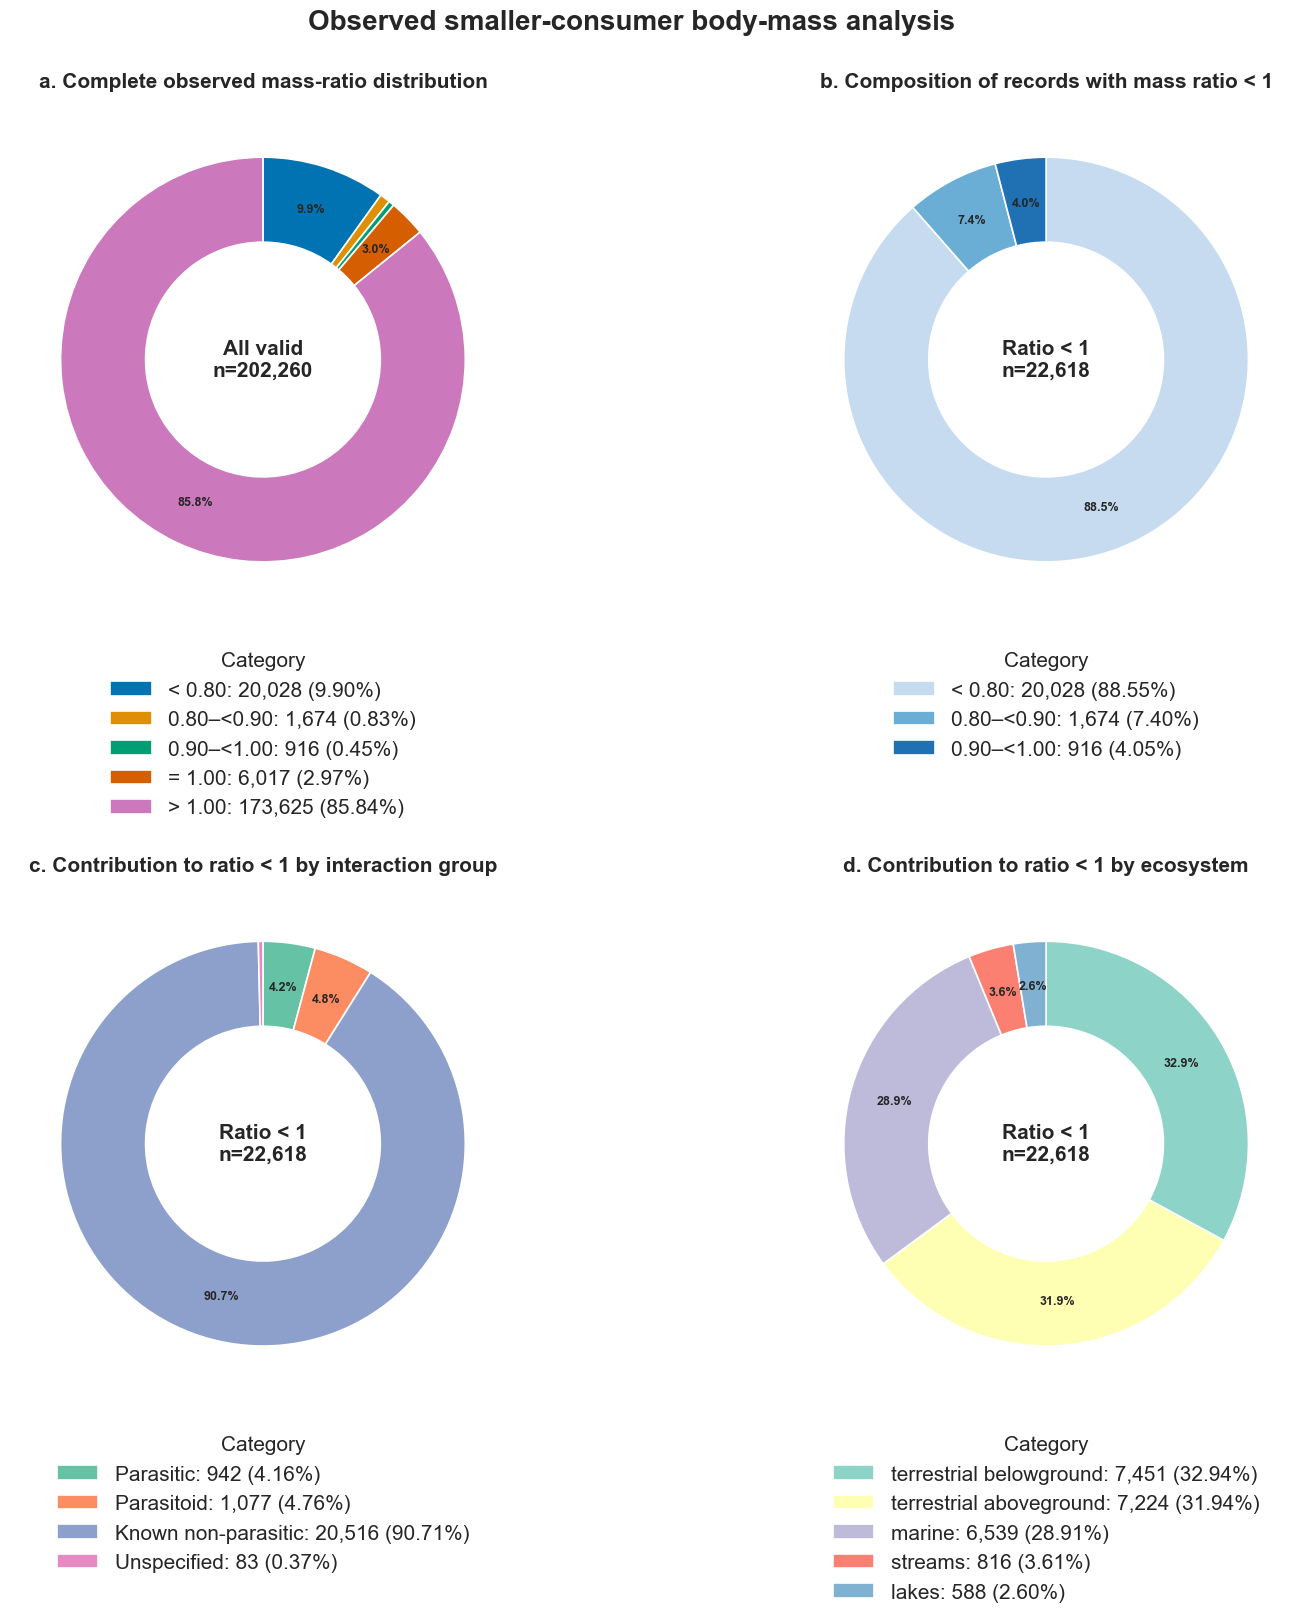

In [4]:
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# Configuration
# ============================================================

SAVE_PIE_CHARTS = False

sns.set_theme(
    style="white",
    context="notebook",
    font_scale=0.95,
)


# ============================================================
# Prepare four small plotting tables with Polars
# ============================================================

# 1. Complete distribution: mutually exclusive categories
overall_pie_pl = (
    mass_ratio_band_summary_df
    .sort("MassRatioBandOrder")
    .select(
        pl.col("MassRatioBand").alias("Category"),
        pl.col("Links").alias("Count"),
    )
)


# 2. Composition inside the mass-ratio < 1 group
lt1_pie_pl = (
    mass_ratio_band_summary_df
    .filter(
        pl.col("MassRatioBandOrder") <= 3
    )
    .sort("MassRatioBandOrder")
    .select(
        pl.col("MassRatioBand").alias("Category"),
        pl.col("Links").alias("Count"),
    )
)


# 3. Contribution to <1 by interaction group
interaction_pie_pl = (
    parasite_comparison_df
    .select(
        pl.col("InteractionGroup").alias("Category"),
        pl.col("RatioLT1").alias("Count"),
    )
    .filter(
        pl.col("Count") > 0
    )
)


# 4. Contribution to <1 by ecosystem
ecosystem_pie_pl = (
    ecosystem_summary_df
    .select(
        pl.col("Ecosystem").alias("Category"),
        pl.col("RatioLT1").alias("Count"),
    )
    .filter(
        pl.col("Count") > 0
    )
    .sort(
        "Count",
        descending=True,
    )
)


# Convert only these small summaries to pandas
overall_pie_pd = pd.DataFrame(
    overall_pie_pl.to_dicts()
)

lt1_pie_pd = pd.DataFrame(
    lt1_pie_pl.to_dicts()
)

interaction_pie_pd = pd.DataFrame(
    interaction_pie_pl.to_dicts()
)

ecosystem_pie_pd = pd.DataFrame(
    ecosystem_pie_pl.to_dicts()
)


# ============================================================
# Helpers
# ============================================================

def format_autopct(
    minimum_visible_pct=1.0,
):
    """
    Hide percentages smaller than the selected threshold.
    Exact values remain available in the legend.
    """
    def formatter(percentage):
        if percentage >= minimum_visible_pct:
            return f"{percentage:.1f}%"

        return ""

    return formatter


def draw_donut(
    axis,
    dataframe,
    title,
    centre_text,
    palette_name="colorblind",
    minimum_visible_pct=1.0,
):
    values = dataframe["Count"].to_numpy()
    categories = dataframe["Category"].tolist()

    total = values.sum()

    colours = sns.color_palette(
        palette_name,
        n_colors=len(dataframe),
    )

    wedges, _, _ = axis.pie(
        values,
        colors=colours,
        startangle=90,
        counterclock=False,
        autopct=format_autopct(
            minimum_visible_pct
        ),
        pctdistance=0.78,
        wedgeprops={
            "width": 0.42,
            "edgecolor": "white",
            "linewidth": 1.2,
        },
        textprops={
            "fontsize": 9,
            "fontweight": "bold",
        },
    )

    # Text inside the donut
    axis.text(
        0,
        0,
        centre_text,
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold",
    )

    # Exact counts and percentages in legend
    legend_labels = [
        (
            f"{category}: "
            f"{count:,.0f} "
            f"({100 * count / total:.2f}%)"
        )
        for category, count
        in zip(categories, values)
    ]

    axis.legend(
        wedges,
        legend_labels,
        title="Category",
        loc="upper center",
        bbox_to_anchor=(0.5, -0.04),
        frameon=False,
        fontsize=15,
        title_fontsize=15,
    )

    axis.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=14,
    )

    axis.set_aspect("equal")


# ============================================================
# Create the four-panel figure
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 15),
)


draw_donut(
    axis=axes[0, 0],
    dataframe=overall_pie_pd,
    title=(
        "a. Complete observed mass-ratio distribution"
    ),
    centre_text=(
        f"All valid\n"
        f"n={overall_pie_pd['Count'].sum():,}"
    ),
    palette_name="colorblind",
    minimum_visible_pct=1.0,
)


draw_donut(
    axis=axes[0, 1],
    dataframe=lt1_pie_pd,
    title=(
        "b. Composition of records with mass ratio < 1"
    ),
    centre_text=(
        f"Ratio < 1\n"
        f"n={lt1_pie_pd['Count'].sum():,}"
    ),
    palette_name="Blues",
    minimum_visible_pct=1.0,
)


draw_donut(
    axis=axes[1, 0],
    dataframe=interaction_pie_pd,
    title=(
        "c. Contribution to ratio < 1 "
        "by interaction group"
    ),
    centre_text=(
        f"Ratio < 1\n"
        f"n={interaction_pie_pd['Count'].sum():,}"
    ),
    palette_name="Set2",
    minimum_visible_pct=1.0,
)


draw_donut(
    axis=axes[1, 1],
    dataframe=ecosystem_pie_pd,
    title=(
        "d. Contribution to ratio < 1 "
        "by ecosystem"
    ),
    centre_text=(
        f"Ratio < 1\n"
        f"n={ecosystem_pie_pd['Count'].sum():,}"
    ),
    palette_name="Set3",
    minimum_visible_pct=1.0,
)


fig.suptitle(
    "Observed smaller-consumer body-mass analysis",
    fontsize=20,
    fontweight="bold",
    y=0.995,
)

fig.subplots_adjust(
    top=0.93,
    bottom=0.07,
    hspace=0.55,
    wspace=0.28,
)

plt.show()

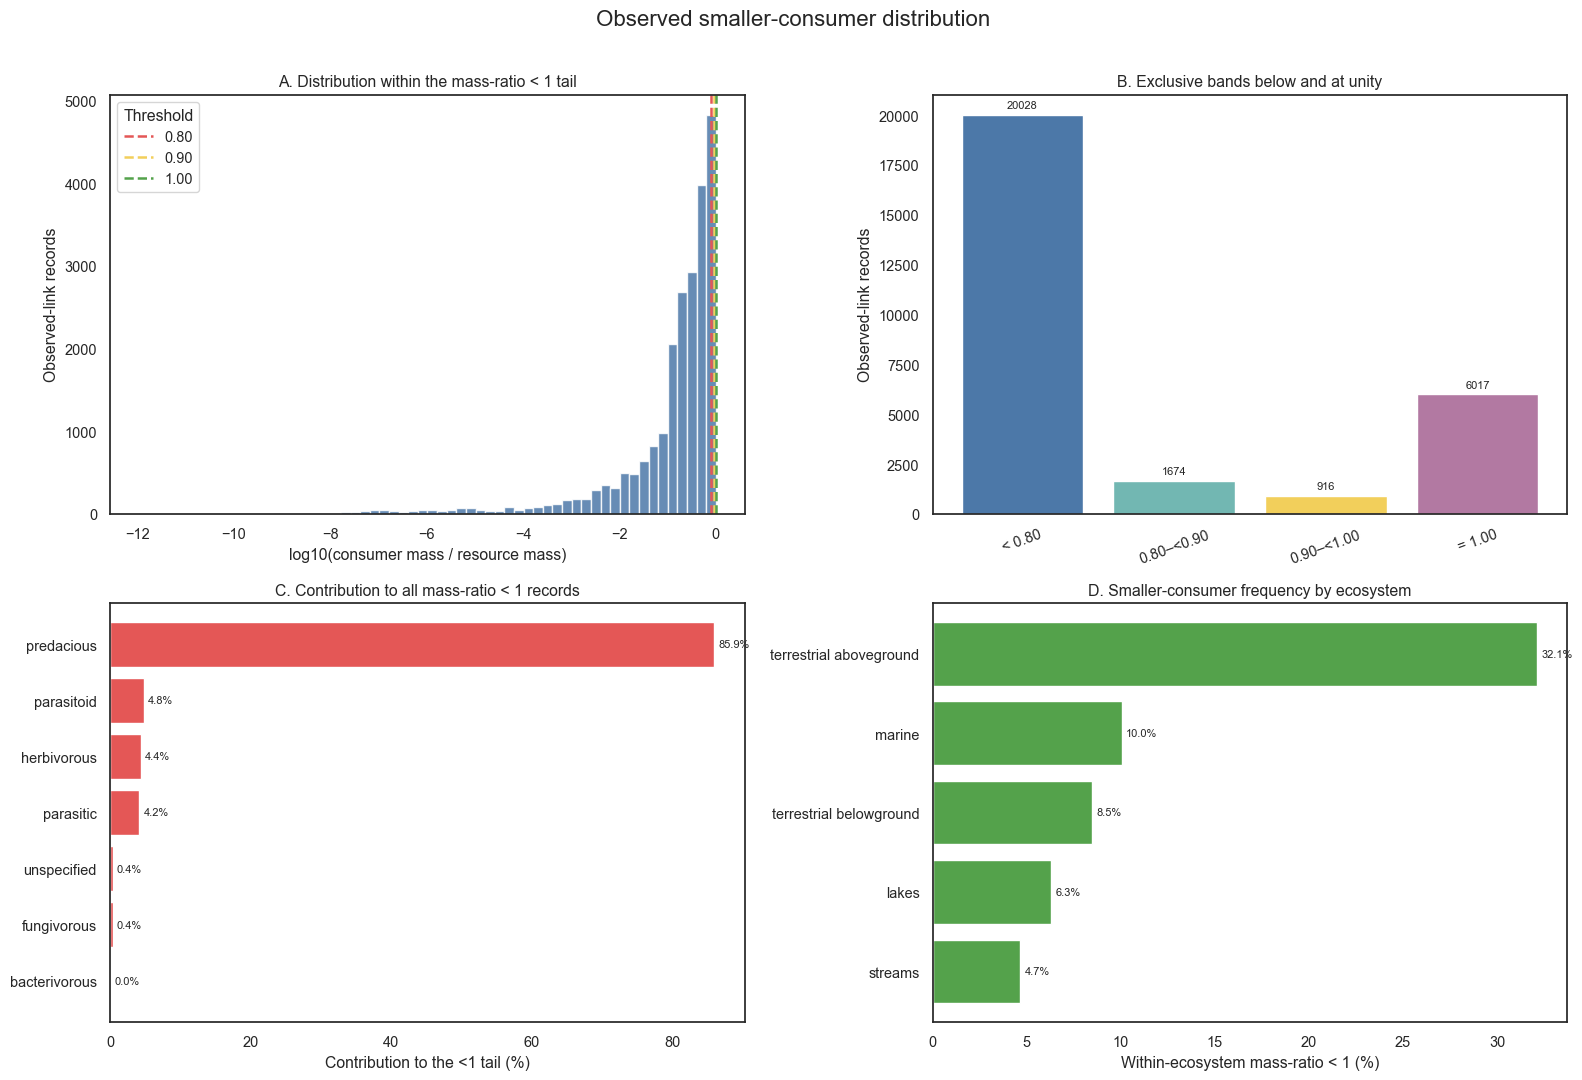

In [5]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 11),
)


# ============================================================
# Panel A — Distribution inside the <1 tail
# ============================================================

tail_log_ratios = (
    smaller_consumer_links_df
    .get_column("Log10MassRatio")
    .to_numpy()
)

axes[0, 0].hist(
    tail_log_ratios,
    bins=60,
    color="#4C78A8",
    alpha=0.85,
)

threshold_colours = {
    0.80: "#E45756",
    0.90: "#F2CF5B",
    1.00: "#54A24B",
}

for tau, colour in threshold_colours.items():
    axes[0, 0].axvline(
        np.log10(tau),
        color=colour,
        linestyle="--",
        linewidth=1.8,
        label=f"{tau:.2f}",
    )

axes[0, 0].set_title(
    "A. Distribution within the mass-ratio < 1 tail"
)

axes[0, 0].set_xlabel(
    "log10(consumer mass / resource mass)"
)

axes[0, 0].set_ylabel(
    "Observed-link records"
)

axes[0, 0].legend(
    title="Threshold"
)


# ============================================================
# Panel B — Exclusive bands
# ============================================================

focused_bands_df = (
    mass_ratio_band_summary_df
    .filter(
        pl.col("MassRatioBandOrder") <= 4
    )
)

band_bars = axes[0, 1].bar(
    focused_bands_df
    .get_column("MassRatioBand")
    .to_list(),

    focused_bands_df
    .get_column("Links")
    .to_list(),

    color=[
        "#4C78A8",
        "#72B7B2",
        "#F2CF5B",
        "#B279A2",
    ],
)

axes[0, 1].bar_label(
    band_bars,
    fmt="%.0f",
    padding=3,
    fontsize=8,
)

axes[0, 1].set_title(
    "B. Exclusive bands below and at unity"
)

axes[0, 1].set_ylabel(
    "Observed-link records"
)

axes[0, 1].tick_params(
    axis="x",
    rotation=20,
)


# ============================================================
# Panel C — Interaction contribution
# ============================================================

interaction_plot_df = (
    interaction_summary_df
    .filter(
        pl.col("RatioLT1").is_not_null()
    )
    .sort("TailContributionPct")
)

interaction_bars = axes[1, 0].barh(
    interaction_plot_df
    .get_column("InteractionType")
    .to_list(),

    interaction_plot_df
    .get_column("TailContributionPct")
    .to_list(),

    color="#E45756",
)

axes[1, 0].bar_label(
    interaction_bars,
    fmt="%.1f%%",
    padding=3,
    fontsize=8,
)

axes[1, 0].set_title(
    "C. Contribution to all mass-ratio < 1 records"
)

axes[1, 0].set_xlabel(
    "Contribution to the <1 tail (%)"
)


# ============================================================
# Panel D — Ecosystem frequency
# ============================================================

ecosystem_plot_df = (
    ecosystem_summary_df
    .sort("WithinGroupLT1Pct")
)

ecosystem_bars = axes[1, 1].barh(
    ecosystem_plot_df
    .get_column("Ecosystem")
    .to_list(),

    ecosystem_plot_df
    .get_column("WithinGroupLT1Pct")
    .to_list(),

    color="#54A24B",
)

axes[1, 1].bar_label(
    ecosystem_bars,
    fmt="%.1f%%",
    padding=3,
    fontsize=8,
)

axes[1, 1].set_title(
    "D. Smaller-consumer frequency by ecosystem"
)

axes[1, 1].set_xlabel(
    "Within-ecosystem mass-ratio < 1 (%)"
)


fig.suptitle(
    "Observed smaller-consumer distribution",
    fontsize=16,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.97]
)

plt.show()

In [6]:
overall = (
    overall_mass_ratio_df
    .to_dicts()[0]
)

nonself = (
    nonself_mass_ratio_df
    .to_dicts()[0]
)

threshold_rows = {
    row["TauMass"]: row
    for row in threshold_summary_df.to_dicts()
}

group_rows = {
    row["InteractionGroup"]: row
    for row in parasite_comparison_df.to_dicts()
}

top_known_nonparasitic = (
    known_nonparasitic_contributors_df
    .filter(
        pl.col("RatioLT1").is_not_null()
    )
    .sort(
        "RatioLT1",
        descending=True,
    )
    .row(
        0,
        named=True,
    )
)

top_ecosystem_frequency = (
    ecosystems_by_frequency_df
    .row(
        0,
        named=True,
    )
)

top_ecosystem_count = (
    ecosystems_by_tail_count_df
    .row(
        0,
        named=True,
    )
)

parasitic_tail_count = (
    group_rows["Parasitic"]["RatioLT1"]
    + group_rows["Parasitoid"]["RatioLT1"]
)

parasitic_tail_pct = (
    100
    * parasitic_tail_count
    / TOTAL_LT1
)

known_nonparasitic_tail_pct = (
    group_rows[
        "Known non-parasitic"
    ]["TailContributionPct"]
)

self_loop_count = (
    valid_links
    .filter(
        pl.col("IsSelfLoop")
    )
    .height
)

self_loop_equal_count = (
    valid_links
    .filter(
        pl.col("IsSelfLoop")
        & pl.col("EqualMass")
    )
    .height
)


supervisor_interpretation = f"""
Among {overall['ValidLinks']:,} observed-link records with finite,
positive consumer and resource masses, {overall['RatioLT1']:,}
({overall['WithinGroupLT1Pct']:.2f}%) have a consumer lighter than
its resource. A further {overall['RatioEQ1']:,}
({overall['WithinGroupEQ1Pct']:.2f}%) have equal consumer and
resource masses.

The cumulative proportions below tau_mass = 0.80, 0.90 and 1.00
are {threshold_rows[0.8]['BelowThresholdPctOfValid']:.2f}%,
{threshold_rows[0.9]['BelowThresholdPctOfValid']:.2f}% and
{threshold_rows[1.0]['BelowThresholdPctOfValid']:.2f}%,
respectively.

Parasitic and parasitoid interactions have high within-group
frequencies of smaller consumers, but together account for only
{parasitic_tail_count:,} records ({parasitic_tail_pct:.2f}%)
of the complete <1 tail. Known non-parasitic interactions account
for {known_nonparasitic_tail_pct:.2f}% of that tail. The largest
known non-parasitic contribution comes from
{top_known_nonparasitic['InteractionType']} interactions:
{top_known_nonparasitic['RatioLT1']:,} records, representing
{top_known_nonparasitic['KnownNonParasiticTailContributionPct']:.2f}%
of the known non-parasitic tail.

The highest within-ecosystem smaller-consumer frequency occurs in
{top_ecosystem_frequency['Ecosystem']}
({top_ecosystem_frequency['WithinGroupLT1Pct']:.2f}%).
The largest absolute contribution comes from
{top_ecosystem_count['Ecosystem']}
({top_ecosystem_count['RatioLT1']:,} records).

There are {self_loop_count:,} valid self-loop records, including
{self_loop_equal_count:,} with equal masses. Excluding self-loops
changes the <1 frequency to
{nonself['WithinGroupLT1Pct']:.2f}% and the =1 frequency to
{nonself['WithinGroupEQ1Pct']:.2f}%.

These results show that mass_ratio < tau_mass should be interpreted
as a negative-sampling preference, not as an ecological impossibility
criterion. Genuine observed interactions also satisfy each candidate
threshold. Lowering tau_mass reduces, but does not eliminate, the
possibility of treating ecologically plausible smaller-consumer
interactions as negative candidates.
""".strip()


display(
    Markdown(
        "### Concise interpretation for supervisor review"
    )
)

print(supervisor_interpretation)


# ============================================================
# Export reproducible artifacts
# ============================================================

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    export_tables = {
        "data_quality_overall.csv": (
            data_quality_overall_df
        ),
        "scope_sensitivity_self_loops.csv": (
            scope_sensitivity_df
        ),
        "threshold_summary_0p80_0p90_1p00.csv": (
            threshold_summary_df
        ),
        "mass_ratio_exclusive_bands.csv": (
            mass_ratio_band_summary_df
        ),
        "focused_lt1_table.csv": (
            focused_lt1_table_df
        ),
        "mass_coverage_by_interaction.csv": (
            coverage_by_interaction_df
        ),
        "mass_ratio_by_interaction.csv": (
            interaction_summary_df
        ),
        "parasite_comparison.csv": (
            parasite_comparison_df
        ),
        "known_nonparasitic_lt1_contributors.csv": (
            known_nonparasitic_contributors_df
        ),
        "mass_coverage_by_ecosystem.csv": (
            coverage_by_ecosystem_df
        ),
        "mass_ratio_by_ecosystem.csv": (
            ecosystem_summary_df
        ),
        "mass_ratio_by_foodweb_290.csv": (
            foodweb_summary_df
        ),
        "self_loop_summary.csv": (
            self_loop_summary_df
        ),
        "repeated_binary_pair_audit.csv": (
            duplicate_binary_edge_audit_df
        ),
        "repeated_binary_pair_groups.csv": (
            duplicate_binary_edge_groups_df
        ),
        "mixed_ecosystem_foodwebs.csv": (
            mixed_ecosystem_foodwebs_df
        ),
        "smaller_consumer_links_lt1.csv": (
            smaller_consumer_links_export_df
        ),
        "equal_mass_links_eq1.csv": (
            equal_mass_links_export_df
        ),
    }

    for filename, dataframe in export_tables.items():
        dataframe.write_csv(
            OUTPUT_DIR / filename
        )

    figure_path = (
        OUTPUT_DIR
        / "observed_smaller_consumer_distribution.png"
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    interpretation_path = (
        OUTPUT_DIR
        / "supervisor_interpretation.txt"
    )

    interpretation_path.write_text(
        supervisor_interpretation + "\n",
        encoding="utf-8",
    )

    print(
        "\nArtifacts saved in:"
    )

    print(OUTPUT_DIR)

    print(
        "\nMain figure:"
    )

    print(figure_path)

### Concise interpretation for supervisor review

Among 202,260 observed-link records with finite,
positive consumer and resource masses, 22,618
(11.18%) have a consumer lighter than
its resource. A further 6,017
(2.97%) have equal consumer and
resource masses.

The cumulative proportions below tau_mass = 0.80, 0.90 and 1.00
are 9.90%,
10.73% and
11.18%,
respectively.

Parasitic and parasitoid interactions have high within-group
frequencies of smaller consumers, but together account for only
2,019 records (8.93%)
of the complete <1 tail. Known non-parasitic interactions account
for 90.71% of that tail. The largest
known non-parasitic contribution comes from
predacious interactions:
19,440 records, representing
94.76%
of the known non-parasitic tail.

The highest within-ecosystem smaller-consumer frequency occurs in
terrestrial aboveground
(32.12%).
The largest absolute contribution comes from
terrestrial belowground
(7,451 records).

There are 3,341 valid self-loop records, including
3,318 with equal masses. Excluding self-loops
chang

## 2. Audit Body-Mass Eligibility Thresholds

<!-- POOL_AUDIT_IMPLEMENTATION_V1 -->
### 2.1 Candidate-pool audit across body-mass thresholds

This audit evaluates the negative-candidate pools for the role-only baseline and
for `tau_mass = 0.80`, `0.90`, and `1.00` across all 290 food webs.

The implemented rule in `sample_neg_dir_neg.m` is:

$$
\mathrm{mass}(\mathrm{target})
<
\tau_{\mathrm{mass}}
\,\mathrm{mass}(\mathrm{source}).
$$

In the directed food-web representation, the source is the resource and the
target is the consumer. Therefore, this is equivalent to:

$$
\frac{\mathrm{consumer\ mass}}
     {\mathrm{resource\ mass}}
<
\tau_{\mathrm{mass}}.
$$

This implementation-level verification replaces the pending supervisor
confirmation for the current audit. Body mass is treated as an eligibility
preference for negative sampling, not as a rule declaring interactions
biologically impossible.

The `CheckConnectivity=false` runs are used as the canonical source for the
candidate-pool counts. The existing connectivity analysis is retained separately
in Section 2.2.

In [7]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from IPython.display import display, Markdown


# ============================================================
# Candidate-pool audit configuration
# ============================================================

POOL_AUDIT_ROOT = Path(
    "/Users/acw792/Developer/qmul-phd-framework"
)

POOL_AUDIT_DATA_DIR = (
    POOL_AUDIT_ROOT
    / "src"
    / "matlab"
    / "data"
)

POOL_AUDIT_BASELINE_CSV = (
    POOL_AUDIT_DATA_DIR
    / "performance_207_constraint_sufficient_webs"
    / "foodweb_negative_constraint_pool_status.csv"
)

POOL_AUDIT_SCENARIOS = {
    "tau=0.80": {
        "tau": 0.80,
        "order": 1,
        "folder": POOL_AUDIT_DATA_DIR / (
            "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_"
            "randomeligible_roleormass_tau0p80_checkconnfalse_"
            "adaptivefalse_Apocrita"
        ),
    },
    "tau=0.90": {
        "tau": 0.90,
        "order": 2,
        "folder": POOL_AUDIT_DATA_DIR / (
            "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_"
            "randomeligible_roleormass_tau0p90_checkconnfalse_"
            "adaptivefalse_Apocrita"
        ),
    },
    "tau=1.00": {
        "tau": 1.00,
        "order": 3,
        "folder": POOL_AUDIT_DATA_DIR / (
            "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_"
            "randomeligible_roleormass_tau1p00_checkconnfalse_"
            "adaptivefalse_Apocrita"
        ),
    },
}

POOL_AUDIT_OUTPUT_DIR = (
    POOL_AUDIT_DATA_DIR
    / "audit_body_mass_eligibility_thresholds_290_foodwebs"
)

SAVE_POOL_AUDIT_OUTPUTS = False
EXPECTED_POOL_AUDIT_FOODWEBS = 290
EXPECTED_NEGPOOL_LINES_PER_LOG = 50 * 9


def read_key_value_manifest(path: Path) -> dict[str, str]:
    values = {}

    for line in path.read_text().splitlines():
        if "=" in line:
            key, value = line.split("=", 1)
            values[key] = value

    return values


manifest_rows = []

for scenario, configuration in POOL_AUDIT_SCENARIOS.items():
    folder = configuration["folder"]
    manifest_path = folder / "RUN_MANIFEST.txt"
    log_files = sorted(
        (folder / "terminal_logs").glob(
            "*_wlnm_dir_neg_terminal_log.txt"
        )
    )

    assert folder.is_dir(), folder
    assert manifest_path.is_file(), manifest_path
    assert len(log_files) == EXPECTED_POOL_AUDIT_FOODWEBS, (
        scenario,
        len(log_files),
    )

    manifest_values = read_key_value_manifest(
        manifest_path
    )

    assert float(manifest_values["TauMass"]) == configuration["tau"]
    assert manifest_values["CheckConnectivity"] == "false"
    assert manifest_values["AdaptiveConnectivity"] == "false"
    assert manifest_values["Eligibility"] == "role_or_mass"
    assert manifest_values["NegativeSampling"] == "random_eligible_pool"
    assert manifest_values["MassEligibilityEnabled"] == "true"
    assert int(manifest_values["FoodWebs"]) == EXPECTED_POOL_AUDIT_FOODWEBS
    assert int(manifest_values["NumExperiments"]) == 50

    manifest_rows.append({
        "Scenario": scenario,
        "TauMass": configuration["tau"],
        "FoodWebs": len(log_files),
        "CheckConnectivity": manifest_values[
            "CheckConnectivity"
        ],
        "Eligibility": manifest_values["Eligibility"],
        "NegativeSampling": manifest_values[
            "NegativeSampling"
        ],
        "ExperimentsPerFoodWeb": int(
            manifest_values["NumExperiments"]
        ),
        "TrainRatios": manifest_values[
            "TrainRatioRange"
        ],
        "SourceCommit": manifest_values["SourceCommit"],
    })


pool_audit_manifest_df = (
    pl.DataFrame(manifest_rows)
    .sort("TauMass")
)

print("Candidate-pool audit inputs")

display(
    pd.DataFrame(
        pool_audit_manifest_df.to_dicts()
    )
)


Candidate-pool audit inputs


,Scenario,TauMass,FoodWebs,CheckConnectivity,Eligibility,NegativeSampling,ExperimentsPerFoodWeb,TrainRatios,SourceCommit
0,tau=0.80,0.8,290,false,role_or_mass,random_eligible_pool,50,0.10:0.10:0.90,e723032d6c
1,tau=0.90,0.9,290,false,role_or_mass,random_eligible_pool,50,0.10:0.10:0.90,e723032d6c
2,tau=1.00,1.0,290,false,role_or_mass,random_eligible_pool,50,0.10:0.10:0.90,e723032d6c


In [8]:
# ============================================================
# Parse one stable [NegPool] signature per food web/scenario
# ============================================================

NEGPOOL_VALUE_PATTERN = re.compile(
    r"([A-Za-z_]+)=([^\s|]+)"
)

NEGPOOL_INTEGER_FIELDS = [
    "role_pool",
    "full_pool",
    "need_total",
    "requested_need",
    "eligible_shortfall",
    "full_pool_shortfall",
    "a",
    "eval_all",
    "role_filter",
    "mass_filter",
    "mass_pool",
    "eligible_pool",
    "eligible_neg",
    "random_topup",
]

NEGPOOL_TEXT_FIELDS = [
    "mode",
    "strategy",
    "eligibility",
]

NEGPOOL_SIGNATURE_FIELDS = [
    *NEGPOOL_TEXT_FIELDS,
    *NEGPOOL_INTEGER_FIELDS,
]


def parse_negpool_log(
    log_path: Path,
    scenario: str,
    tau_mass: float,
    scenario_order: int,
) -> dict:

    signatures = {}
    number_pool_lines = 0

    for line in log_path.read_text(
        errors="replace"
    ).splitlines():
        if not line.startswith("[NegPool]"):
            continue

        number_pool_lines += 1
        values = dict(
            NEGPOOL_VALUE_PATTERN.findall(line)
        )

        missing_fields = [
            field
            for field in NEGPOOL_SIGNATURE_FIELDS
            if field not in values
        ]

        if missing_fields:
            raise ValueError(
                f"{log_path.name}: missing fields "
                f"{missing_fields}"
            )

        record = {
            field: values[field]
            for field in NEGPOOL_TEXT_FIELDS
        }

        record.update({
            field: int(values[field])
            for field in NEGPOOL_INTEGER_FIELDS
        })

        signature = tuple(
            record[field]
            for field in NEGPOOL_SIGNATURE_FIELDS
        )

        signatures[signature] = record

    assert (
        number_pool_lines
        == EXPECTED_NEGPOOL_LINES_PER_LOG
    ), (
        log_path.name,
        number_pool_lines,
    )

    assert len(signatures) == 1, (
        log_path.name,
        len(signatures),
    )

    record = next(iter(signatures.values()))

    assert record["strategy"] == "random_eligible_pool"
    assert record["eligibility"] == "role_or_mass"
    assert record["role_filter"] == 1
    assert record["mass_filter"] == 1
    assert record["eval_all"] == 0
    assert record["a"] == 2

    foodweb = log_path.name.removesuffix(
        "_wlnm_dir_neg_terminal_log.txt"
    )

    return {
        "Scenario": scenario,
        "ScenarioOrder": scenario_order,
        "TauMass": tau_mass,
        "FoodWeb": foodweb,
        "FoodWebLabel": foodweb.removesuffix(
            "_tax_mass"
        ),
        "RequiredNegatives": record[
            "requested_need"
        ],
        "NeedTotal": record["need_total"],
        "FullPool": record["full_pool"],
        "RolePool": record["role_pool"],
        "MassPool": record["mass_pool"],
        "EligiblePool": record["eligible_pool"],
        "EligibleShortfall": record[
            "eligible_shortfall"
        ],
        "FullPoolShortfall": record[
            "full_pool_shortfall"
        ],
        "EligibleNegatives": record[
            "eligible_neg"
        ],
        "RandomTopUp": record["random_topup"],
        "NegPoolLines": number_pool_lines,
        "UniquePoolSignatures": len(signatures),
    }


threshold_pool_rows = []

for scenario, configuration in POOL_AUDIT_SCENARIOS.items():
    log_files = sorted(
        (
            configuration["folder"]
            / "terminal_logs"
        ).glob(
            "*_wlnm_dir_neg_terminal_log.txt"
        )
    )

    for log_path in log_files:
        threshold_pool_rows.append(
            parse_negpool_log(
                log_path=log_path,
                scenario=scenario,
                tau_mass=configuration["tau"],
                scenario_order=configuration["order"],
            )
        )


threshold_pool_raw_df = (
    pl.DataFrame(threshold_pool_rows)
    .sort([
        "ScenarioOrder",
        "FoodWeb",
    ])
)

assert threshold_pool_raw_df.height == (
    EXPECTED_POOL_AUDIT_FOODWEBS
    * len(POOL_AUDIT_SCENARIOS)
)

assert (
    threshold_pool_raw_df
    .group_by("Scenario")
    .agg(
        pl.col("FoodWeb")
        .n_unique()
        .alias("FoodWebs")
    )
    .get_column("FoodWebs")
    == EXPECTED_POOL_AUDIT_FOODWEBS
).all()

print(
    "Stable threshold-pool records:",
    threshold_pool_raw_df.height,
)


Stable threshold-pool records: 870


In [9]:
# ============================================================
# Add ecosystems and derive overlap, mass-only and top-up fields
# ============================================================

role_only_source_df = pl.read_csv(
    POOL_AUDIT_BASELINE_CSV
)

assert (
    role_only_source_df.height
    == EXPECTED_POOL_AUDIT_FOODWEBS
)

assert (
    role_only_source_df
    .get_column("Foodweb")
    .n_unique()
    == EXPECTED_POOL_AUDIT_FOODWEBS
)

ecosystem_lookup_df = (
    role_only_source_df
    .select(
        pl.col("Foodweb").alias("FoodWeb"),
        pl.col("EcosystemType").alias(
            "Ecosystem"
        ),
    )
)

threshold_pool_df = (
    threshold_pool_raw_df
    .join(
        ecosystem_lookup_df,
        on="FoodWeb",
        how="left",
        validate="m:1",
    )
    .with_columns(
        (
            pl.col("RolePool")
            + pl.col("MassPool")
            - pl.col("EligiblePool")
        ).alias("RoleMassOverlap"),

        (
            pl.col("EligiblePool")
            - pl.col("RolePool")
        ).alias("MassOnlyCandidates"),

        (
            pl.col("RandomTopUp") > 0
        ).alias("RequiresTopUp"),

        pl.when(
            pl.col("RequiredNegatives") > 0
        )
        .then(
            100.0
            * pl.col("RandomTopUp")
            / pl.col("RequiredNegatives")
        )
        .otherwise(None)
        .alias("TopUpProportionPct"),

        pl.when(
            pl.col("RequiredNegatives") > 0
        )
        .then(
            pl.col("EligiblePool")
            / pl.col("RequiredNegatives")
        )
        .otherwise(None)
        .alias("EligibleCapacityRatio"),
    )
)

assert (
    threshold_pool_df
    .get_column("Ecosystem")
    .null_count()
    == 0
)

assert (
    threshold_pool_df
    .filter(
        (pl.col("RoleMassOverlap") < 0)
        | (
            pl.col("RoleMassOverlap")
            > pl.min_horizontal(
                "RolePool",
                "MassPool",
            )
        )
        | (pl.col("MassOnlyCandidates") < 0)
    )
    .is_empty()
)

assert (
    threshold_pool_df
    .filter(
        pl.col("RandomTopUp")
        != pl.col("EligibleShortfall")
    )
    .is_empty()
)


# ============================================================
# Build a comparable role-only baseline
# ============================================================

role_only_pool_df = (
    role_only_source_df
    .select(
        pl.lit("Role-only").alias("Scenario"),
        pl.lit(0).alias("ScenarioOrder"),
        pl.lit(None)
        .cast(pl.Float64)
        .alias("TauMass"),
        pl.col("Foodweb").alias("FoodWeb"),
        pl.col("Foodweb")
        .str.replace(r"_tax_mass$", "")
        .alias("FoodWebLabel"),
        pl.col("EcosystemType").alias(
            "Ecosystem"
        ),
        pl.col("negative_needed")
        .cast(pl.Int64)
        .alias("RequiredNegatives"),
        pl.min_horizontal(
            pl.col("negative_needed"),
            pl.col("full_valid_nonlink_pool"),
        )
        .cast(pl.Int64)
        .alias("NeedTotal"),
        pl.col("full_valid_nonlink_pool")
        .cast(pl.Int64)
        .alias("FullPool"),
        pl.col("role_constrained_pool")
        .cast(pl.Int64)
        .alias("RolePool"),
        pl.lit(None)
        .cast(pl.Int64)
        .alias("MassPool"),
        pl.lit(None)
        .cast(pl.Int64)
        .alias("RoleMassOverlap"),
        pl.col("role_constrained_pool")
        .cast(pl.Int64)
        .alias("EligiblePool"),
        pl.lit(0)
        .cast(pl.Int64)
        .alias("MassOnlyCandidates"),
        (
            pl.col("negative_needed")
            - pl.col("role_constrained_pool")
        )
        .clip(lower_bound=0)
        .cast(pl.Int64)
        .alias("EligibleShortfall"),
        (
            pl.col("negative_needed")
            - pl.col("full_valid_nonlink_pool")
        )
        .clip(lower_bound=0)
        .cast(pl.Int64)
        .alias("FullPoolShortfall"),
        pl.min_horizontal(
            pl.col("negative_needed"),
            pl.col("role_constrained_pool"),
        )
        .cast(pl.Int64)
        .alias("EligibleNegatives"),
        pl.col(
            "random_topup_needed_if_full_sample"
        )
        .cast(pl.Int64)
        .alias("RandomTopUp"),
        pl.col("requires_random_topup")
        .alias("RequiresTopUp"),
        (
            100.0
            * pl.col(
                "random_topup_needed_if_full_sample"
            )
            / pl.col("negative_needed")
        ).alias("TopUpProportionPct"),
        (
            pl.col("role_constrained_pool")
            / pl.col("negative_needed")
        ).alias("EligibleCapacityRatio"),
        pl.lit(None)
        .cast(pl.Int64)
        .alias("NegPoolLines"),
        pl.lit(None)
        .cast(pl.Int64)
        .alias("UniquePoolSignatures"),
    )
)


POOL_AUDIT_COLUMN_ORDER = [
    "Scenario",
    "ScenarioOrder",
    "TauMass",
    "FoodWeb",
    "FoodWebLabel",
    "Ecosystem",
    "RequiredNegatives",
    "NeedTotal",
    "FullPool",
    "RolePool",
    "MassPool",
    "RoleMassOverlap",
    "EligiblePool",
    "MassOnlyCandidates",
    "EligibleShortfall",
    "FullPoolShortfall",
    "EligibleNegatives",
    "RandomTopUp",
    "TopUpProportionPct",
    "RequiresTopUp",
    "EligibleCapacityRatio",
    "NegPoolLines",
    "UniquePoolSignatures",
]

pool_audit_by_web_df = (
    pl.concat(
        [
            role_only_pool_df.select(
                POOL_AUDIT_COLUMN_ORDER
            ),
            threshold_pool_df.select(
                POOL_AUDIT_COLUMN_ORDER
            ),
        ],
        how="vertical_relaxed",
    )
    .sort([
        "ScenarioOrder",
        "FoodWeb",
    ])
)

assert pool_audit_by_web_df.height == (
    EXPECTED_POOL_AUDIT_FOODWEBS * 4
)


# ============================================================
# Cross-scenario identity and monotonicity checks
# ============================================================

baseline_identity_df = (
    threshold_pool_df
    .join(
        role_only_pool_df.select(
            "FoodWeb",
            pl.col("RequiredNegatives").alias(
                "BaselineRequiredNegatives"
            ),
            pl.col("FullPool").alias(
                "BaselineFullPool"
            ),
            pl.col("RolePool").alias(
                "BaselineRolePool"
            ),
        ),
        on="FoodWeb",
        how="left",
        validate="m:1",
    )
)

assert (
    baseline_identity_df
    .filter(
        (pl.col("RequiredNegatives")
         != pl.col("BaselineRequiredNegatives"))
        | (
            pl.col("FullPool")
            != pl.col("BaselineFullPool")
        )
        | (
            pl.col("RolePool")
            != pl.col("BaselineRolePool")
        )
    )
    .is_empty()
)


def threshold_side(
    tau_mass: float,
    suffix: str,
) -> pl.DataFrame:

    return (
        threshold_pool_df
        .filter(
            pl.col("TauMass") == tau_mass
        )
        .select(
            "FoodWeb",
            *[
                pl.col(column).alias(
                    f"{column}_{suffix}"
                )
                for column in [
                    "MassPool",
                    "EligiblePool",
                    "EligibleShortfall",
                    "RandomTopUp",
                ]
            ],
        )
    )


pool_monotonicity_df = (
    threshold_side(0.80, "0p80")
    .join(
        threshold_side(0.90, "0p90"),
        on="FoodWeb",
        how="inner",
        validate="1:1",
    )
    .join(
        threshold_side(1.00, "1p00"),
        on="FoodWeb",
        how="inner",
        validate="1:1",
    )
)

assert pool_monotonicity_df.height == (
    EXPECTED_POOL_AUDIT_FOODWEBS
)

assert (
    pool_monotonicity_df
    .filter(
        (pl.col("MassPool_0p80")
         > pl.col("MassPool_0p90"))
        | (
            pl.col("MassPool_0p90")
            > pl.col("MassPool_1p00")
        )
        | (
            pl.col("EligiblePool_0p80")
            > pl.col("EligiblePool_0p90")
        )
        | (
            pl.col("EligiblePool_0p90")
            > pl.col("EligiblePool_1p00")
        )
        | (
            pl.col("EligibleShortfall_0p80")
            < pl.col("EligibleShortfall_0p90")
        )
        | (
            pl.col("EligibleShortfall_0p90")
            < pl.col("EligibleShortfall_1p00")
        )
        | (
            pl.col("RandomTopUp_0p80")
            < pl.col("RandomTopUp_0p90")
        )
        | (
            pl.col("RandomTopUp_0p90")
            < pl.col("RandomTopUp_1p00")
        )
    )
    .is_empty()
)

print(
    "Validated food-web/scenario rows:",
    pool_audit_by_web_df.height,
)

print(
    "All identifiers, baseline fields, set relations, "
    "and threshold monotonicity checks passed."
)


Validated food-web/scenario rows: 1160
All identifiers, baseline fields, set relations, and threshold monotonicity checks passed.


In [10]:
# ============================================================
# Overall and ecosystem summaries
# ============================================================

pool_availability_overall_df = (
    pool_audit_by_web_df
    .group_by([
        "ScenarioOrder",
        "Scenario",
        "TauMass",
    ])
    .agg(
        pl.col("FoodWeb")
        .n_unique()
        .alias("FoodWebs"),

        pl.col("RequiredNegatives")
        .sum()
        .alias("RequiredNegatives"),

        pl.col("RolePool")
        .sum()
        .alias("RolePool"),

        pl.col("MassPool")
        .sum()
        .alias("MassPool"),

        pl.col("RoleMassOverlap")
        .sum()
        .alias("RoleMassOverlap"),

        pl.col("EligiblePool")
        .sum()
        .alias("EligiblePool"),

        pl.col("MassOnlyCandidates")
        .sum()
        .alias("MassOnlyCandidates"),

        (
            pl.col("MassOnlyCandidates") > 0
        )
        .sum()
        .alias("FoodWebsWithMassOnlyCandidates"),

        pl.col("EligibleCapacityRatio")
        .median()
        .alias("MedianEligibleCapacityRatio"),

        pl.col("EligibleShortfall")
        .sum()
        .alias("EligibleShortfall"),

        pl.col("RandomTopUp")
        .sum()
        .alias("RandomTopUp"),

        pl.col("RequiresTopUp")
        .sum()
        .alias("FoodWebsRequiringTopUp"),

        (
            100.0
            * pl.col("RequiresTopUp")
            .cast(pl.Float64)
            .mean()
        ).alias("FoodWebsRequiringTopUpPct"),

        pl.col("TopUpProportionPct")
        .mean()
        .alias("MeanTopUpProportionPct"),

        pl.col("TopUpProportionPct")
        .max()
        .alias("MaxTopUpProportionPct"),
    )
    .sort("ScenarioOrder")
    .with_columns(
        pl.when(
            pl.col("Scenario") == "Role-only"
        )
        .then(None)
        .otherwise(pl.col("MassPool"))
        .alias("MassPool"),

        pl.when(
            pl.col("Scenario") == "Role-only"
        )
        .then(None)
        .otherwise(pl.col("RoleMassOverlap"))
        .alias("RoleMassOverlap"),
    )
)


pool_availability_by_ecosystem_df = (
    pool_audit_by_web_df
    .group_by([
        "ScenarioOrder",
        "Scenario",
        "TauMass",
        "Ecosystem",
    ])
    .agg(
        pl.col("FoodWeb")
        .n_unique()
        .alias("FoodWebs"),

        pl.col("RequiredNegatives")
        .sum()
        .alias("RequiredNegatives"),

        pl.col("RolePool")
        .sum()
        .alias("RolePool"),

        pl.col("MassPool")
        .sum()
        .alias("MassPool"),

        pl.col("EligiblePool")
        .sum()
        .alias("EligiblePool"),

        pl.col("MassOnlyCandidates")
        .sum()
        .alias("MassOnlyCandidates"),

        pl.col("EligibleCapacityRatio")
        .median()
        .alias("MedianEligibleCapacityRatio"),

        pl.col("RandomTopUp")
        .sum()
        .alias("RandomTopUp"),

        pl.col("RequiresTopUp")
        .sum()
        .alias("FoodWebsRequiringTopUp"),

        (
            100.0
            * pl.col("RequiresTopUp")
            .cast(pl.Float64)
            .mean()
        ).alias("FoodWebsRequiringTopUpPct"),
    )
    .sort([
        "ScenarioOrder",
        "Ecosystem",
    ])
    .with_columns(
        pl.when(
            pl.col("Scenario") == "Role-only"
        )
        .then(None)
        .otherwise(pl.col("MassPool"))
        .alias("MassPool")
    )
)


foodwebs_requiring_topup_df = (
    pool_audit_by_web_df
    .filter(
        pl.col("RequiresTopUp")
    )
    .select(
        "Scenario",
        "ScenarioOrder",
        "TauMass",
        "FoodWebLabel",
        "Ecosystem",
        "RequiredNegatives",
        "RolePool",
        "MassPool",
        "RoleMassOverlap",
        "EligiblePool",
        "MassOnlyCandidates",
        "EligibleShortfall",
        "RandomTopUp",
        "TopUpProportionPct",
    )
    .sort([
        "ScenarioOrder",
        "TopUpProportionPct",
    ], descending=[False, True])
)


print("TABLE 2.1A — Pool availability overall")

display(
    pd.DataFrame(
        pool_availability_overall_df.to_dicts()
    ).round(4)
)

print("TABLE 2.1B — Pool availability by ecosystem")

display(
    pd.DataFrame(
        pool_availability_by_ecosystem_df.to_dicts()
    ).round(4)
)

print("TABLE 2.1C — Food webs requiring top-up")

display(
    pd.DataFrame(
        foodwebs_requiring_topup_df.to_dicts()
    ).round(4)
)

print(
    "The complete per-food-web table is available as "
    "`pool_audit_by_web_df` "
    f"({pool_audit_by_web_df.height:,} rows)."
)


TABLE 2.1A — Pool availability overall


,ScenarioOrder,Scenario,TauMass,FoodWebs,RequiredNegatives,RolePool,MassPool,RoleMassOverlap,EligiblePool,MassOnlyCandidates,FoodWebsWithMassOnlyCandidates,MedianEligibleCapacityRatio,EligibleShortfall,RandomTopUp,FoodWebsRequiringTopUp,FoodWebsRequiringTopUpPct,MeanTopUpProportionPct,MaxTopUpProportionPct
0,0,Role-only,NaN,290,435120,567837,NaN,NaN,567837,0,0,1.4886,138417,138417,83,28.6207,13.4184,90.8192
1,1,tau=0.80,0.8,290,435120,567837,955658.0,274791.0,1248704,680867,289,2.1509,225,225,2,0.6897,0.1153,31.0734
2,2,tau=0.90,0.9,290,435120,567837,972477.0,278026.0,1262288,694451,290,2.1791,217,217,2,0.6897,0.1114,29.9435
3,3,tau=1.00,1.0,290,435120,567837,986270.0,280775.0,1273332,705495,290,2.2079,204,204,2,0.6897,0.1051,28.1073


TABLE 2.1B — Pool availability by ecosystem


,ScenarioOrder,Scenario,TauMass,Ecosystem,FoodWebs,RequiredNegatives,RolePool,MassPool,EligiblePool,MassOnlyCandidates,MedianEligibleCapacityRatio,RandomTopUp,FoodWebsRequiringTopUp,FoodWebsRequiringTopUpPct
0,0,Role-only,NaN,lakes,55,19226,46414,NaN,46414,0,2.5631,752,3,5.4545
1,0,Role-only,NaN,marine,134,136316,260180,NaN,260180,0,1.4336,6678,22,16.4179
2,0,Role-only,NaN,streams,28,45922,99181,NaN,99181,0,1.6857,1383,5,17.8571
3,0,Role-only,NaN,terrestrial aboveground,21,45704,73163,NaN,73163,0,2.1429,14874,6,28.5714
4,0,Role-only,NaN,terrestrial belowground,52,187952,88899,NaN,88899,0,0.3395,114730,47,90.3846
5,1,tau=0.80,0.8,lakes,55,19226,46414,42261.0,58049,11635,3.1590,220,1,1.8182
6,1,tau=0.80,0.8,marine,134,136316,260180,425105.0,539915,279735,1.9428,5,1,0.7463
7,1,tau=0.80,0.8,streams,28,45922,99181,46619.0,114793,15612,1.8580,0,0,0.0000
8,1,tau=0.80,0.8,terrestrial aboveground,21,45704,73163,112673.0,149326,76163,2.7361,0,0,0.0000
9,1,tau=0.80,0.8,terrestrial belowground,52,187952,88899,329000.0,386621,297722,2.0085,0,0,0.0000


TABLE 2.1C — Food webs requiring top-up


,Scenario,ScenarioOrder,TauMass,FoodWebLabel,Ecosystem,RequiredNegatives,RolePool,MassPool,RoleMassOverlap,EligiblePool,MassOnlyCandidates,EligibleShortfall,RandomTopUp,TopUpProportionPct
0,Role-only,0,NaN,Skipwith Pond,lakes,708,65,NaN,NaN,65,0,643,643,90.8192
1,Role-only,0,NaN,AEW02,terrestrial belowground,6584,1058,NaN,NaN,1058,0,5526,5526,83.9307
2,Role-only,0,NaN,HEW05,terrestrial belowground,6166,1002,NaN,NaN,1002,0,5164,5164,83.7496
3,Role-only,0,NaN,SEW03,terrestrial belowground,4116,726,NaN,NaN,726,0,3390,3390,82.3615
4,Role-only,0,NaN,AEW49,terrestrial belowground,5668,1065,NaN,NaN,1065,0,4603,4603,81.2103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,tau=0.80,1,0.8,PC1P2,marine,212,120,182.0,95.0,207,87,5,5,2.3585
85,tau=0.90,2,0.9,Skipwith Pond,lakes,708,65,439.0,8.0,496,431,212,212,29.9435
86,tau=0.90,2,0.9,PC1P2,marine,212,120,182.0,95.0,207,87,5,5,2.3585
87,tau=1.00,3,1.0,Skipwith Pond,lakes,708,65,453.0,9.0,509,444,199,199,28.1073


The complete per-food-web table is available as `pool_audit_by_web_df` (1,160 rows).


In [11]:
# ============================================================
# Comparisons with role-only and between thresholds
# ============================================================

role_only_comparison_fields_df = (
    role_only_pool_df
    .select(
        "FoodWeb",
        pl.col("EligiblePool").alias(
            "RoleOnlyEligiblePool"
        ),
        pl.col("EligibleShortfall").alias(
            "RoleOnlyEligibleShortfall"
        ),
        pl.col("RandomTopUp").alias(
            "RoleOnlyRandomTopUp"
        ),
        pl.col("RequiresTopUp").alias(
            "RoleOnlyRequiresTopUp"
        ),
    )
)

threshold_vs_role_by_web_df = (
    threshold_pool_df
    .join(
        role_only_comparison_fields_df,
        on="FoodWeb",
        how="left",
        validate="m:1",
    )
    .with_columns(
        (
            pl.col("EligiblePool")
            - pl.col("RoleOnlyEligiblePool")
        ).alias("EligiblePoolAddedVsRoleOnly"),

        (
            pl.col("RoleOnlyEligibleShortfall")
            - pl.col("EligibleShortfall")
        ).alias("ShortfallReducedVsRoleOnly"),

        (
            pl.col("RoleOnlyRandomTopUp")
            - pl.col("RandomTopUp")
        ).alias("TopUpReducedVsRoleOnly"),

        (
            pl.col("RoleOnlyRequiresTopUp")
            & ~pl.col("RequiresTopUp")
        ).alias("RoleOnlyTopUpResolved"),
    )
)


threshold_vs_role_summary_df = (
    threshold_vs_role_by_web_df
    .group_by([
        "ScenarioOrder",
        "Scenario",
        "TauMass",
    ])
    .agg(
        pl.col("FoodWeb")
        .n_unique()
        .alias("FoodWebs"),

        pl.col("EligiblePoolAddedVsRoleOnly")
        .sum()
        .alias("EligibleCandidatesAdded"),

        pl.col("EligiblePoolAddedVsRoleOnly")
        .median()
        .alias("MedianCandidatesAddedPerFoodWeb"),

        (
            pl.col("EligiblePoolAddedVsRoleOnly") > 0
        )
        .sum()
        .alias("FoodWebsWithCandidatesAdded"),

        pl.col("ShortfallReducedVsRoleOnly")
        .sum()
        .alias("EligibleShortfallReduced"),

        pl.col("TopUpReducedVsRoleOnly")
        .sum()
        .alias("RandomTopUpReduced"),

        pl.col("RoleOnlyTopUpResolved")
        .sum()
        .alias("RoleOnlyTopUpFoodWebsResolved"),

        pl.col("RequiresTopUp")
        .sum()
        .alias("FoodWebsStillRequiringTopUp"),
    )
    .sort("ScenarioOrder")
)


def compare_threshold_pair(
    lower_tau: float,
    upper_tau: float,
) -> dict:

    lower = (
        threshold_pool_df
        .filter(
            pl.col("TauMass") == lower_tau
        )
        .select(
            "FoodWeb",
            *[
                pl.col(column).alias(
                    f"{column}_lower"
                )
                for column in [
                    "EligiblePool",
                    "MassOnlyCandidates",
                    "RandomTopUp",
                    "RequiresTopUp",
                ]
            ],
        )
    )

    upper = (
        threshold_pool_df
        .filter(
            pl.col("TauMass") == upper_tau
        )
        .select(
            "FoodWeb",
            *[
                pl.col(column).alias(
                    f"{column}_upper"
                )
                for column in [
                    "EligiblePool",
                    "MassOnlyCandidates",
                    "RandomTopUp",
                    "RequiresTopUp",
                ]
            ],
        )
    )

    paired_thresholds = (
        lower
        .join(
            upper,
            on="FoodWeb",
            how="inner",
            validate="1:1",
        )
        .with_columns(
            (
                pl.col("EligiblePool_upper")
                - pl.col("EligiblePool_lower")
            ).alias("EligiblePoolIncrease"),

            (
                pl.col("MassOnlyCandidates_upper")
                - pl.col("MassOnlyCandidates_lower")
            ).alias("MassOnlyIncrease"),

            (
                pl.col("RandomTopUp_lower")
                - pl.col("RandomTopUp_upper")
            ).alias("TopUpReduction"),

            (
                pl.col("RequiresTopUp_lower")
                & ~pl.col("RequiresTopUp_upper")
            ).alias("TopUpFoodWebResolved"),
        )
    )

    return {
        "Comparison": (
            f"{lower_tau:.2f} → {upper_tau:.2f}"
        ),
        "FoodWebs": paired_thresholds.height,
        "FoodWebsWithLargerEligiblePool": (
            paired_thresholds
            .filter(
                pl.col("EligiblePoolIncrease") > 0
            )
            .height
        ),
        "EligibleCandidatesAdded": (
            paired_thresholds
            .get_column("EligiblePoolIncrease")
            .sum()
        ),
        "MedianEligiblePoolIncrease": (
            paired_thresholds
            .get_column("EligiblePoolIncrease")
            .median()
        ),
        "MassOnlyCandidatesAdded": (
            paired_thresholds
            .get_column("MassOnlyIncrease")
            .sum()
        ),
        "RandomTopUpReduced": (
            paired_thresholds
            .get_column("TopUpReduction")
            .sum()
        ),
        "TopUpFoodWebsResolved": (
            paired_thresholds
            .get_column("TopUpFoodWebResolved")
            .sum()
        ),
    }


threshold_pairwise_summary_df = (
    pl.DataFrame([
        compare_threshold_pair(0.80, 0.90),
        compare_threshold_pair(0.90, 1.00),
        compare_threshold_pair(0.80, 1.00),
    ])
)


print("TABLE 2.1D — Each threshold versus role-only")

display(
    pd.DataFrame(
        threshold_vs_role_summary_df.to_dicts()
    ).round(4)
)

print("TABLE 2.1E — Pairwise threshold comparison")

display(
    pd.DataFrame(
        threshold_pairwise_summary_df.to_dicts()
    ).round(4)
)


TABLE 2.1D — Each threshold versus role-only


,ScenarioOrder,Scenario,TauMass,FoodWebs,EligibleCandidatesAdded,MedianCandidatesAddedPerFoodWeb,FoodWebsWithCandidatesAdded,EligibleShortfallReduced,RandomTopUpReduced,RoleOnlyTopUpFoodWebsResolved,FoodWebsStillRequiringTopUp
0,1,tau=0.80,0.8,290,680867,243.5,289,138192,138192,81,2
1,2,tau=0.90,0.9,290,694451,249.5,290,138200,138200,81,2
2,3,tau=1.00,1.0,290,705495,254.5,290,138213,138213,81,2


TABLE 2.1E — Pairwise threshold comparison


,Comparison,FoodWebs,FoodWebsWithLargerEligiblePool,EligibleCandidatesAdded,MedianEligiblePoolIncrease,MassOnlyCandidatesAdded,RandomTopUpReduced,TopUpFoodWebsResolved
0,0.80 → 0.90,290,236,13584,7.0,13584,8,0
1,0.90 → 1.00,290,215,11044,3.0,11044,13,0
2,0.80 → 1.00,290,256,24628,9.5,24628,21,0


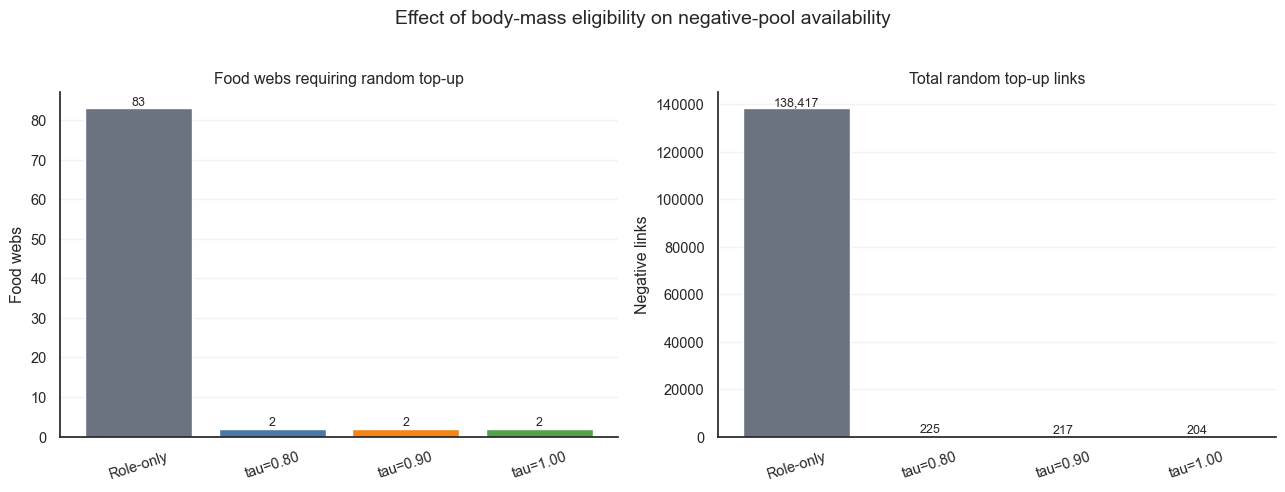


#### Candidate-pool audit interpretation

- The role-only baseline requires top-up in **83 of 290**
  food webs.
- With mass eligibility enabled, the numbers requiring top-up are:
  **2** at `0.80`,
  **2** at `0.90`, and
  **2** at `1.00`.
- The corresponding total top-up counts are
  **225**,
  **217**, and
  **204** negative links.
- Increasing `tau_mass` from `0.80` to `1.00` enlarges the eligible
  pool in **256**
  food webs and adds
  **24,628**
  eligible candidates overall.
- The three thresholds leave the same number of food webs requiring top-up, but they change the number of fallback links required. The practical difference is in top-up magnitude rather than food-web coverage.

This audit addresses candidate availability and fallback pressure. It
does not, by itself, establish which threshold gives the best predictive
performance or ecological validity.


In [12]:
# ============================================================
# Focused visualisation and concise interpretation
# ============================================================

plot_summary = (
    pool_availability_overall_df
    .select(
        "ScenarioOrder",
        "Scenario",
        "FoodWebsRequiringTopUp",
        "RandomTopUp",
    )
    .sort("ScenarioOrder")
)

plot_labels = (
    plot_summary
    .get_column("Scenario")
    .to_list()
)

plot_topup_webs = (
    plot_summary
    .get_column("FoodWebsRequiringTopUp")
    .to_numpy()
)

plot_topup_counts = (
    plot_summary
    .get_column("RandomTopUp")
    .to_numpy()
)

plot_colors = [
    "#6B7280",
    "#4C78A8",
    "#F58518",
    "#54A24B",
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.8),
)

axes[0].bar(
    plot_labels,
    plot_topup_webs,
    color=plot_colors,
)

axes[1].bar(
    plot_labels,
    plot_topup_counts,
    color=plot_colors,
)

for axis, values in zip(
    axes,
    [
        plot_topup_webs,
        plot_topup_counts,
    ],
):
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.grid(
        axis="y",
        alpha=0.22,
    )
    axis.set_axisbelow(True)
    axis.tick_params(
        axis="x",
        rotation=18,
    )

    for index, value in enumerate(values):
        axis.text(
            index,
            value,
            f"{int(value):,}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

axes[0].set_title(
    "Food webs requiring random top-up"
)
axes[0].set_ylabel("Food webs")

axes[1].set_title(
    "Total random top-up links"
)
axes[1].set_ylabel("Negative links")

fig.suptitle(
    "Effect of body-mass eligibility on negative-pool availability",
    fontsize=14,
    y=1.02,
)

fig.tight_layout()

if SAVE_POOL_AUDIT_OUTPUTS:
    POOL_AUDIT_OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    pool_audit_by_web_df.write_csv(
        POOL_AUDIT_OUTPUT_DIR
        / "pool_audit_by_foodweb_and_scenario.csv"
    )

    pool_availability_overall_df.write_csv(
        POOL_AUDIT_OUTPUT_DIR
        / "pool_availability_overall.csv"
    )

    pool_availability_by_ecosystem_df.write_csv(
        POOL_AUDIT_OUTPUT_DIR
        / "pool_availability_by_ecosystem.csv"
    )

    foodwebs_requiring_topup_df.write_csv(
        POOL_AUDIT_OUTPUT_DIR
        / "foodwebs_requiring_topup.csv"
    )

    threshold_vs_role_summary_df.write_csv(
        POOL_AUDIT_OUTPUT_DIR
        / "threshold_vs_role_only.csv"
    )

    threshold_pairwise_summary_df.write_csv(
        POOL_AUDIT_OUTPUT_DIR
        / "threshold_pairwise_comparison.csv"
    )

    fig.savefig(
        POOL_AUDIT_OUTPUT_DIR
        / "topup_availability_by_scenario.png",
        dpi=300,
        bbox_inches="tight",
    )

plt.show()


overall_rows = {
    row["Scenario"]: row
    for row
    in pool_availability_overall_df.to_dicts()
}

pair_0p80_to_1p00 = (
    threshold_pairwise_summary_df
    .filter(
        pl.col("Comparison") == "0.80 → 1.00"
    )
    .to_dicts()[0]
)

role_topup_webs = int(
    overall_rows["Role-only"][
        "FoodWebsRequiringTopUp"
    ]
)

threshold_topup_webs = {
    scenario: int(
        overall_rows[scenario][
            "FoodWebsRequiringTopUp"
        ]
    )
    for scenario in [
        "tau=0.80",
        "tau=0.90",
        "tau=1.00",
    ]
}

threshold_topup_counts = {
    scenario: int(
        overall_rows[scenario]["RandomTopUp"]
    )
    for scenario in [
        "tau=0.80",
        "tau=0.90",
        "tau=1.00",
    ]
}

same_topup_web_count = (
    len(set(threshold_topup_webs.values()))
    == 1
)

same_topup_link_count = (
    len(set(threshold_topup_counts.values()))
    == 1
)

if (
    same_topup_web_count
    and same_topup_link_count
):
    practical_difference = (
        "The three thresholds produce the same top-up "
        "requirement. Their pool-size differences do not "
        "change sampling feasibility for this tau grid."
    )
elif same_topup_web_count:
    practical_difference = (
        "The three thresholds leave the same number of food "
        "webs requiring top-up, but they change the number of "
        "fallback links required. The practical difference is "
        "in top-up magnitude rather than food-web coverage."
    )
else:
    practical_difference = (
        "The thresholds change how many food webs require "
        "top-up, so they produce a practically meaningful "
        "difference in negative-pool feasibility."
    )


display(
    Markdown(
        f'''
#### Candidate-pool audit interpretation

- The role-only baseline requires top-up in **{role_topup_webs} of 290**
  food webs.
- With mass eligibility enabled, the numbers requiring top-up are:
  **{threshold_topup_webs["tau=0.80"]}** at `0.80`,
  **{threshold_topup_webs["tau=0.90"]}** at `0.90`, and
  **{threshold_topup_webs["tau=1.00"]}** at `1.00`.
- The corresponding total top-up counts are
  **{threshold_topup_counts["tau=0.80"]:,}**,
  **{threshold_topup_counts["tau=0.90"]:,}**, and
  **{threshold_topup_counts["tau=1.00"]:,}** negative links.
- Increasing `tau_mass` from `0.80` to `1.00` enlarges the eligible
  pool in **{pair_0p80_to_1p00["FoodWebsWithLargerEligiblePool"]}**
  food webs and adds
  **{pair_0p80_to_1p00["EligibleCandidatesAdded"]:,}**
  eligible candidates overall.
- {practical_difference}

This audit addresses candidate availability and fallback pressure. It
does not, by itself, establish which threshold gives the best predictive
performance or ecological validity.
'''
    )
)


## 3. Final Experimental and Statistical Protocol

The following configuration is frozen for the primary mass-threshold
performance comparison.

| Component | Frozen decision |
|---|---|
| Negative-to-positive ratio | `2:1` |
| Eligible negative pool | Uniform sampling from `role OR mass` |
| Insufficient eligible pool | Controlled uniform top-up from remaining valid non-links |
| Connectivity | `check_connectivity=false`; adaptive connectivity inactive |
| Scenarios | Role-only, `tau_mass=0.80`, `0.90`, and `1.00` |
| Primary train ratio | `60%` |
| Runs | All 50 paired runs per food web; no performance-based run selection |
| Primary classification threshold | `0.5` |
| Threshold sweep | Supplementary output only |
| Valid metric observation | Positive test set and finite, non-null metric in both paired scenarios |
| Pairing keys | Food web, train ratio, experiment ID, and seed |
| Analysis unit | Mean paired result within each food web, followed by across-food-web summaries |
| Outlier policy | No predictive-performance outlier removal in the primary paired comparison |

Using all 50 paired runs supersedes the originally proposed 10-run pilot and
avoids introducing an arbitrary subset after the complete experiments are
already available.

<!-- MASS_THRESHOLD_PERFORMANCE_PILOT_V1 -->
## 4. Run the Mass-Threshold Performance Pilot

This section compares the role-only baseline with `tau_mass=0.80`, `0.90`,
and `1.00` using the common `60%` training-ratio runs. ROC-AUC and PR-AUC are
read once per run at the primary `Threshold=0.5` row so that threshold-invariant
metrics are not counted repeatedly. Threshold-dependent metrics are reported
from the same fixed-threshold row.

The threshold sweep remains available in the source CSV files but is not used
to select the primary result.

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import t as student_t
from IPython.display import display, Markdown


# ============================================================
# Mass-threshold performance-pilot configuration
# ============================================================

PILOT_ROOT = Path(
    "/Users/acw792/Developer/qmul-phd-framework"
)

PILOT_DATA_DIR = (
    PILOT_ROOT
    / "src"
    / "matlab"
    / "data"
)

PILOT_SCENARIOS = {
    "Role-only": {
        "order": 0,
        "tau": None,
        "folder": PILOT_DATA_DIR / (
            "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_"
            "randomeligible_massdiag_trainmetrics_"
            "checkconnfalse_Apocrita"
        ),
    },
    "tau=0.80": {
        "order": 1,
        "tau": 0.80,
        "folder": PILOT_DATA_DIR / (
            "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_"
            "randomeligible_roleormass_tau0p80_checkconnfalse_"
            "adaptivefalse_Apocrita"
        ),
    },
    "tau=0.90": {
        "order": 2,
        "tau": 0.90,
        "folder": PILOT_DATA_DIR / (
            "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_"
            "randomeligible_roleormass_tau0p90_checkconnfalse_"
            "adaptivefalse_Apocrita"
        ),
    },
    "tau=1.00": {
        "order": 3,
        "tau": 1.00,
        "folder": PILOT_DATA_DIR / (
            "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_"
            "randomeligible_roleormass_tau1p00_checkconnfalse_"
            "adaptivefalse_Apocrita"
        ),
    },
}

PILOT_TRAIN_RATIO = 60
PILOT_PRIMARY_THRESHOLD = 0.5
PILOT_EXPECTED_FOODWEBS = 290
PILOT_EXPECTED_RUNS_PER_WEB = 50
PILOT_EXPECTED_ROWS_PER_SCENARIO = (
    PILOT_EXPECTED_FOODWEBS
    * PILOT_EXPECTED_RUNS_PER_WEB
)

PILOT_METRICS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("TestF1Score", "F1"),
    ("TestMCC", "MCC"),
    ("TestPrecision", "Precision"),
    ("TestRecall", "Recall"),
    ("TestTSS", "TSS"),
]

PILOT_METRIC_COLUMNS = [
    column
    for column, _ in PILOT_METRICS
]

PILOT_METRIC_LABELS = dict(PILOT_METRICS)

PILOT_METRIC_ORDER = {
    label: index
    for index, (_, label)
    in enumerate(PILOT_METRICS)
}

PILOT_PAIR_KEYS = [
    "FoodWeb",
    "TrainRatio",
    "ExperimentID",
    "Seed",
]

PILOT_OUTPUT_DIR = (
    PILOT_DATA_DIR
    / "comparison_mass_threshold_performance_pilot"
)

SAVE_MASS_PILOT_OUTPUTS = False


def scan_pilot_scenario(
    scenario: str,
    configuration: dict,
) -> pl.DataFrame:

    folder = configuration["folder"]
    csv_files = sorted(
        (
            folder
            / "prediction_scores_logs"
        ).glob("*.csv")
    )

    assert folder.is_dir(), folder
    assert len(csv_files) == PILOT_EXPECTED_FOODWEBS, (
        scenario,
        len(csv_files),
    )

    schema_overrides = {
        "TrainRatio": pl.Int64,
        "ExperimentID": pl.Int64,
        "Seed": pl.Int64,
        "Threshold": pl.Float64,
        "TestLinks": pl.Int64,
        **{
            metric: pl.Float64
            for metric in PILOT_METRIC_COLUMNS
        },
    }

    return (
        pl.scan_csv(
            str(
                folder
                / "prediction_scores_logs"
                / "*.csv"
            ),
            include_file_paths="SourceFile",
            schema_overrides=schema_overrides,
            null_values=[
                "NaN",
                "nan",
                "Inf",
                "-Inf",
                "",
            ],
            infer_schema_length=500,
        )
        .filter(
            (pl.col("TrainRatio") == PILOT_TRAIN_RATIO)
            & (
                (
                    pl.col("Threshold")
                    - PILOT_PRIMARY_THRESHOLD
                ).abs()
                < 1e-12
            )
            & (
                pl.col("ThresholdMode")
                == "threshold_sweep"
            )
        )
        .select(
            "SourceFile",
            "TrainRatio",
            "ExperimentID",
            "Seed",
            "Threshold",
            "TestLinks",
            *PILOT_METRIC_COLUMNS,
        )
        .with_columns(
            pl.lit(scenario).alias("Scenario"),
            pl.lit(
                configuration["order"]
            ).alias("ScenarioOrder"),
            pl.lit(
                configuration["tau"]
            )
            .cast(pl.Float64)
            .alias("TauMass"),

            pl.col("SourceFile")
            .str.extract(
                r"([^/]+)_results_random_wlnm_dir_neg\.csv$",
                1,
            )
            .alias("FoodWeb"),

            *[
                pl.col(metric)
                .cast(pl.Float64, strict=False)
                .fill_nan(None)
                for metric in PILOT_METRIC_COLUMNS
            ],
        )
        .with_columns(
            pl.col("FoodWeb")
            .str.replace(r"_tax_mass$", "")
            .alias("FoodWebLabel")
        )
        .drop("SourceFile")
        .collect(engine="streaming")
        .sort(PILOT_PAIR_KEYS)
    )


pilot_frames = {
    scenario: scan_pilot_scenario(
        scenario,
        configuration,
    )
    for scenario, configuration
    in PILOT_SCENARIOS.items()
}

for scenario, frame in pilot_frames.items():
    assert (
        frame.height
        == PILOT_EXPECTED_ROWS_PER_SCENARIO
    ), (scenario, frame.height)

    assert (
        frame.get_column("FoodWeb").n_unique()
        == PILOT_EXPECTED_FOODWEBS
    )

    assert (
        frame.get_column("ExperimentID").n_unique()
        == PILOT_EXPECTED_RUNS_PER_WEB
    )

    assert (
        frame.select(
            pl.struct(PILOT_PAIR_KEYS).n_unique()
        ).item()
        == frame.height
    )

    assert (
        frame.filter(
            pl.col("TestLinks") <= 0
        ).is_empty()
    )


pilot_performance_df = (
    pl.concat(
        list(pilot_frames.values()),
        how="vertical_relaxed",
    )
    .join(
        ecosystem_lookup_df,
        on="FoodWeb",
        how="left",
        validate="m:1",
    )
    .sort([
        "ScenarioOrder",
        *PILOT_PAIR_KEYS,
    ])
)

assert (
    pilot_performance_df
    .get_column("Ecosystem")
    .null_count()
    == 0
)


# ============================================================
# Exact common-key validation across all four scenarios
# ============================================================

pilot_baseline_keys_df = (
    pilot_frames["Role-only"]
    .select(PILOT_PAIR_KEYS)
)

pilot_pair_integrity_rows = []

for scenario in [
    "tau=0.80",
    "tau=0.90",
    "tau=1.00",
]:
    scenario_keys_df = (
        pilot_frames[scenario]
        .select(PILOT_PAIR_KEYS)
    )

    common_keys = (
        pilot_baseline_keys_df
        .join(
            scenario_keys_df,
            on=PILOT_PAIR_KEYS,
            how="inner",
            validate="1:1",
        )
    )

    only_baseline = (
        pilot_baseline_keys_df
        .join(
            scenario_keys_df,
            on=PILOT_PAIR_KEYS,
            how="anti",
        )
    )

    only_scenario = (
        scenario_keys_df
        .join(
            pilot_baseline_keys_df,
            on=PILOT_PAIR_KEYS,
            how="anti",
        )
    )

    pilot_pair_integrity_rows.append({
        "Scenario": scenario,
        "BaselineRows": (
            pilot_baseline_keys_df.height
        ),
        "ScenarioRows": scenario_keys_df.height,
        "CommonPairedKeys": common_keys.height,
        "OnlyBaseline": only_baseline.height,
        "OnlyScenario": only_scenario.height,
    })


pilot_pair_integrity_df = (
    pl.DataFrame(pilot_pair_integrity_rows)
)

assert (
    pilot_pair_integrity_df
    .filter(
        (pl.col("CommonPairedKeys")
         != PILOT_EXPECTED_ROWS_PER_SCENARIO)
        | (pl.col("OnlyBaseline") != 0)
        | (pl.col("OnlyScenario") != 0)
    )
    .is_empty()
)


pilot_input_summary_df = (
    pilot_performance_df
    .group_by([
        "ScenarioOrder",
        "Scenario",
        "TauMass",
    ])
    .agg(
        pl.len().alias("Rows"),
        pl.col("FoodWeb")
        .n_unique()
        .alias("FoodWebs"),
        pl.col("ExperimentID")
        .n_unique()
        .alias("RunsPerFoodWeb"),
        pl.col("Seed")
        .n_unique()
        .alias("UniqueSeeds"),
        pl.col("TestLinks")
        .min()
        .alias("MinimumTestLinks"),
    )
    .sort("ScenarioOrder")
)

print("TABLE 4.1 — Pilot input validation")

display(
    pd.DataFrame(
        pilot_input_summary_df.to_dicts()
    )
)

print("TABLE 4.2 — Exact pairing against role-only")

display(
    pd.DataFrame(
        pilot_pair_integrity_df.to_dicts()
    )
)


TABLE 4.1 — Pilot input validation


,ScenarioOrder,Scenario,TauMass,Rows,FoodWebs,RunsPerFoodWeb,UniqueSeeds,MinimumTestLinks
0,0,Role-only,NaN,14500,290,50,9250,6
1,1,tau=0.80,0.8,14500,290,50,9250,6
2,2,tau=0.90,0.9,14500,290,50,9250,6
3,3,tau=1.00,1.0,14500,290,50,9250,6


TABLE 4.2 — Exact pairing against role-only


,Scenario,BaselineRows,ScenarioRows,CommonPairedKeys,OnlyBaseline,OnlyScenario
0,tau=0.80,14500,14500,14500,0,0
1,tau=0.90,14500,14500,14500,0,0
2,tau=1.00,14500,14500,14500,0,0


In [14]:
# ============================================================
# Convert metrics to long format and construct paired contrasts
# ============================================================

pilot_long_df = (
    pilot_performance_df
    .unpivot(
        index=[
            "Scenario",
            "ScenarioOrder",
            "TauMass",
            "FoodWeb",
            "FoodWebLabel",
            "Ecosystem",
            "TrainRatio",
            "ExperimentID",
            "Seed",
            "Threshold",
            "TestLinks",
        ],
        on=PILOT_METRIC_COLUMNS,
        variable_name="MetricColumn",
        value_name="MetricValue",
    )
    .with_columns(
        pl.col("MetricColumn")
        .replace_strict(
            PILOT_METRIC_LABELS
        )
        .alias("Metric")
    )
    .drop("MetricColumn")
)


pilot_baseline_long_df = (
    pilot_long_df
    .filter(
        pl.col("Scenario") == "Role-only"
    )
    .select(
        *PILOT_PAIR_KEYS,
        "FoodWebLabel",
        "Ecosystem",
        "Metric",
        pl.col("MetricValue").alias(
            "BaselineValue"
        ),
    )
)


pilot_vs_role_run_frames = []

for scenario in [
    "tau=0.80",
    "tau=0.90",
    "tau=1.00",
]:
    scenario_configuration = (
        PILOT_SCENARIOS[scenario]
    )

    scenario_long_df = (
        pilot_long_df
        .filter(
            pl.col("Scenario") == scenario
        )
        .select(
            *PILOT_PAIR_KEYS,
            "Metric",
            pl.col("MetricValue").alias(
                "ScenarioValue"
            ),
        )
    )

    paired_metric_df = (
        pilot_baseline_long_df
        .join(
            scenario_long_df,
            on=[
                *PILOT_PAIR_KEYS,
                "Metric",
            ],
            how="inner",
            validate="1:1",
        )
        .filter(
            pl.col("BaselineValue")
            .is_not_null()
            & pl.col("BaselineValue")
            .is_finite()
            & pl.col("ScenarioValue")
            .is_not_null()
            & pl.col("ScenarioValue")
            .is_finite()
        )
        .with_columns(
            pl.lit(scenario).alias(
                "Scenario"
            ),
            pl.lit(
                scenario_configuration["order"]
            ).alias("ScenarioOrder"),
            pl.lit(
                scenario_configuration["tau"]
            ).alias("TauMass"),
            (
                pl.col("ScenarioValue")
                - pl.col("BaselineValue")
            ).alias("RunDelta"),
        )
    )

    pilot_vs_role_run_frames.append(
        paired_metric_df
    )


pilot_vs_role_run_df = (
    pl.concat(
        pilot_vs_role_run_frames,
        how="vertical_relaxed",
    )
)


# First average paired runs within each food web.
# Each food web therefore receives equal weight in the final summary.
pilot_vs_role_web_df = (
    pilot_vs_role_run_df
    .group_by([
        "ScenarioOrder",
        "Scenario",
        "TauMass",
        "FoodWeb",
        "FoodWebLabel",
        "Ecosystem",
        "Metric",
    ])
    .agg(
        pl.len().alias("PairedRuns"),
        pl.col("BaselineValue")
        .mean()
        .alias("MeanBaseline"),
        pl.col("ScenarioValue")
        .mean()
        .alias("MeanScenario"),
        pl.col("RunDelta")
        .mean()
        .alias("MeanDelta"),
    )
)


def add_delta_confidence_interval(
    dataframe: pl.DataFrame,
) -> pl.DataFrame:

    rows = []

    for row in dataframe.to_dicts():
        number_webs = int(
            row["PairedFoodWebs"]
        )
        standard_deviation = row[
            "DeltaStd"
        ]

        if (
            number_webs >= 2
            and standard_deviation is not None
            and np.isfinite(standard_deviation)
        ):
            critical_value = float(
                student_t.ppf(
                    0.975,
                    df=number_webs - 1,
                )
            )
            margin = (
                critical_value
                * standard_deviation
                / np.sqrt(number_webs)
            )
            lower = (
                row["MeanDelta"] - margin
            )
            upper = (
                row["MeanDelta"] + margin
            )
        else:
            lower = np.nan
            upper = np.nan

        rows.append({
            **row,
            "DeltaCI95Lower": lower,
            "DeltaCI95Upper": upper,
        })

    return pl.DataFrame(rows)


pilot_vs_role_summary_raw_df = (
    pilot_vs_role_web_df
    .group_by([
        "ScenarioOrder",
        "Scenario",
        "TauMass",
        "Metric",
    ])
    .agg(
        pl.col("FoodWeb")
        .n_unique()
        .alias("PairedFoodWebs"),
        pl.col("PairedRuns")
        .sum()
        .alias("PairedRuns"),
        pl.col("PairedRuns")
        .min()
        .alias("MinRunsPerFoodWeb"),
        pl.col("PairedRuns")
        .median()
        .alias("MedianRunsPerFoodWeb"),
        pl.col("MeanBaseline")
        .mean()
        .alias("MeanBaseline"),
        pl.col("MeanScenario")
        .mean()
        .alias("MeanScenario"),
        pl.col("MeanDelta")
        .mean()
        .alias("MeanDelta"),
        pl.col("MeanDelta")
        .std(ddof=1)
        .alias("DeltaStd"),
        pl.col("MeanDelta")
        .median()
        .alias("MedianDelta"),
        pl.col("MeanDelta")
        .quantile(0.25)
        .alias("DeltaQ25"),
        pl.col("MeanDelta")
        .quantile(0.75)
        .alias("DeltaQ75"),
        (
            100.0
            * (
                pl.col("MeanDelta") > 0
            )
            .cast(pl.Float64)
            .mean()
        ).alias("FoodWebsImprovedPct"),
    )
)


pilot_vs_role_summary_df = (
    add_delta_confidence_interval(
        pilot_vs_role_summary_raw_df
    )
    .with_columns(
        pl.col("Metric")
        .replace_strict(
            PILOT_METRIC_ORDER
        )
        .alias("_MetricOrder")
    )
    .sort([
        "ScenarioOrder",
        "_MetricOrder",
    ])
    .drop([
        "_MetricOrder",
        "DeltaStd",
    ])
)


# ============================================================
# Pairwise comparisons between mass thresholds
# Delta is always later/higher tau minus earlier/lower tau.
# ============================================================

PILOT_THRESHOLD_PAIRS = [
    ("tau=0.80", "tau=0.90"),
    ("tau=0.90", "tau=1.00"),
    ("tau=0.80", "tau=1.00"),
]


def paired_threshold_runs(
    lower_scenario: str,
    upper_scenario: str,
) -> pl.DataFrame:

    lower = (
        pilot_long_df
        .filter(
            pl.col("Scenario")
            == lower_scenario
        )
        .select(
            *PILOT_PAIR_KEYS,
            "FoodWebLabel",
            "Ecosystem",
            "Metric",
            pl.col("MetricValue").alias(
                "LowerValue"
            ),
        )
    )

    upper = (
        pilot_long_df
        .filter(
            pl.col("Scenario")
            == upper_scenario
        )
        .select(
            *PILOT_PAIR_KEYS,
            "Metric",
            pl.col("MetricValue").alias(
                "UpperValue"
            ),
        )
    )

    return (
        lower
        .join(
            upper,
            on=[
                *PILOT_PAIR_KEYS,
                "Metric",
            ],
            how="inner",
            validate="1:1",
        )
        .filter(
            pl.col("LowerValue")
            .is_not_null()
            & pl.col("LowerValue")
            .is_finite()
            & pl.col("UpperValue")
            .is_not_null()
            & pl.col("UpperValue")
            .is_finite()
        )
        .with_columns(
            pl.lit(
                f"{lower_scenario} → "
                f"{upper_scenario}"
            ).alias("Comparison"),
            (
                pl.col("UpperValue")
                - pl.col("LowerValue")
            ).alias("RunDelta"),
        )
    )


pilot_threshold_pair_run_df = (
    pl.concat(
        [
            paired_threshold_runs(
                lower,
                upper,
            )
            for lower, upper
            in PILOT_THRESHOLD_PAIRS
        ],
        how="vertical_relaxed",
    )
)


pilot_threshold_pair_web_df = (
    pilot_threshold_pair_run_df
    .group_by([
        "Comparison",
        "FoodWeb",
        "FoodWebLabel",
        "Ecosystem",
        "Metric",
    ])
    .agg(
        pl.len().alias("PairedRuns"),
        pl.col("LowerValue")
        .mean()
        .alias("MeanLower"),
        pl.col("UpperValue")
        .mean()
        .alias("MeanUpper"),
        pl.col("RunDelta")
        .mean()
        .alias("MeanDelta"),
    )
)


pilot_threshold_pair_summary_raw_df = (
    pilot_threshold_pair_web_df
    .group_by([
        "Comparison",
        "Metric",
    ])
    .agg(
        pl.col("FoodWeb")
        .n_unique()
        .alias("PairedFoodWebs"),
        pl.col("PairedRuns")
        .sum()
        .alias("PairedRuns"),
        pl.col("PairedRuns")
        .min()
        .alias("MinRunsPerFoodWeb"),
        pl.col("PairedRuns")
        .median()
        .alias("MedianRunsPerFoodWeb"),
        pl.col("MeanLower")
        .mean()
        .alias("MeanLower"),
        pl.col("MeanUpper")
        .mean()
        .alias("MeanUpper"),
        pl.col("MeanDelta")
        .mean()
        .alias("MeanDelta"),
        pl.col("MeanDelta")
        .std(ddof=1)
        .alias("DeltaStd"),
        pl.col("MeanDelta")
        .median()
        .alias("MedianDelta"),
        pl.col("MeanDelta")
        .quantile(0.25)
        .alias("DeltaQ25"),
        pl.col("MeanDelta")
        .quantile(0.75)
        .alias("DeltaQ75"),
        (
            100.0
            * (
                pl.col("MeanDelta") > 0
            )
            .cast(pl.Float64)
            .mean()
        ).alias("FoodWebsImprovedPct"),
    )
)


pilot_threshold_pair_summary_df = (
    add_delta_confidence_interval(
        pilot_threshold_pair_summary_raw_df
    )
    .with_columns(
        pl.col("Metric")
        .replace_strict(
            PILOT_METRIC_ORDER
        )
        .alias("_MetricOrder")
    )
    .sort([
        "Comparison",
        "_MetricOrder",
    ])
    .drop([
        "_MetricOrder",
        "DeltaStd",
    ])
)


print(
    "Metric-specific paired run observations "
    "against role-only:",
    f"{pilot_vs_role_run_df.height:,}",
)

print(
    "Food-web/metric summaries against role-only:",
    f"{pilot_vs_role_web_df.height:,}",
)


Metric-specific paired run observations against role-only: 304,500
Food-web/metric summaries against role-only: 6,090


In [15]:
# ============================================================
# Performance tables and deterministic scenario scorecard
# ============================================================

pilot_pool_context_df = (
    pool_availability_overall_df
    .select(
        "ScenarioOrder",
        "Scenario",
        "TauMass",
        "EligiblePool",
        "MassOnlyCandidates",
        "EligibleShortfall",
        "RandomTopUp",
        "FoodWebsRequiringTopUp",
    )
    .sort("ScenarioOrder")
)


pilot_metric_means_df = (
    pilot_vs_role_web_df
    .group_by([
        "ScenarioOrder",
        "Scenario",
        "TauMass",
        "Metric",
    ])
    .agg(
        pl.col("MeanScenario")
        .mean()
        .alias("MeanPerformance")
    )
    .with_columns(
        pl.col("MeanPerformance")
        .rank(
            method="average",
            descending=True,
        )
        .over("Metric")
        .alias("MetricRank")
    )
)


pilot_scenario_scorecard_df = (
    pilot_metric_means_df
    .group_by([
        "ScenarioOrder",
        "Scenario",
        "TauMass",
    ])
    .agg(
        pl.col("Metric")
        .n_unique()
        .alias("Metrics"),
        pl.col("MetricRank")
        .mean()
        .alias("AverageMetricRank"),
        (
            pl.col("MetricRank") == 1
        )
        .sum()
        .alias("MetricsRankedFirst"),
    )
    .join(
        pilot_pool_context_df
        .select(
            "Scenario",
            "EligiblePool",
            "MassOnlyCandidates",
            "RandomTopUp",
            "FoodWebsRequiringTopUp",
        ),
        on="Scenario",
        how="left",
        validate="1:1",
    )
    .sort([
        "FoodWebsRequiringTopUp",
        "AverageMetricRank",
        "RandomTopUp",
        "TauMass",
    ])
)


print("TABLE 4.3 — Candidate-pool context")

display(
    pd.DataFrame(
        pilot_pool_context_df.to_dicts()
    ).round(4)
)

print("TABLE 4.4 — Paired performance versus role-only")

display(
    pd.DataFrame(
        pilot_vs_role_summary_df.to_dicts()
    ).round(5)
)

print("TABLE 4.5 — Pairwise mass-threshold differences")

display(
    pd.DataFrame(
        pilot_threshold_pair_summary_df.to_dicts()
    ).round(5)
)

print("TABLE 4.6 — Scenario scorecard")

display(
    pd.DataFrame(
        pilot_scenario_scorecard_df.to_dicts()
    ).round(5)
)


if SAVE_MASS_PILOT_OUTPUTS:
    PILOT_OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    pilot_input_summary_df.write_csv(
        PILOT_OUTPUT_DIR
        / "pilot_input_summary.csv"
    )

    pilot_pair_integrity_df.write_csv(
        PILOT_OUTPUT_DIR
        / "pilot_pair_integrity.csv"
    )

    pilot_vs_role_web_df.write_csv(
        PILOT_OUTPUT_DIR
        / "pilot_vs_role_only_by_foodweb.csv"
    )

    pilot_vs_role_summary_df.write_csv(
        PILOT_OUTPUT_DIR
        / "pilot_vs_role_only_summary.csv"
    )

    pilot_threshold_pair_summary_df.write_csv(
        PILOT_OUTPUT_DIR
        / "pilot_threshold_pairwise_summary.csv"
    )

    pilot_scenario_scorecard_df.write_csv(
        PILOT_OUTPUT_DIR
        / "pilot_scenario_scorecard.csv"
    )


TABLE 4.3 — Candidate-pool context


,ScenarioOrder,Scenario,TauMass,EligiblePool,MassOnlyCandidates,EligibleShortfall,RandomTopUp,FoodWebsRequiringTopUp
0,0,Role-only,NaN,567837,0,138417,138417,83
1,1,tau=0.80,0.8,1248704,680867,225,225,2
2,2,tau=0.90,0.9,1262288,694451,217,217,2
3,3,tau=1.00,1.0,1273332,705495,204,204,2


TABLE 4.4 — Paired performance versus role-only


,ScenarioOrder,Scenario,TauMass,Metric,PairedFoodWebs,PairedRuns,MinRunsPerFoodWeb,MedianRunsPerFoodWeb,MeanBaseline,MeanScenario,MeanDelta,MedianDelta,DeltaQ25,DeltaQ75,FoodWebsImprovedPct,DeltaCI95Lower,DeltaCI95Upper
0,1,tau=0.80,0.8,ROC-AUC,290,14500,50,50.0,0.87043,0.83565,-0.03477,-0.02611,-0.05830,-0.00329,22.06897,-0.04136,-0.02819
1,1,tau=0.80,0.8,PR-AUC,290,14500,50,50.0,0.53571,0.58571,0.05000,0.00672,-0.05730,0.15336,53.10345,0.02838,0.07161
2,1,tau=0.80,0.8,F1,290,14500,50,50.0,0.66759,0.61618,-0.05141,-0.02516,-0.07695,0.00800,29.31034,-0.06632,-0.03651
3,1,tau=0.80,0.8,MCC,290,14500,50,50.0,0.61398,0.55890,-0.05508,-0.03530,-0.09717,0.01121,29.65517,-0.07127,-0.03890
4,1,tau=0.80,0.8,Precision,290,14500,50,50.0,0.89572,0.87735,-0.01838,-0.02735,-0.06562,0.01208,30.00000,-0.02664,-0.01012
5,1,tau=0.80,0.8,Recall,290,14500,50,50.0,0.57049,0.50955,-0.06094,-0.02296,-0.07595,0.01042,31.03448,-0.07857,-0.04331
6,1,tau=0.80,0.8,TSS,290,14500,50,50.0,0.53770,0.47317,-0.06453,-0.02717,-0.09446,0.01225,29.31034,-0.08327,-0.04579
7,2,tau=0.90,0.9,ROC-AUC,290,14500,50,50.0,0.87043,0.83331,-0.03712,-0.02845,-0.05959,-0.00616,21.03448,-0.04378,-0.03045
8,2,tau=0.90,0.9,PR-AUC,290,14500,50,50.0,0.53571,0.58683,0.05111,0.00918,-0.05768,0.16055,53.44828,0.02960,0.07262
9,2,tau=0.90,0.9,F1,290,14500,50,50.0,0.66759,0.61375,-0.05384,-0.02932,-0.07756,0.00372,26.55172,-0.06871,-0.03896


TABLE 4.5 — Pairwise mass-threshold differences


,Comparison,Metric,PairedFoodWebs,PairedRuns,MinRunsPerFoodWeb,MedianRunsPerFoodWeb,MeanLower,MeanUpper,MeanDelta,MedianDelta,DeltaQ25,DeltaQ75,FoodWebsImprovedPct,DeltaCI95Lower,DeltaCI95Upper
0,tau=0.80 → tau=0.90,ROC-AUC,290,14500,50,50.0,0.83565,0.83331,-0.00234,-0.00019,-0.00508,0.00105,30.00000,-0.00331,-0.00137
1,tau=0.80 → tau=0.90,PR-AUC,290,14500,50,50.0,0.58571,0.58683,0.00112,0.00000,-0.00799,0.00908,42.06897,-0.00066,0.00290
2,tau=0.80 → tau=0.90,F1,290,14500,50,50.0,0.61618,0.61375,-0.00243,-0.00004,-0.00302,0.00036,30.68966,-0.00346,-0.00139
3,tau=0.80 → tau=0.90,MCC,290,14500,50,50.0,0.55890,0.55630,-0.00260,0.00000,-0.00322,0.00071,32.06897,-0.00381,-0.00138
4,tau=0.80 → tau=0.90,Precision,290,14500,50,50.0,0.87735,0.87655,-0.00080,0.00000,-0.00306,0.00144,37.24138,-0.00199,0.00039
5,tau=0.80 → tau=0.90,Recall,290,14500,50,50.0,0.50955,0.50667,-0.00288,0.00000,-0.00391,0.00042,31.72414,-0.00413,-0.00163
6,tau=0.80 → tau=0.90,TSS,290,14500,50,50.0,0.47317,0.47019,-0.00297,0.00000,-0.00335,0.00040,33.10345,-0.00426,-0.00169
7,tau=0.80 → tau=1.00,ROC-AUC,290,14500,50,50.0,0.83565,0.83358,-0.00207,-0.00050,-0.00594,0.00133,33.10345,-0.00309,-0.00105
8,tau=0.80 → tau=1.00,PR-AUC,290,14500,50,50.0,0.58571,0.58683,0.00112,0.00000,-0.00907,0.00945,43.79310,-0.00073,0.00297
9,tau=0.80 → tau=1.00,F1,290,14500,50,50.0,0.61618,0.61381,-0.00237,-0.00071,-0.00372,0.00070,30.68966,-0.00349,-0.00125


TABLE 4.6 — Scenario scorecard


,ScenarioOrder,Scenario,TauMass,Metrics,AverageMetricRank,MetricsRankedFirst,EligiblePool,MassOnlyCandidates,RandomTopUp,FoodWebsRequiringTopUp
0,1,tau=0.80,0.8,7,1.28571,6,1248704,680867,225,2
1,3,tau=1.00,1.0,7,2.14286,1,1273332,705495,204,2
2,2,tau=0.90,0.9,7,2.57143,0,1262288,694451,217,2


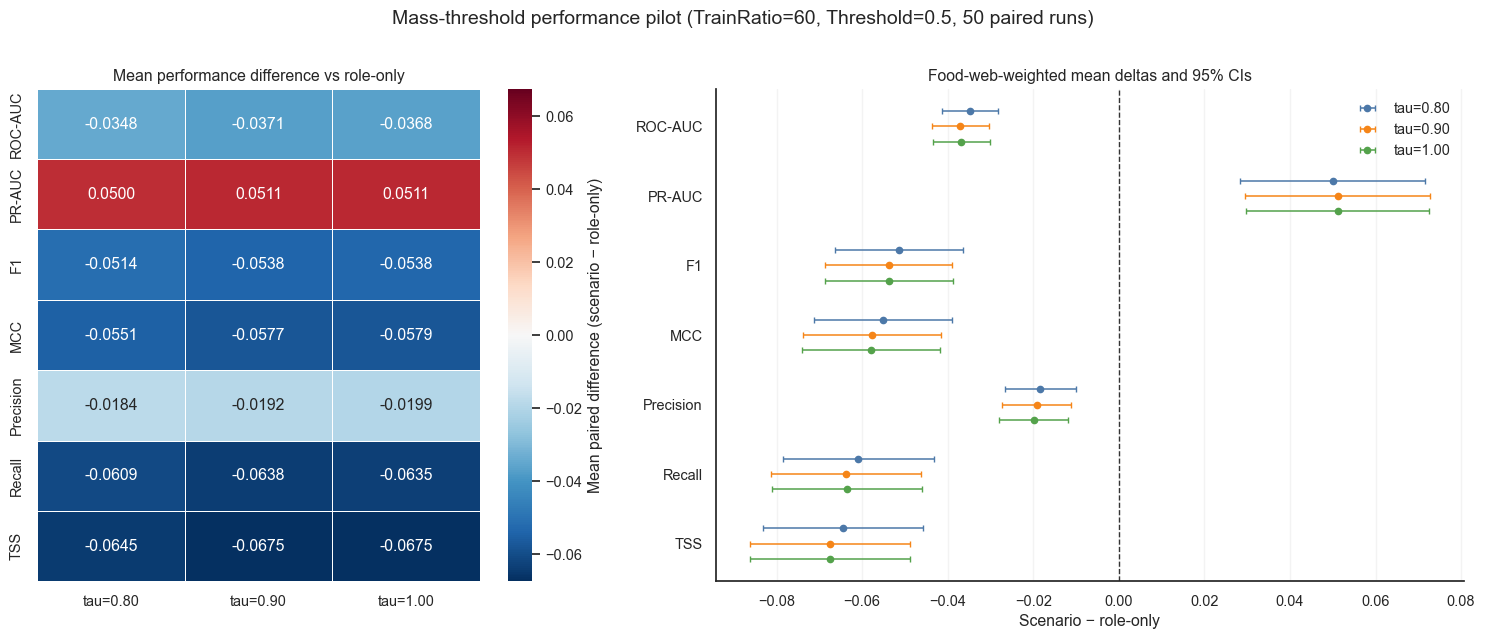

In [16]:
# ============================================================
# Focused visual comparison
# ============================================================

pilot_heatmap_df = (
    pilot_vs_role_summary_df
    .select(
        "Scenario",
        "Metric",
        "MeanDelta",
    )
    .to_pandas()
    .pivot(
        index="Metric",
        columns="Scenario",
        values="MeanDelta",
    )
    .reindex(
        [
            label
            for _, label
            in PILOT_METRICS
        ]
    )
    .reindex(
        columns=[
            "tau=0.80",
            "tau=0.90",
            "tau=1.00",
        ]
    )
)

maximum_absolute_delta = float(
    np.nanmax(
        np.abs(
            pilot_heatmap_df.to_numpy()
        )
    )
)

if maximum_absolute_delta == 0:
    maximum_absolute_delta = 1e-9


fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6.3),
    gridspec_kw={
        "width_ratios": [1.0, 1.35],
    },
)


sns.heatmap(
    pilot_heatmap_df,
    annot=True,
    fmt=".4f",
    cmap="RdBu_r",
    center=0,
    vmin=-maximum_absolute_delta,
    vmax=maximum_absolute_delta,
    linewidths=0.5,
    cbar_kws={
        "label": (
            "Mean paired difference "
            "(scenario − role-only)"
        ),
    },
    ax=axes[0],
)

axes[0].set_title(
    "Mean performance difference vs role-only"
)
axes[0].set_xlabel("")
axes[0].set_ylabel("")


forest_scenarios = [
    "tau=0.80",
    "tau=0.90",
    "tau=1.00",
]

forest_colors = {
    "tau=0.80": "#4C78A8",
    "tau=0.90": "#F58518",
    "tau=1.00": "#54A24B",
}

metric_labels = [
    label
    for _, label
    in PILOT_METRICS
]

base_y = np.arange(
    len(metric_labels)
)

scenario_offsets = {
    "tau=0.80": -0.22,
    "tau=0.90": 0.0,
    "tau=1.00": 0.22,
}

for scenario in forest_scenarios:
    scenario_rows = (
        pilot_vs_role_summary_df
        .filter(
            pl.col("Scenario") == scenario
        )
        .sort(
            pl.col("Metric")
            .replace_strict(
                PILOT_METRIC_ORDER
            )
        )
    )

    means = (
        scenario_rows
        .get_column("MeanDelta")
        .to_numpy()
    )

    lower = (
        scenario_rows
        .get_column("DeltaCI95Lower")
        .to_numpy()
    )

    upper = (
        scenario_rows
        .get_column("DeltaCI95Upper")
        .to_numpy()
    )

    x_errors = np.vstack([
        means - lower,
        upper - means,
    ])

    axes[1].errorbar(
        means,
        base_y
        + scenario_offsets[scenario],
        xerr=x_errors,
        fmt="o",
        color=forest_colors[scenario],
        capsize=2.5,
        markersize=4.5,
        linewidth=1.1,
        label=scenario,
    )


axes[1].axvline(
    0,
    color="#333333",
    linestyle="--",
    linewidth=1,
)

axes[1].set_yticks(base_y)
axes[1].set_yticklabels(metric_labels)
axes[1].invert_yaxis()
axes[1].grid(
    axis="x",
    alpha=0.22,
)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].set_title(
    "Food-web-weighted mean deltas and 95% CIs"
)
axes[1].set_xlabel(
    "Scenario − role-only"
)
axes[1].set_ylabel("")
axes[1].legend(
    frameon=False,
    loc="best",
)

fig.suptitle(
    "Mass-threshold performance pilot "
    "(TrainRatio=60, Threshold=0.5, 50 paired runs)",
    fontsize=14,
    y=1.01,
)

fig.tight_layout()

if SAVE_MASS_PILOT_OUTPUTS:
    fig.savefig(
        PILOT_OUTPUT_DIR
        / "mass_threshold_performance_pilot.png",
        dpi=300,
        bbox_inches="tight",
    )

plt.show()


In [17]:
# ============================================================
# Decision evidence for the final tau_mass
# ============================================================

# Count pairwise metric contrasts whose 95% confidence interval
# excludes zero. This is descriptive decision evidence; no
# performance-based run selection is performed.
pilot_decisive_pairwise_df = (
    pilot_threshold_pair_summary_df
    .with_columns(
        pl.when(
            pl.col("DeltaCI95Lower") > 0
        )
        .then(pl.lit("Higher tau better"))
        .when(
            pl.col("DeltaCI95Upper") < 0
        )
        .then(pl.lit("Lower tau better"))
        .otherwise(
            pl.lit("CI includes zero")
        )
        .alias("Direction")
    )
    .group_by([
        "Comparison",
        "Direction",
    ])
    .len()
    .pivot(
        values="len",
        index="Comparison",
        on="Direction",
    )
    .fill_null(0)
    .sort("Comparison")
)

print(
    "TABLE 4.7 — Direction of pairwise 95% intervals"
)

display(
    pd.DataFrame(
        pilot_decisive_pairwise_df.to_dicts()
    )
)

# ============================================================
# Final selection
# ============================================================

FINAL_TAU_MASS = 0.80

selected_score = (
    pilot_scenario_scorecard_df
    .filter(
        pl.col("TauMass") == FINAL_TAU_MASS
    )
    .to_dicts()[0]
)

selected_pool = (
    pilot_pool_context_df
    .filter(
        pl.col("TauMass") == FINAL_TAU_MASS
    )
    .to_dicts()[0]
)

selected_vs_role = (
    pilot_vs_role_summary_df
    .filter(
        pl.col("TauMass") == FINAL_TAU_MASS
    )
)

metrics_better_than_role = (
    selected_vs_role
    .filter(
        pl.col("MeanDelta") > 0
    )
    .get_column("Metric")
    .to_list()
)

metrics_lower_than_role = (
    selected_vs_role
    .filter(
        pl.col("MeanDelta") < 0
    )
    .get_column("Metric")
    .to_list()
)

display(
    Markdown(
        f'''
#### Final `tau_mass` selection

**Selected value: `tau_mass={FINAL_TAU_MASS:.2f}`.**

The selection combines candidate-pool feasibility and paired predictive
performance:

- All three mass thresholds leave the same **2 of 290** food webs requiring
  top-up, so increasing the threshold does not improve food-web coverage.
- `tau_mass=0.80` ranks first in
  **{selected_score["MetricsRankedFirst"]} of
  {selected_score["Metrics"]}** predictive metrics and has the best average
  metric rank (**{selected_score["AverageMetricRank"]:.3f}**).
- Relative to `0.90`, the 95% paired interval favours the lower threshold in
  five metrics and includes zero in two. Relative to `1.00`, it favours the
  lower threshold in six metrics and includes zero in one.
- It is the most conservative tested mass rule and adds fewer mass-only
  candidates than the higher thresholds, while reducing role-only top-up from
  83 to **{selected_pool["FoodWebsRequiringTopUp"]}** food webs.
- Compared with role-only, it improves **{", ".join(metrics_better_than_role)}**
  but is lower for **{", ".join(metrics_lower_than_role)}**. Therefore, the
  selected value is a compromise between ecological candidate availability
  and predictive performance, not a claim that mass eligibility dominates
  role-only on every metric.

The primary experiments should use `tau_mass=0.80`,
`check_connectivity=false`, and `adaptive_connectivity=false`.
'''
    )
)


TABLE 4.7 — Direction of pairwise 95% intervals


,Comparison,CI includes zero,Lower tau better
0,tau=0.80 → tau=0.90,2,5
1,tau=0.80 → tau=1.00,1,6
2,tau=0.90 → tau=1.00,7,0



#### Final `tau_mass` selection

**Selected value: `tau_mass=0.80`.**

The selection combines candidate-pool feasibility and paired predictive
performance:

- All three mass thresholds leave the same **2 of 290** food webs requiring
  top-up, so increasing the threshold does not improve food-web coverage.
- `tau_mass=0.80` ranks first in
  **6 of
  7** predictive metrics and has the best average
  metric rank (**1.286**).
- Relative to `0.90`, the 95% paired interval favours the lower threshold in
  five metrics and includes zero in two. Relative to `1.00`, it favours the
  lower threshold in six metrics and includes zero in one.
- It is the most conservative tested mass rule and adds fewer mass-only
  candidates than the higher thresholds, while reducing role-only top-up from
  83 to **2** food webs.
- Compared with role-only, it improves **PR-AUC**
  but is lower for **ROC-AUC, F1, MCC, Precision, Recall, TSS**. Therefore, the
  selected value is a compromise between ecological candidate availability
  and predictive performance, not a claim that mass eligibility dominates
  role-only on every metric.

The primary experiments should use `tau_mass=0.80`,
`check_connectivity=false`, and `adaptive_connectivity=false`.


## 5. Rerun the Corrected Connectivity Scenarios

### 5.1 `tau_mass=0.80`: comparación de `CheckConnectivity`

Esta comparación usa el umbral seleccionado en el piloto:

$$
\frac{\mathrm{consumer\ mass}}
     {\mathrm{resource\ mass}}
< \tau_{\mathrm{mass}} = 0.80
$$

En ambos escenarios se mantienen constantes `role OR mass`,
`adaptive_connectivity=false`, 50 runs, las 290 food webs, los mismos
seeds, los mismos train ratios y los mismos classification thresholds.
La única diferencia experimental es `check_connectivity`.

El análisis valida primero los archivos producidos, después compara la
disponibilidad de positivos y negativos, y finalmente evalúa el
rendimiento pareado. Las métricas dependientes del threshold se comparan
primariamente en `Threshold=0.5`; el resto del sweep queda como
sensibilidad suplementaria.

In [18]:
from pathlib import Path
import sys

import pandas as pd
import polars as pl
from IPython.display import display


ROOT = Path("/Users/acw792/Developer/qmul-phd-framework")
DATA_DIR = ROOT / "src" / "matlab" / "data"

SCENARIOS = {
    "checkconn_false": DATA_DIR / (
        "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_"
        "randomeligible_roleormass_tau0p80_checkconnfalse_"
        "adaptivefalse_Apocrita"
    ),
    "checkconn_true": DATA_DIR / (
        "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_"
        "randomeligible_roleormass_tau0p80_checkconntrue_"
        "adaptivefalse_Apocrita"
    ),
}

OUTPUT_DIR = DATA_DIR / (
    "comparison_wlnm_dir_neg_tau0p80_"
    "checkconnfalse_vs_true_adaptivefalse"
)

PRIMARY_THRESHOLD = 0.5
FOCUS_TRAIN_RATIO = 60

PAIR_KEYS = [
    "FoodWeb",
    "TrainRatio",
    "ExperimentID",
    "Seed",
]

METRICS = [
    "ROC_AUC",
    "PR_AUC",
    "TestPrecision",
    "TestRecall",
    "TestF1Score",
    "TestMCC",
    "TestTSS",
]

print("Python:", sys.executable)
print("Polars:", pl.__version__)
print("pandas:", pd.__version__)

for scenario, folder in SCENARIOS.items():
    csv_files = list(
        (folder / "prediction_scores_logs").glob("*.csv")
    )

    print(f"{scenario}: {len(csv_files)} CSV")
    assert folder.is_dir(), folder
    assert len(csv_files) == 290, (scenario, len(csv_files))


def read_manifest(folder: Path) -> dict[str, str]:
    manifest = {}

    for line in (folder / "RUN_MANIFEST.txt").read_text().splitlines():
        if "=" in line:
            key, value = line.split("=", 1)
            manifest[key] = value

    return manifest


manifest = pd.DataFrame({
    scenario: read_manifest(folder)
    for scenario, folder in SCENARIOS.items()
}).T

manifest.index.name = "Scenario"

manifest_fields = [
    "Condition",
    "TauMass",
    "MassEligibilityEnabled",
    "Eligibility",
    "CheckConnectivity",
    "AdaptiveConnectivity",
    "NegativeSampling",
    "PrioritySampling",
    "BaseSeed",
    "SourceCommit",
    "FoodWebs",
    "NumExperiments",
    "TrainRatioRange",
    "ClassificationThresholdRange",
]

print("Cell 1 — Configuration and Manifests")

display(manifest[manifest_fields])

varying_fields = [
    column
    for column in manifest.columns
    if manifest[column].nunique(dropna=False) > 1
]

display(manifest[varying_fields])

allowed_differences = {
    "Condition",
    "CheckConnectivity",
    "JobID",
}

unexpected_differences = (
    set(varying_fields) - allowed_differences
)

assert not unexpected_differences, unexpected_differences
assert (manifest["TauMass"] == "0.80").all()
assert (manifest["MassEligibilityEnabled"] == "true").all()

Python: /Users/acw792/miniconda3/envs/Foodweb/bin/python
Polars: 1.42.1
pandas: 3.0.0
checkconn_false: 290 CSV
checkconn_true: 290 CSV
Cell 1 — Configuration and Manifests


,Condition,TauMass,MassEligibilityEnabled,Eligibility,CheckConnectivity,AdaptiveConnectivity,NegativeSampling,PrioritySampling,BaseSeed,SourceCommit,FoodWebs,NumExperiments,TrainRatioRange,ClassificationThresholdRange
Scenario,,,,,,,,,,,,,,
checkconn_false,tau0p80_checkconnfalse,0.80,true,role_or_mass,false,false,random_eligible_pool,false,12345,e723032d6c,290,50,0.10:0.10:0.90,0.10:0.10:0.90
checkconn_true,tau0p80_checkconntrue,0.80,true,role_or_mass,true,false,random_eligible_pool,false,12345,e723032d6c,290,50,0.10:0.10:0.90,0.10:0.10:0.90


,Condition,CheckConnectivity,JobID
Scenario,,,
checkconn_false,tau0p80_checkconnfalse,false,19649119
checkconn_true,tau0p80_checkconntrue,true,19649122


In [19]:
READ_COLUMNS = [
    "SourceFile",
    "TrainRatio",
    "ExperimentID",
    "Seed",
    "Threshold",
    "TotalLinks",
    "TrainLinks",
    "TestLinks",
    *METRICS,
]

SCHEMA_OVERRIDES = {
    "TrainRatio": pl.Int64,
    "ExperimentID": pl.Int64,
    "Seed": pl.Int64,
    "Threshold": pl.Float64,
    "TotalLinks": pl.Int64,
    "TrainLinks": pl.Int64,
    "TestLinks": pl.Int64,
    **{
        metric: pl.Float64
        for metric in METRICS
    },
}


def scan_scenario(
    folder: Path,
    scenario: str,
) -> pl.LazyFrame:

    csv_glob = str(
        folder / "prediction_scores_logs" / "*.csv"
    )

    return (
        pl.scan_csv(
            csv_glob,
            include_file_paths="SourceFile",
            schema_overrides=SCHEMA_OVERRIDES,
            null_values=[
                "NaN",
                "nan",
                "Inf",
                "-Inf",
                "",
            ],
            infer_schema_length=500,
        )
        .select(READ_COLUMNS)
        # Una fila por run: evita contar ROC/PR nueve veces.
        .filter(
            (pl.col("Threshold") - PRIMARY_THRESHOLD).abs()
            < 1e-12
        )
        .with_columns(
            pl.lit(scenario).alias("Scenario"),

            pl.col("SourceFile")
            .str.extract(
                r"([^/]+)_results_random_wlnm_dir_neg\.csv$",
                1,
            )
            .alias("FoodWeb"),

            *[
                pl.col(metric)
                .cast(pl.Float64, strict=False)
                .fill_nan(None)
                for metric in METRICS
            ],
        )
        .with_columns(
            pl.col("FoodWeb")
            .str.replace(r"_tax_mass$", "")
            .str.strip_chars()
            .alias("FoodWebLabel"),

            (
                100.0
                * pl.col("TrainLinks")
                / pl.col("TotalLinks")
            ).alias("RealizedTrainPercent"),
        )
    )


primary = pl.concat(
    [
        scan_scenario(folder, scenario)
        for scenario, folder in SCENARIOS.items()
    ],
    how="vertical",
).collect(engine="streaming")

assert primary.height == 261_000
assert primary["FoodWeb"].null_count() == 0

# Con CheckConnectivity=false todas las retiradas son aceptadas
# hasta alcanzar num_test. Por ello, TestLinks del baseline es el
# target exacto producido por MATLAB para ese run.
#
# Esto también evita reconstruir ceil((1-ratioTrain)*m) usando el
# TrainRatio entero del CSV, lo que puede introducir diferencias
# de redondeo respecto al cálculo double ejecutado en MATLAB.
requested_test = (
    primary
    .filter(pl.col("Scenario") == "checkconn_false")
    .select(
        *PAIR_KEYS,
        pl.col("TestLinks").alias("RequestedTestLinks"),
    )
)

primary = (
    primary
    .join(
        requested_test,
        on=PAIR_KEYS,
        how="left",
    )
    .with_columns(
        (
            pl.col("RequestedTestLinks")
            - pl.col("TestLinks")
        )
        .clip(lower_bound=0)
        .alias("TestLinkShortfall"),

        pl.when(pl.col("RequestedTestLinks") > 0)
        .then(
            100.0
            * pl.col("TestLinks")
            / pl.col("RequestedTestLinks")
        )
        .otherwise(None)
        .alias("TestRetentionPercent"),

        (
            pl.col("TestLinks")
            >= pl.col("RequestedTestLinks")
        ).alias("ReachedRequestedTest"),
    )
)

assert primary["RequestedTestLinks"].null_count() == 0

print("Filas cargadas:", primary.height)

print("Cell 2 — Efficient charging with Polars")

display(
    pd.DataFrame(
        primary
        .group_by("Scenario")
        .len()
        .sort("Scenario")
        .to_dicts()
    )
)

Filas cargadas: 261000
Cell 2 — Efficient charging with Polars


,Scenario,len
0,checkconn_false,130500
1,checkconn_true,130500


In [20]:
# ============================================================
# Helpers para validar métricas
# ============================================================

METRIC_VALIDITY_COLUMNS = {
    "ROC_AUC": "ValidROCRuns",
    "PR_AUC": "ValidPRAUCRuns",
    "TestPrecision": "ValidPrecisionRuns",
    "TestRecall": "ValidRecallRuns",
    "TestF1Score": "ValidF1Runs",
    "TestMCC": "ValidMCCRuns",
    "TestTSS": "ValidTSSRuns",
}


def valid_metric(metric: str) -> pl.Expr:
    """
    True cuando la métrica no es null, NaN ni infinita.
    """
    return (
        pl.col(metric).is_not_null()
        & pl.col(metric).is_finite()
    ).fill_null(False)


VALIDITY_COLUMN_NAMES = list(
    METRIC_VALIDITY_COLUMNS.values()
)


# ============================================================
# 1. Integridad general por escenario
# ============================================================

integrity = (
    primary
    .group_by("Scenario")
    .agg(
        pl.len().alias("Rows"),

        pl.col("FoodWeb")
        .n_unique()
        .alias("FoodWebs"),

        pl.struct(PAIR_KEYS)
        .n_unique()
        .alias("UniquePairKeys"),

        pl.col("TrainRatio")
        .n_unique()
        .alias("TrainRatios"),

        pl.col("ExperimentID")
        .n_unique()
        .alias("ExperimentIDs"),

        # Viabilidad física del split
        (pl.col("TestLinks") > 0)
        .sum()
        .alias("RunsWithTestLinks"),

        (pl.col("TestLinks") == 0)
        .sum()
        .alias("ZeroTestRuns"),

        # Validez analítica separada por métrica
        *[
            valid_metric(metric)
            .sum()
            .alias(output_column)
            for metric, output_column
            in METRIC_VALIDITY_COLUMNS.items()
        ],
    )
    .with_columns(
        (
            pl.col("Rows")
            - pl.col("UniquePairKeys")
        ).alias("DuplicatePairKeys")
    )
    .sort("Scenario")
)

print("Cell 2 — Efficient charging with Polars")
print("1. Integridad general por escenario")

display(
    pd.DataFrame(
        integrity.to_dicts()
    )
)

assert integrity["Rows"].to_list() == [
    130_500,
    130_500,
]

assert integrity["DuplicatePairKeys"].sum() == 0


# ============================================================
# 2. Cobertura por TrainRatio y escenario
# ============================================================

coverage = (
    primary
    .group_by([
        "TrainRatio",
        "Scenario",
    ])
    .agg(
        pl.len().alias("Runs"),

        pl.col("FoodWeb")
        .n_unique()
        .alias("FoodWebs"),

        # Food webs con al menos un run que produjo test
        pl.col("FoodWeb")
        .filter(pl.col("TestLinks") > 0)
        .n_unique()
        .alias("FoodWebsWithTestLinks"),

        # Runs con y sin enlaces positivos de test
        (pl.col("TestLinks") > 0)
        .sum()
        .alias("RunsWithTestLinks"),

        (pl.col("TestLinks") == 0)
        .sum()
        .alias("ZeroTestRuns"),

        # Validez de cada métrica
        *[
            valid_metric(metric)
            .sum()
            .alias(output_column)
            for metric, output_column
            in METRIC_VALIDITY_COLUMNS.items()
        ],

        # Tamaño medio absoluto del test
        pl.col("TestLinks")
        .mean()
        .alias("MeanTestLinks"),

        # Porcentaje real medio de entrenamiento
        pl.col("RealizedTrainPercent")
        .mean()
        .alias("MeanRealizedTrainPercent"),

        # Porcentaje medio del test solicitado que se consiguió
        pl.col("TestRetentionPercent")
        .mean()
        .alias("MeanTestRetentionPercent"),

        # Porcentaje de runs que alcanzaron exactamente
        # el tamaño de test solicitado
        (
            100.0
            * pl.col("ReachedRequestedTest")
            .cast(pl.Float64)
            .mean()
        ).alias("RunsReachingTargetPercent"),

        # Déficit típico y máximo de enlaces de test
        pl.col("TestLinkShortfall")
        .median()
        .alias("MedianShortfall"),

        pl.col("TestLinkShortfall")
        .max()
        .alias("MaxShortfall"),
    )
    .sort([
        "TrainRatio",
        "Scenario",
    ])
)

print("2. Coverage by TrainRatio and scenario")

display(
    pd.DataFrame(
        coverage.to_dicts()
    ).round(3)
)


# ============================================================
# 3. Cobertura de checkconn=true por FoodWeb y TrainRatio
# ============================================================

strict_by_web_ratio = (
    primary
    .filter(
        pl.col("Scenario") == "checkconn_true"
    )
    .group_by([
        "TrainRatio",
        "FoodWeb",
        "FoodWebLabel",
    ])
    .agg(
        pl.len().alias("Runs"),

        # Criterios estructurales del split
        (pl.col("TestLinks") > 0)
        .sum()
        .alias("RunsWithTestLinks"),

        (pl.col("TestLinks") == 0)
        .sum()
        .alias("ZeroTestRuns"),

        # Validez separada para cada métrica
        *[
            valid_metric(metric)
            .sum()
            .alias(output_column)
            for metric, output_column
            in METRIC_VALIDITY_COLUMNS.items()
        ],

        # Tamaños mínimo y máximo del test
        pl.col("TestLinks")
        .min()
        .alias("MinTestLinks"),

        pl.col("TestLinks")
        .max()
        .alias("MaxTestLinks"),

        # Objetivo del test y tamaño de la red
        pl.col("RequestedTestLinks")
        .first()
        .alias("RequestedTestLinks"),

        pl.col("TotalLinks")
        .first()
        .alias("TotalLinks"),

        # Porcentaje promedio del objetivo conseguido
        pl.col("TestRetentionPercent")
        .mean()
        .alias("MeanTestRetentionPercent"),
    )
)


# FoodWeb/TrainRatio donde uno o más runs quedaron sin test.
#
# Ahora el criterio es estructural:
# RunsWithTestLinks < Runs
#
# Ya no depende de que ROC_AUC sea null.
strict_problem_by_ratio = (
    strict_by_web_ratio
    .filter(
        pl.col("RunsWithTestLinks")
        < pl.col("Runs")
    )
    .sort([
        "TrainRatio",
        "FoodWebLabel",
    ])
)


# ============================================================
# 4. Food webs completamente inviables con conectividad
# ============================================================

strict_invalid_webs = (
    primary
    .filter(
        pl.col("Scenario") == "checkconn_true"
    )
    .group_by([
        "FoodWeb",
        "FoodWebLabel",
    ])
    .agg(
        pl.len().alias("RunTrainCombinations"),

        # Viabilidad estructural
        (pl.col("TestLinks") > 0)
        .sum()
        .alias("RunsWithTestLinks"),

        (pl.col("TestLinks") == 0)
        .sum()
        .alias("ZeroTestRuns"),

        # Validez analítica por métrica
        *[
            valid_metric(metric)
            .sum()
            .alias(output_column)
            for metric, output_column
            in METRIC_VALIDITY_COLUMNS.items()
        ],
    )

    # Food webs que nunca produjeron un enlace de test.
    # El criterio ya no depende de ROC_AUC.
    .filter(
        pl.col("RunsWithTestLinks") == 0
    )
    .sort("FoodWebLabel")
)

print(
    "4. Food websites completely unworkable with connectivity:",
    strict_invalid_webs.height,
)

display(
    pd.DataFrame(
        strict_invalid_webs.to_dicts()
    )
)


# Comprobaciones esperadas para estos resultados
assert strict_invalid_webs.height == 12

assert (
    strict_invalid_webs["RunsWithTestLinks"] == 0
).all()

assert (
    strict_invalid_webs["ZeroTestRuns"]
    == strict_invalid_webs["RunTrainCombinations"]
).all()


# ============================================================
# 5. Detalle para el TrainRatio seleccionado
# ============================================================

print(
    f"Detalle estructural y analítico "
    f"para TrainRatio={FOCUS_TRAIN_RATIO}"
)

focus_problem_table = (
    strict_problem_by_ratio
    .filter(
        pl.col("TrainRatio")
        == FOCUS_TRAIN_RATIO
    )
    .select(
        "FoodWebLabel",
        "Runs",
        "RunsWithTestLinks",
        "ZeroTestRuns",
        "TotalLinks",
        "RequestedTestLinks",
        "MinTestLinks",
        "MaxTestLinks",
        "MeanTestRetentionPercent",
        *VALIDITY_COLUMN_NAMES,
    )
)

print(f"5. Detail for TrainRatio={FOCUS_TRAIN_RATIO}")

display(
    pd.DataFrame(
        focus_problem_table.to_dicts()
    ).round(3)
)

Cell 2 — Efficient charging with Polars
1. Integridad general por escenario


,Scenario,Rows,FoodWebs,UniquePairKeys,TrainRatios,ExperimentIDs,RunsWithTestLinks,ZeroTestRuns,ValidROCRuns,ValidPRAUCRuns,ValidPrecisionRuns,ValidRecallRuns,ValidF1Runs,ValidMCCRuns,ValidTSSRuns,DuplicatePairKeys
0,checkconn_false,130500,290,130500,9,50,130500,0,130500,130500,130500,130500,130500,130500,130500,0
1,checkconn_true,130500,290,130500,9,50,125100,5400,125100,125100,125100,125100,125100,125100,125100,0


2. Coverage by TrainRatio and scenario


,TrainRatio,Scenario,Runs,FoodWebs,FoodWebsWithTestLinks,RunsWithTestLinks,ZeroTestRuns,ValidROCRuns,ValidPRAUCRuns,ValidPrecisionRuns,ValidRecallRuns,ValidF1Runs,ValidMCCRuns,ValidTSSRuns,MeanTestLinks,MeanRealizedTrainPercent,MeanTestRetentionPercent,RunsReachingTargetPercent,MedianShortfall,MaxShortfall
0,10,checkconn_false,14500,290,290,14500,0,14500,14500,14500,14500,14500,14500,14500,675.645,9.576,100.000,100.000,0.0,0
1,10,checkconn_true,14500,290,278,13900,600,13900,13900,13900,13900,13900,13900,13900,528.554,57.910,46.662,0.352,88.0,1418
2,20,checkconn_false,14500,290,290,14500,0,14500,14500,14500,14500,14500,14500,14500,600.579,19.647,100.000,100.000,0.0,0
3,20,checkconn_true,14500,290,278,13900,600,13900,13900,13900,13900,13900,13900,13900,502.352,58.867,51.298,18.621,46.0,914
4,30,checkconn_false,14500,290,290,14500,0,14500,14500,14500,14500,14500,14500,14500,525.583,29.593,100.000,100.000,0.0,0
5,30,checkconn_true,14500,290,278,13900,600,13900,13900,13900,13900,13900,13900,13900,454.499,60.894,55.698,21.724,31.0,623
6,40,checkconn_false,14500,290,290,14500,0,14500,14500,14500,14500,14500,14500,14500,450.524,39.640,100.000,100.000,0.0,0
7,40,checkconn_true,14500,290,278,13900,600,13900,13900,13900,13900,13900,13900,13900,402.556,63.221,61.092,25.669,22.0,431
8,50,checkconn_false,14500,290,290,14500,0,14500,14500,14500,14500,14500,14500,14500,375.362,49.769,100.000,100.000,0.0,0
9,50,checkconn_true,14500,290,278,13900,600,13900,13900,13900,13900,13900,13900,13900,346.261,66.182,67.464,34.303,11.0,348


4. Food websites completely unworkable with connectivity: 12


,FoodWeb,FoodWebLabel,RunTrainCombinations,RunsWithTestLinks,ZeroTestRuns,ValidROCRuns,ValidPRAUCRuns,ValidPrecisionRuns,ValidRecallRuns,ValidF1Runs,ValidMCCRuns,ValidTSSRuns
0,Brook trout lake_tax_mass,Brook trout lake,450,0,450,0,0,0,0,0,0,0
1,Deep lake_tax_mass,Deep lake,450,0,450,0,0,0,0,0,0,0
2,Gull lake north_tax_mass,Gull lake north,450,0,450,0,0,0,0,0,0,0
3,Indian Lake_tax_mass,Indian Lake,450,0,450,0,0,0,0,0,0,0
4,Owl Lake_tax_mass,Owl Lake,450,0,450,0,0,0,0,0,0,0
5,PP1I2_tax_mass,PP1I2,450,0,450,0,0,0,0,0,0,0
6,Rock Lake_tax_mass,Rock Lake,450,0,450,0,0,0,0,0,0,0
7,South Lake_tax_mass,South Lake,450,0,450,0,0,0,0,0,0,0
8,Svalbard_tax_mass,Svalbard,450,0,450,0,0,0,0,0,0,0
9,Twin Lake East_tax_mass,Twin Lake East,450,0,450,0,0,0,0,0,0,0


Detalle estructural y analítico para TrainRatio=60
5. Detail for TrainRatio=60


,FoodWebLabel,Runs,RunsWithTestLinks,ZeroTestRuns,TotalLinks,RequestedTestLinks,MinTestLinks,MaxTestLinks,MeanTestRetentionPercent,ValidROCRuns,ValidPRAUCRuns,ValidPrecisionRuns,ValidRecallRuns,ValidF1Runs,ValidMCCRuns,ValidTSSRuns
0,Brook trout lake,50,0,50,19,8,0,0,0.0,0,0,0,0,0,0,0
1,Deep lake,50,0,50,27,11,0,0,0.0,0,0,0,0,0,0,0
2,Gull lake north,50,0,50,23,10,0,0,0.0,0,0,0,0,0,0,0
3,Indian Lake,50,0,50,100,40,0,0,0.0,0,0,0,0,0,0,0
4,Owl Lake,50,0,50,70,28,0,0,0.0,0,0,0,0,0,0,0
5,PP1I2,50,0,50,27,11,0,0,0.0,0,0,0,0,0,0,0
6,Rock Lake,50,0,50,42,17,0,0,0.0,0,0,0,0,0,0,0
7,South Lake,50,0,50,36,15,0,0,0.0,0,0,0,0,0,0,0
8,Svalbard,50,0,50,21,9,0,0,0.0,0,0,0,0,0,0,0
9,Twin Lake East,50,0,50,16,7,0,0,0.0,0,0,0,0,0,0,0


In [21]:
def scenario_side(
    scenario: str,
    suffix: str,
) -> pl.DataFrame:

    return (
        primary
        .filter(pl.col("Scenario") == scenario)
        .select(
            *PAIR_KEYS,
            *[
                pl.col(metric).alias(
                    f"{metric}_{suffix}"
                )
                for metric in METRICS
            ],
        )
    )


off = scenario_side(
    "checkconn_false",
    "false",
)

on = scenario_side(
    "checkconn_true",
    "true",
)

paired = (
    off
    .join(
        on,
        on=PAIR_KEYS,
        how="inner",
    )
    .with_columns(
        pl.col("FoodWeb")
        .str.replace(r"_tax_mass$", "")
        .str.strip_chars()
        .alias("FoodWebLabel")
    )
)

pair_integrity = pd.DataFrame([{
    "Rows_checkconn_false": off.height,
    "Rows_checkconn_true": on.height,
    "Paired_keys": paired.height,

    "Only_false": off.join(
        on.select(PAIR_KEYS),
        on=PAIR_KEYS,
        how="anti",
    ).height,

    "Only_true": on.join(
        off.select(PAIR_KEYS),
        on=PAIR_KEYS,
        how="anti",
    ).height,
}])

print("Cell 4 — Paired performance comparison")

display(pair_integrity)


# Primero se resumen las 50 repeticiones dentro de cada
# food web. De este modo cada web tiene el mismo peso.
web_metric_frames = []

for metric in METRICS:
    false_column = f"{metric}_false"
    true_column = f"{metric}_true"

    metric_by_web = (
        paired
        .filter(
            pl.col(false_column).is_not_null()
            & pl.col(true_column).is_not_null()
        )
        .group_by([
            "FoodWeb",
            "FoodWebLabel",
            "TrainRatio",
        ])
        .agg(
            pl.len().alias("ValidPairs"),

            pl.col(false_column)
            .mean()
            .alias("MeanFalse"),

            pl.col(true_column)
            .mean()
            .alias("MeanTrue"),

            (
                pl.col(true_column)
                - pl.col(false_column)
            )
            .mean()
            .alias("MeanDelta"),
        )
        .with_columns(
            pl.lit(metric).alias("Metric")
        )
    )

    web_metric_frames.append(metric_by_web)


paired_web = (
    pl.concat(
        web_metric_frames,
        how="vertical",
    )
    .select(
        "FoodWeb",
        "FoodWebLabel",
        "TrainRatio",
        "Metric",
        "ValidPairs",
        "MeanFalse",
        "MeanTrue",
        "MeanDelta",
    )
)


paired_summary = (
    paired_web
    .group_by(["TrainRatio", "Metric"])
    .agg(
        pl.len().alias("PairedFoodWebs"),

        pl.col("ValidPairs")
        .sum()
        .alias("PairedRuns"),

        pl.col("ValidPairs")
        .min()
        .alias("MinPairsPerWeb"),

        pl.col("ValidPairs")
        .median()
        .alias("MedianPairsPerWeb"),

        pl.col("MeanFalse")
        .mean()
        .alias("MeanFalse"),

        pl.col("MeanTrue")
        .mean()
        .alias("MeanTrue"),

        pl.col("MeanDelta")
        .mean()
        .alias("MeanDelta_true_minus_false"),

        pl.col("MeanDelta")
        .median()
        .alias("MedianDelta"),

        pl.col("MeanDelta")
        .quantile(0.25)
        .alias("DeltaQ25"),

        pl.col("MeanDelta")
        .quantile(0.75)
        .alias("DeltaQ75"),

        (
            100.0
            * (pl.col("MeanDelta") > 0)
            .cast(pl.Float64)
            .mean()
        ).alias("FoodWebsImprovedPercent"),
    )
    .sort(["TrainRatio", "Metric"])
)


print(
    f"Comparación pareada para TrainRatio={FOCUS_TRAIN_RATIO}"
)

display(
    pd.DataFrame(
        paired_summary
        .filter(
            pl.col("TrainRatio") == FOCUS_TRAIN_RATIO
        )
        .to_dicts()
    ).round(4)
)

Cell 4 — Paired performance comparison


,Rows_checkconn_false,Rows_checkconn_true,Paired_keys,Only_false,Only_true
0,130500,130500,130500,0,0


Comparación pareada para TrainRatio=60


,TrainRatio,Metric,PairedFoodWebs,PairedRuns,MinPairsPerWeb,MedianPairsPerWeb,MeanFalse,MeanTrue,MeanDelta_true_minus_false,MedianDelta,DeltaQ25,DeltaQ75,FoodWebsImprovedPercent
0,60,PR_AUC,278,13900,50,50.0,0.5858,0.5486,-0.0372,-0.0073,-0.0711,0.0571,46.0432
1,60,ROC_AUC,278,13900,50,50.0,0.8359,0.8193,-0.0166,0.0077,-0.0329,0.0497,55.0360
2,60,TestF1Score,278,13900,50,50.0,0.6187,0.5970,-0.0217,0.0165,-0.1206,0.1386,57.5540
3,60,TestMCC,278,13900,50,50.0,0.5620,0.5531,-0.0089,0.0197,-0.1048,0.1520,58.2734
4,60,TestPrecision,278,13900,50,50.0,0.8817,0.8367,-0.0450,0.0024,-0.0252,0.0305,58.6331
5,60,TestRecall,278,13900,50,50.0,0.5112,0.5004,-0.0108,0.0209,-0.1400,0.1475,57.5540
6,60,TestTSS,278,13900,50,50.0,0.4755,0.4763,0.0008,0.0226,-0.1105,0.1604,59.3525


### 5.2 Integridad de resultados y disponibilidad de negativos

Cada resultado debe contener 50 runs para cada uno de los nueve train
ratios. Los logs de terminal también deben contener exactamente 450
registros `[NegPool]` por food web.

El orden de escritura de los mensajes de terminal puede variar por la
ejecución paralela. Por ello, los campos de disponibilidad negativa se
resumen por escenario y food web sin inferir un `ExperimentID` a partir
de la posición de una línea.

In [22]:
import re


NEGPOOL_PATTERN = re.compile(
    r"\[NegPool\].*?"
    r"role_pool=(?P<RolePool>\d+)\s+"
    r"full_pool=(?P<FullPool>\d+)\s+"
    r"need_total=(?P<RequiredNegatives>\d+)\s+"
    r"requested_need=(?P<RequestedNegatives>\d+)\s+"
    r"eligible_shortfall=(?P<EligibleShortfall>\d+)\s+"
    r"full_pool_shortfall=(?P<FullPoolShortfall>\d+).*?"
    r"mass_pool=(?P<MassPool>\d+)\s+"
    r"eligible_pool=(?P<UnionPool>\d+)\s+\|\s+"
    r"eligible_neg=(?P<EligibleNegatives>\d+)\s+"
    r"random_topup=(?P<RandomTopUp>\d+)\s+\|\s+"
    r"k_train=(?P<NegativeTrain>\d+)\s+"
    r"k_test=(?P<NegativeTest>\d+)"
)

EXPECTED_FOODWEBS = 290
EXPECTED_RUNS_PER_FOODWEB = 50 * 9


def parse_terminal_logs(
    folder: Path,
    scenario: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    log_files = sorted(
        (folder / "terminal_logs").glob(
            "*_wlnm_dir_neg_terminal_log.txt"
        )
    )
    assert len(log_files) == EXPECTED_FOODWEBS, (
        scenario,
        len(log_files),
    )

    rows = []
    file_rows = []

    for log_path in log_files:
        food_web = log_path.name.removesuffix(
            "_wlnm_dir_neg_terminal_log.txt"
        )
        text = log_path.read_text(
            encoding="utf-8",
            errors="replace",
        )
        matches = list(
            NEGPOOL_PATTERN.finditer(text)
        )

        file_rows.append({
            "Scenario": scenario,
            "FoodWeb": food_web,
            "NegPoolRecords": len(matches),
            "LogBytes": log_path.stat().st_size,
        })

        for match in matches:
            row = {
                key: int(value)
                for key, value
                in match.groupdict().items()
            }
            row.update({
                "Scenario": scenario,
                "FoodWeb": food_web,
            })
            rows.append(row)

    records = pd.DataFrame(rows)
    files = pd.DataFrame(file_rows)

    assert not files.empty
    assert files["LogBytes"].gt(0).all()
    assert files["NegPoolRecords"].eq(
        EXPECTED_RUNS_PER_FOODWEB
    ).all(), files.loc[
        files["NegPoolRecords"].ne(
            EXPECTED_RUNS_PER_FOODWEB
        )
    ]

    return records, files


terminal_records_list = []
terminal_files_list = []

for scenario, folder in SCENARIOS.items():
    records, files = parse_terminal_logs(
        folder,
        scenario,
    )
    terminal_records_list.append(records)
    terminal_files_list.append(files)

terminal_records = pd.concat(
    terminal_records_list,
    ignore_index=True,
)
terminal_files = pd.concat(
    terminal_files_list,
    ignore_index=True,
)

expected_terminal_records = (
    len(SCENARIOS)
    * EXPECTED_FOODWEBS
    * EXPECTED_RUNS_PER_FOODWEB
)
assert len(terminal_records) == expected_terminal_records


prediction_completeness = (
    primary
    .group_by(["Scenario", "FoodWeb"])
    .agg(
        pl.len().alias("PredictionRuns"),
        pl.col("TrainRatio")
        .n_unique()
        .alias("TrainRatios"),
        pl.col("ExperimentID")
        .n_unique()
        .alias("ExperimentIDs"),
    )
    .with_columns(
        (
            (pl.col("PredictionRuns") == 450)
            & (pl.col("TrainRatios") == 9)
            & (pl.col("ExperimentIDs") == 50)
        ).alias("Complete")
    )
)

result_integrity = []

for scenario in SCENARIOS:
    scenario_predictions = prediction_completeness.filter(
        pl.col("Scenario") == scenario
    )
    scenario_logs = terminal_files.loc[
        terminal_files["Scenario"].eq(scenario)
    ]

    result_integrity.append({
        "Scenario": scenario,
        "PredictionCSVs": scenario_predictions.height,
        "CompletePredictionCSVs": int(
            scenario_predictions["Complete"].sum()
        ),
        "TerminalLogs": len(scenario_logs),
        "CompleteTerminalLogs": int(
            scenario_logs["NegPoolRecords"]
            .eq(EXPECTED_RUNS_PER_FOODWEB)
            .sum()
        ),
        "IncompleteFoodWebs": int(
            (~scenario_predictions["Complete"]).sum()
            + scenario_logs["NegPoolRecords"]
            .ne(EXPECTED_RUNS_PER_FOODWEB)
            .sum()
        ),
    })

result_integrity = pd.DataFrame(result_integrity)

display(result_integrity)

assert result_integrity["IncompleteFoodWebs"].eq(0).all()


negative_availability = (
    terminal_records
    .groupby("Scenario", as_index=False)
    .agg(
        FoodWebs=("FoodWeb", "nunique"),
        NegPoolRunRecords=("FoodWeb", "size"),
        RequiredNegatives=("RequiredNegatives", "sum"),
        EligibleNegatives=("EligibleNegatives", "sum"),
        ControlledTopUp=("RandomTopUp", "sum"),
        RunsRequiringTopUp=(
            "RandomTopUp",
            lambda values: int((values > 0).sum()),
        ),
        FoodWebsRequiringTopUp=(
            "FoodWeb",
            lambda values: values[
                terminal_records.loc[
                    values.index,
                    "RandomTopUp",
                ].gt(0)
            ].nunique(),
        ),
        MeanRolePool=("RolePool", "mean"),
        MeanMassPool=("MassPool", "mean"),
        MeanUnionPool=("UnionPool", "mean"),
        MaxEligibleShortfall=(
            "EligibleShortfall",
            "max",
        ),
        MaxFullPoolShortfall=(
            "FullPoolShortfall",
            "max",
        ),
    )
)

negative_availability["TopUpProportionPercent"] = (
    100.0
    * negative_availability["ControlledTopUp"]
    / negative_availability["RequiredNegatives"]
)

display(negative_availability.round(4))


,Scenario,PredictionCSVs,CompletePredictionCSVs,TerminalLogs,CompleteTerminalLogs,IncompleteFoodWebs
0,checkconn_false,290,290,290,290,0
1,checkconn_true,290,290,290,290,0


,Scenario,FoodWebs,NegPoolRunRecords,RequiredNegatives,EligibleNegatives,ControlledTopUp,RunsRequiringTopUp,FoodWebsRequiringTopUp,MeanRolePool,MeanMassPool,MeanUnionPool,MaxEligibleShortfall,MaxFullPoolShortfall,TopUpProportionPercent
0,checkconn_false,290,130500,195804000,195702750,101250,900,2,1958.0586,3295.3724,4305.8759,220,0,0.0517
1,checkconn_true,290,130500,195804000,195702750,101250,900,2,1958.0586,3295.3724,4305.8759,220,0,0.0517


### 5.3 Food webs retenidas, runs válidos y disponibilidad de positivos

Una ejecución se considera estructuralmente utilizable cuando contiene
al menos un enlace positivo de test. La validez analítica se registra
por separado para cada métrica: el valor debe ser finito y estar
disponible.

Los doce food webs que nunca generan test bajo conectividad estricta se
reportan como una pérdida estructural del escenario, no como jobs
fallidos.

In [23]:
positive_availability = (
    primary
    .group_by(["Scenario", "TrainRatio"])
    .agg(
        pl.len().alias("Runs"),
        pl.col("FoodWeb")
        .n_unique()
        .alias("FoodWebs"),
        pl.col("FoodWeb")
        .filter(pl.col("TestLinks") > 0)
        .n_unique()
        .alias("RetainedFoodWebs"),
        (pl.col("TestLinks") > 0)
        .sum()
        .alias("StructurallyValidRuns"),
        (pl.col("TestLinks") == 0)
        .sum()
        .alias("ZeroTestRuns"),
        pl.col("TrainLinks")
        .sum()
        .alias("PositiveTrainLinks"),
        pl.col("TestLinks")
        .sum()
        .alias("PositiveTestLinks"),
        pl.col("RequestedTestLinks")
        .sum()
        .alias("RequestedPositiveTestLinks"),
        pl.col("TestRetentionPercent")
        .mean()
        .alias("MeanTestRetentionPercent"),
        *[
            valid_metric(metric)
            .sum()
            .alias(output_column)
            for metric, output_column
            in METRIC_VALIDITY_COLUMNS.items()
        ],
    )
    .sort(["TrainRatio", "Scenario"])
)

print(
    "Disponibilidad positiva y runs válidos "
    f"(TrainRatio={FOCUS_TRAIN_RATIO}, Threshold=0.5)"
)

display(
    pd.DataFrame(
        positive_availability
        .filter(
            pl.col("TrainRatio")
            == FOCUS_TRAIN_RATIO
        )
        .to_dicts()
    ).round(3)
)


retention_by_ratio = (
    positive_availability
    .select(
        "TrainRatio",
        "Scenario",
        "FoodWebs",
        "RetainedFoodWebs",
        "StructurallyValidRuns",
        "ZeroTestRuns",
        "MeanTestRetentionPercent",
        *VALIDITY_COLUMN_NAMES,
    )
)

print("Sensibilidad suplementaria por TrainRatio")

display(
    pd.DataFrame(
        retention_by_ratio.to_dicts()
    ).round(3)
)


Disponibilidad positiva y runs válidos (TrainRatio=60, Threshold=0.5)


,Scenario,TrainRatio,Runs,FoodWebs,RetainedFoodWebs,StructurallyValidRuns,ZeroTestRuns,PositiveTrainLinks,PositiveTestLinks,RequestedPositiveTestLinks,MeanTestRetentionPercent,ValidROCRuns,ValidPRAUCRuns,ValidPrecisionRuns,ValidRecallRuns,ValidF1Runs,ValidMCCRuns,ValidTSSRuns
0,checkconn_false,60,14500,290,290,14500,0,6521250,4356750,4356750,100.00,14500,14500,14500,14500,14500,14500,14500
1,checkconn_true,60,14500,290,278,13900,600,6762604,4115396,4356750,73.92,13900,13900,13900,13900,13900,13900,13900


Sensibilidad suplementaria por TrainRatio


,TrainRatio,Scenario,FoodWebs,RetainedFoodWebs,StructurallyValidRuns,ZeroTestRuns,MeanTestRetentionPercent,ValidROCRuns,ValidPRAUCRuns,ValidPrecisionRuns,ValidRecallRuns,ValidF1Runs,ValidMCCRuns,ValidTSSRuns
0,10,checkconn_false,290,290,14500,0,100.000,14500,14500,14500,14500,14500,14500,14500
1,10,checkconn_true,290,278,13900,600,46.662,13900,13900,13900,13900,13900,13900,13900
2,20,checkconn_false,290,290,14500,0,100.000,14500,14500,14500,14500,14500,14500,14500
3,20,checkconn_true,290,278,13900,600,51.298,13900,13900,13900,13900,13900,13900,13900
4,30,checkconn_false,290,290,14500,0,100.000,14500,14500,14500,14500,14500,14500,14500
5,30,checkconn_true,290,278,13900,600,55.698,13900,13900,13900,13900,13900,13900,13900
6,40,checkconn_false,290,290,14500,0,100.000,14500,14500,14500,14500,14500,14500,14500
7,40,checkconn_true,290,278,13900,600,61.092,13900,13900,13900,13900,13900,13900,13900
8,50,checkconn_false,290,290,14500,0,100.000,14500,14500,14500,14500,14500,14500,14500
9,50,checkconn_true,290,278,13900,600,67.464,13900,13900,13900,13900,13900,13900,13900


### 5.4 Comparación pareada de rendimiento

La comparación usa únicamente claves comunes
`FoodWeb × TrainRatio × ExperimentID × Seed`. Primero se promedian los
50 runs dentro de cada food web y después se comparan food webs con el
mismo peso. El delta se define como
`checkconn_true - checkconn_false`.

La tabla primaria usa 60% de entrenamiento y `Threshold=0.5`. La tabla
por train ratio comprueba que la conclusión no dependa de un único
split.

In [24]:
from scipy.stats import t as student_t


paired_summary_pd = pd.DataFrame(
    paired_summary.to_dicts()
)

ci_rows = []

for (
    train_ratio,
    metric,
), group in (
    pd.DataFrame(paired_web.to_dicts())
    .groupby(["TrainRatio", "Metric"])
):
    deltas = (
        group["MeanDelta"]
        .dropna()
        .astype(float)
        .to_numpy()
    )
    number_webs = len(deltas)
    mean_delta = float(np.mean(deltas))

    if number_webs > 1:
        standard_error = float(
            np.std(deltas, ddof=1)
            / np.sqrt(number_webs)
        )
        critical_value = float(
            student_t.ppf(
                0.975,
                df=number_webs - 1,
            )
        )
        margin = critical_value * standard_error
    else:
        margin = np.nan

    ci_rows.append({
        "TrainRatio": train_ratio,
        "Metric": metric,
        "DeltaCI95Low": mean_delta - margin,
        "DeltaCI95High": mean_delta + margin,
    })

ci_table = pd.DataFrame(ci_rows)

paired_summary_with_ci = (
    paired_summary_pd
    .merge(
        ci_table,
        on=["TrainRatio", "Metric"],
        how="left",
    )
    .sort_values(["TrainRatio", "Metric"])
)

paired_summary_with_ci["CIExcludesZero"] = (
    (
        paired_summary_with_ci["DeltaCI95Low"] > 0
    )
    | (
        paired_summary_with_ci["DeltaCI95High"] < 0
    )
)

primary_performance = (
    paired_summary_with_ci.loc[
        paired_summary_with_ci[
            "TrainRatio"
        ].eq(FOCUS_TRAIN_RATIO)
    ]
    .reset_index(drop=True)
)

display(primary_performance.round(4))

print(
    "Sensibilidad suplementaria: deltas medios "
    "checkconn_true - checkconn_false"
)

display(
    paired_summary_with_ci.pivot(
        index="Metric",
        columns="TrainRatio",
        values="MeanDelta_true_minus_false",
    ).round(4)
)


,TrainRatio,Metric,PairedFoodWebs,PairedRuns,MinPairsPerWeb,MedianPairsPerWeb,MeanFalse,MeanTrue,MeanDelta_true_minus_false,MedianDelta,DeltaQ25,DeltaQ75,FoodWebsImprovedPercent,DeltaCI95Low,DeltaCI95High,CIExcludesZero
0,60,PR_AUC,278,13900,50,50.0,0.5858,0.5486,-0.0372,-0.0073,-0.0711,0.0571,46.0432,-0.0577,-0.0167,True
1,60,ROC_AUC,278,13900,50,50.0,0.8359,0.8193,-0.0166,0.0077,-0.0329,0.0497,55.0360,-0.0347,0.0014,False
2,60,TestF1Score,278,13900,50,50.0,0.6187,0.5970,-0.0217,0.0165,-0.1206,0.1386,57.5540,-0.0562,0.0127,False
3,60,TestMCC,278,13900,50,50.0,0.5620,0.5531,-0.0089,0.0197,-0.1048,0.1520,58.2734,-0.0408,0.0231,False
4,60,TestPrecision,278,13900,50,50.0,0.8817,0.8367,-0.0450,0.0024,-0.0252,0.0305,58.6331,-0.0691,-0.0209,True
5,60,TestRecall,278,13900,50,50.0,0.5112,0.5004,-0.0108,0.0209,-0.1400,0.1475,57.5540,-0.0465,0.0249,False
6,60,TestTSS,278,13900,50,50.0,0.4755,0.4763,0.0008,0.0226,-0.1105,0.1604,59.3525,-0.0342,0.0359,False


Sensibilidad suplementaria: deltas medios checkconn_true - checkconn_false


TrainRatio,10,20,30,40,50,60,70,80,90
Metric,,,,,,,,,
PR_AUC,-0.0198,-0.0149,-0.0233,-0.0399,-0.0428,-0.0372,-0.0415,-0.0484,-0.0519
ROC_AUC,0.0472,0.0122,-0.0166,-0.0320,-0.0286,-0.0166,0.0034,0.0207,0.0381
TestF1Score,-0.0416,-0.1021,-0.1110,-0.1014,-0.0633,-0.0217,0.0250,0.0629,0.0974
TestMCC,0.0311,-0.0420,-0.0642,-0.0656,-0.0389,-0.0089,0.0287,0.0606,0.0906
TestPrecision,0.0979,0.0108,-0.0214,-0.0390,-0.0438,-0.0450,-0.0427,-0.0347,-0.0165
TestRecall,-0.0456,-0.1034,-0.1100,-0.0971,-0.0555,-0.0108,0.0381,0.0797,0.1151
TestTSS,0.0042,-0.0621,-0.0774,-0.0726,-0.0375,0.0008,0.0464,0.0839,0.1170


### 5.5 Selección de la configuración de conectividad

La selección prioriza una evaluación definida y pareable para las 290
food webs. `check_connectivity=true` se descarta si pierde food webs o
runs estructuralmente válidos, aunque alguna métrica aislada cambie de
dirección.

La configuración final queda congelada como:

- `tau_mass=0.80`
- `check_connectivity=false`
- `adaptive_connectivity=false`

In [25]:
FINAL_TAU_MASS = 0.80
FINAL_CHECK_CONNECTIVITY = False
FINAL_ADAPTIVE_CONNECTIVITY = False

focus_positive = pd.DataFrame(
    positive_availability
    .filter(
        pl.col("TrainRatio") == FOCUS_TRAIN_RATIO
    )
    .to_dicts()
).set_index("Scenario")

strict_lost_foodwebs = int(
    focus_positive.loc[
        "checkconn_false",
        "RetainedFoodWebs",
    ]
    - focus_positive.loc[
        "checkconn_true",
        "RetainedFoodWebs",
    ]
)

strict_lost_runs = int(
    focus_positive.loc[
        "checkconn_false",
        "StructurallyValidRuns",
    ]
    - focus_positive.loc[
        "checkconn_true",
        "StructurallyValidRuns",
    ]
)

significant_positive = int(
    (
        (primary_performance["DeltaCI95Low"] > 0)
        & primary_performance["CIExcludesZero"]
    ).sum()
)
significant_negative = int(
    (
        (primary_performance["DeltaCI95High"] < 0)
        & primary_performance["CIExcludesZero"]
    ).sum()
)

connectivity_decision = pd.DataFrame([{
    "TauMass": FINAL_TAU_MASS,
    "SelectedCheckConnectivity": (
        FINAL_CHECK_CONNECTIVITY
    ),
    "SelectedAdaptiveConnectivity": (
        FINAL_ADAPTIVE_CONNECTIVITY
    ),
    "StrictLostFoodWebsAt60": strict_lost_foodwebs,
    "StrictLostRunsAt60": strict_lost_runs,
    "MetricsFavoringStrictBy95CI": (
        significant_positive
    ),
    "MetricsFavoringBaselineBy95CI": (
        significant_negative
    ),
    "Decision": (
        "Select check_connectivity=false: "
        "it retains the complete paired scope."
    ),
}])

display(connectivity_decision)

assert strict_lost_foodwebs > 0
assert FINAL_CHECK_CONNECTIVITY is False
assert FINAL_ADAPTIVE_CONNECTIVITY is False


,TauMass,SelectedCheckConnectivity,SelectedAdaptiveConnectivity,StrictLostFoodWebsAt60,StrictLostRunsAt60,MetricsFavoringStrictBy95CI,MetricsFavoringBaselineBy95CI,Decision
0,0.8,False,False,12,600,0,2,Select check_connectivity=false: it retains th...


### 5.6 Decisión sobre el rerun k-fold

El script k-fold existente se contrasta con la configuración final. Si
el umbral, `check_connectivity` o `adaptive_connectivity` no coinciden,
sus resultados no representan el protocolo corregido y se requiere un
rerun antes de usarlos en la comparación final.

In [26]:
KFOLD_SCRIPT = (
    ROOT
    / "src"
    / "matlab"
    / "sbatch_wlnm_dir_neg_kfold_array_20.sbatch"
)
MAIN_MATLAB = ROOT / "src" / "matlab" / "Main.m"

kfold_script_text = KFOLD_SCRIPT.read_text()
main_text = MAIN_MATLAB.read_text()


def shell_env_value(
    text: str,
    variable: str,
) -> str | None:
    match = re.search(
        rf"^\s*export\s+{re.escape(variable)}=([^\s#]+)",
        text,
        flags=re.MULTILINE,
    )
    return match.group(1) if match else None


def matlab_bool_default(
    text: str,
    field: str,
) -> bool:
    match = re.search(
        rf"'{re.escape(field)}'\s*,\s*(true|false)",
        text,
    )
    if not match:
        raise ValueError(
            f"No se encontró el default de {field}"
        )
    return match.group(1) == "true"


existing_tau = float(
    shell_env_value(
        kfold_script_text,
        "WLNM_NEGATIVE_MASS_ELIGIBILITY_THRESHOLD",
    )
)

existing_check_env = shell_env_value(
    kfold_script_text,
    "WLNM_CHECK_CONNECTIVITY",
)
existing_adaptive_env = shell_env_value(
    kfold_script_text,
    "WLNM_ADAPTIVE_CONNECTIVITY",
)

existing_check = (
    existing_check_env.lower() == "true"
    if existing_check_env is not None
    else matlab_bool_default(
        main_text,
        "checkConnectivity",
    )
)
existing_adaptive = (
    existing_adaptive_env.lower() == "true"
    if existing_adaptive_env is not None
    else matlab_bool_default(
        main_text,
        "adaptiveConnectivity",
    )
)

kfold_configuration_audit = pd.DataFrame([
    {
        "Setting": "tau_mass",
        "ExistingKFold": existing_tau,
        "FinalProtocol": FINAL_TAU_MASS,
        "Matches": existing_tau == FINAL_TAU_MASS,
        "ExistingSource": (
            "explicit sbatch environment"
        ),
    },
    {
        "Setting": "check_connectivity",
        "ExistingKFold": existing_check,
        "FinalProtocol": FINAL_CHECK_CONNECTIVITY,
        "Matches": (
            existing_check
            == FINAL_CHECK_CONNECTIVITY
        ),
        "ExistingSource": (
            "explicit sbatch environment"
            if existing_check_env is not None
            else "Main.m default"
        ),
    },
    {
        "Setting": "adaptive_connectivity",
        "ExistingKFold": existing_adaptive,
        "FinalProtocol": (
            FINAL_ADAPTIVE_CONNECTIVITY
        ),
        "Matches": (
            existing_adaptive
            == FINAL_ADAPTIVE_CONNECTIVITY
        ),
        "ExistingSource": (
            "explicit sbatch environment"
            if existing_adaptive_env is not None
            else "Main.m default"
        ),
    },
])

CORRECTED_KFOLD_RERUN_REQUIRED = bool(
    (~kfold_configuration_audit["Matches"]).any()
)

display(kfold_configuration_audit)

display(pd.DataFrame([{
    "CorrectedKFoldRerunRequired": (
        CORRECTED_KFOLD_RERUN_REQUIRED
    ),
    "Reason": (
        "The existing k-fold script does not match "
        "the frozen tau/connectivity protocol."
        if CORRECTED_KFOLD_RERUN_REQUIRED
        else "The existing k-fold script matches "
        "the frozen protocol."
    ),
}]))

assert CORRECTED_KFOLD_RERUN_REQUIRED


,Setting,ExistingKFold,FinalProtocol,Matches,ExistingSource
0,tau_mass,1.0,0.8,False,explicit sbatch environment
1,check_connectivity,False,False,True,Main.m default
2,adaptive_connectivity,True,False,False,Main.m default


,CorrectedKFoldRerunRequired,Reason
0,True,The existing k-fold script does not match the ...


In [27]:
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
from scipy import sparse
from scipy.io import loadmat
from IPython.display import display, Markdown


# ============================================================
# Configuración
# ============================================================

REPO_ROOT = Path(
    "/Users/acw792/Developer/qmul-phd-framework"
)

MAT_DIR = (
    REPO_ROOT
    / "src"
    / "matlab"
    / "data"
    / "foodwebs_mat"
)

FIG_DIR = (
    REPO_ROOT
    / "src"
    / "matlab"
    / "data"
    / "comparison_wlnm_dir_neg_tau0p80_"
      "checkconnfalse_vs_true_adaptivefalse"
    / "figures"
    / "strict_connectivity_invalid_foodwebs"
)

SAVE_FIGURES = False

METRICS_TO_CHECK = [
    "ROC_AUC",
    "PR_AUC",
    "TestPrecision",
    "TestRecall",
    "TestF1Score",
    "TestMCC",
    "TestTSS",
]


# Obtener automáticamente las 12 food webs detectadas
if isinstance(strict_invalid_webs, pl.DataFrame):
    TARGET_FOODWEBS = (
        strict_invalid_webs
        .get_column("FoodWebLabel")
        .sort()
        .to_list()
    )
else:
    TARGET_FOODWEBS = sorted(
        strict_invalid_webs["FoodWebLabel"].tolist()
    )

assert len(TARGET_FOODWEBS) == 12, (
    f"Se esperaban 12 food webs, "
    f"pero se encontraron {len(TARGET_FOODWEBS)}"
)

print("Food webs seleccionadas:")

for index, foodweb in enumerate(
    TARGET_FOODWEBS,
    start=1,
):
    print(f"{index:02d}. {foodweb}")


# Comprobar que existen los archivos MAT
missing_mat_files = [
    foodweb
    for foodweb in TARGET_FOODWEBS
    if not (
        MAT_DIR / f"{foodweb}_tax_mass.mat"
    ).exists()
]

assert not missing_mat_files, (
    "Faltan archivos MAT para: "
    f"{missing_mat_files}"
)

Food webs seleccionadas:
01. Brook trout lake
02. Deep lake
03. Gull lake north
04. Indian Lake
05. Owl Lake
06. PP1I2
07. Rock Lake
08. South Lake
09. Svalbard
10. Twin Lake East
11. Twin Lake West
12. Wolf Lake


### Ausencia de test y métricas inválidas

,FoodWebLabel,RunTrainCombinations,ZeroTestRuns,ZeroTestPercent,ROC_AUC,PR_AUC,TestPrecision,TestRecall,TestF1Score,TestMCC,TestTSS
0,Brook trout lake,450,450,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1,Deep lake,450,450,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
2,Gull lake north,450,450,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
3,Indian Lake,450,450,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
4,Owl Lake,450,450,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
5,PP1I2,450,450,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
6,Rock Lake,450,450,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
7,South Lake,450,450,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
8,Svalbard,450,450,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
9,Twin Lake East,450,450,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


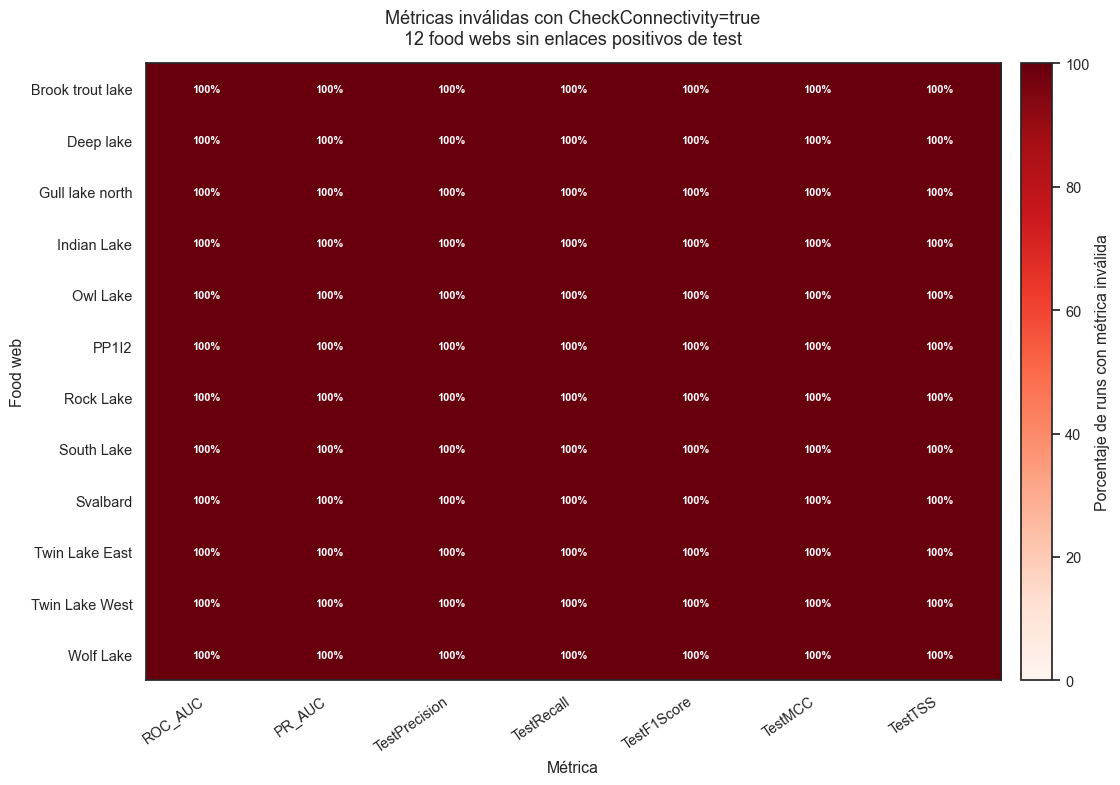

In [28]:
def metric_is_valid(metric: str) -> pl.Expr:
    """
    Una métrica es válida cuando no es null, NaN o infinita.
    """
    return (
        pl.col(metric).is_not_null()
        & pl.col(metric).is_finite()
    ).fill_null(False)


null_metrics_summary = (
    primary
    .filter(
        (pl.col("Scenario") == "checkconn_true")
        & pl.col("FoodWebLabel").is_in(
            TARGET_FOODWEBS
        )
    )
    .group_by("FoodWebLabel")
    .agg(
        pl.len().alias("RunTrainCombinations"),

        (pl.col("TestLinks") == 0)
        .sum()
        .alias("ZeroTestRuns"),

        (
            100.0
            * (pl.col("TestLinks") == 0)
            .cast(pl.Float64)
            .mean()
        ).alias("ZeroTestPercent"),

        *[
            (
                100.0
                * (
                    1.0
                    - metric_is_valid(metric)
                    .cast(pl.Float64)
                    .mean()
                )
            ).alias(metric)
            for metric in METRICS_TO_CHECK
        ],
    )
    .sort("FoodWebLabel")
)


display(
    Markdown(
        "### Ausencia de test y métricas inválidas"
    )
)

display(
    pd.DataFrame(
        null_metrics_summary.to_dicts()
    ).round(2)
)


# Matriz: food webs × métricas
null_matrix = (
    null_metrics_summary
    .select(METRICS_TO_CHECK)
    .to_numpy()
)

foodweb_labels = (
    null_metrics_summary
    .get_column("FoodWebLabel")
    .to_list()
)


fig, ax = plt.subplots(
    figsize=(12, 8)
)

image = ax.imshow(
    null_matrix,
    cmap="Reds",
    vmin=0,
    vmax=100,
    aspect="auto",
)

ax.set_xticks(
    np.arange(len(METRICS_TO_CHECK))
)

ax.set_xticklabels(
    METRICS_TO_CHECK,
    rotation=35,
    ha="right",
)

ax.set_yticks(
    np.arange(len(foodweb_labels))
)

ax.set_yticklabels(
    foodweb_labels
)

# Añadir porcentaje dentro de cada celda
for row in range(null_matrix.shape[0]):
    for column in range(null_matrix.shape[1]):
        value = null_matrix[row, column]

        text_color = (
            "white"
            if value >= 50
            else "black"
        )

        ax.text(
            column,
            row,
            f"{value:.0f}%",
            ha="center",
            va="center",
            color=text_color,
            fontsize=8,
            fontweight="bold",
        )

colorbar = fig.colorbar(
    image,
    ax=ax,
    pad=0.02,
)

colorbar.set_label(
    "Porcentaje de runs con métrica inválida"
)

ax.set_title(
    "Métricas inválidas con CheckConnectivity=true\n"
    "12 food webs sin enlaces positivos de test",
    fontsize=13,
    pad=14,
)

ax.set_xlabel("Métrica")
ax.set_ylabel("Food web")

fig.tight_layout()

if SAVE_FIGURES:
    FIG_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    output_path = (
        FIG_DIR
        / "invalid_metric_percentage_heatmap.png"
    )

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    print("Figura guardada en:")
    print(output_path)

plt.show()

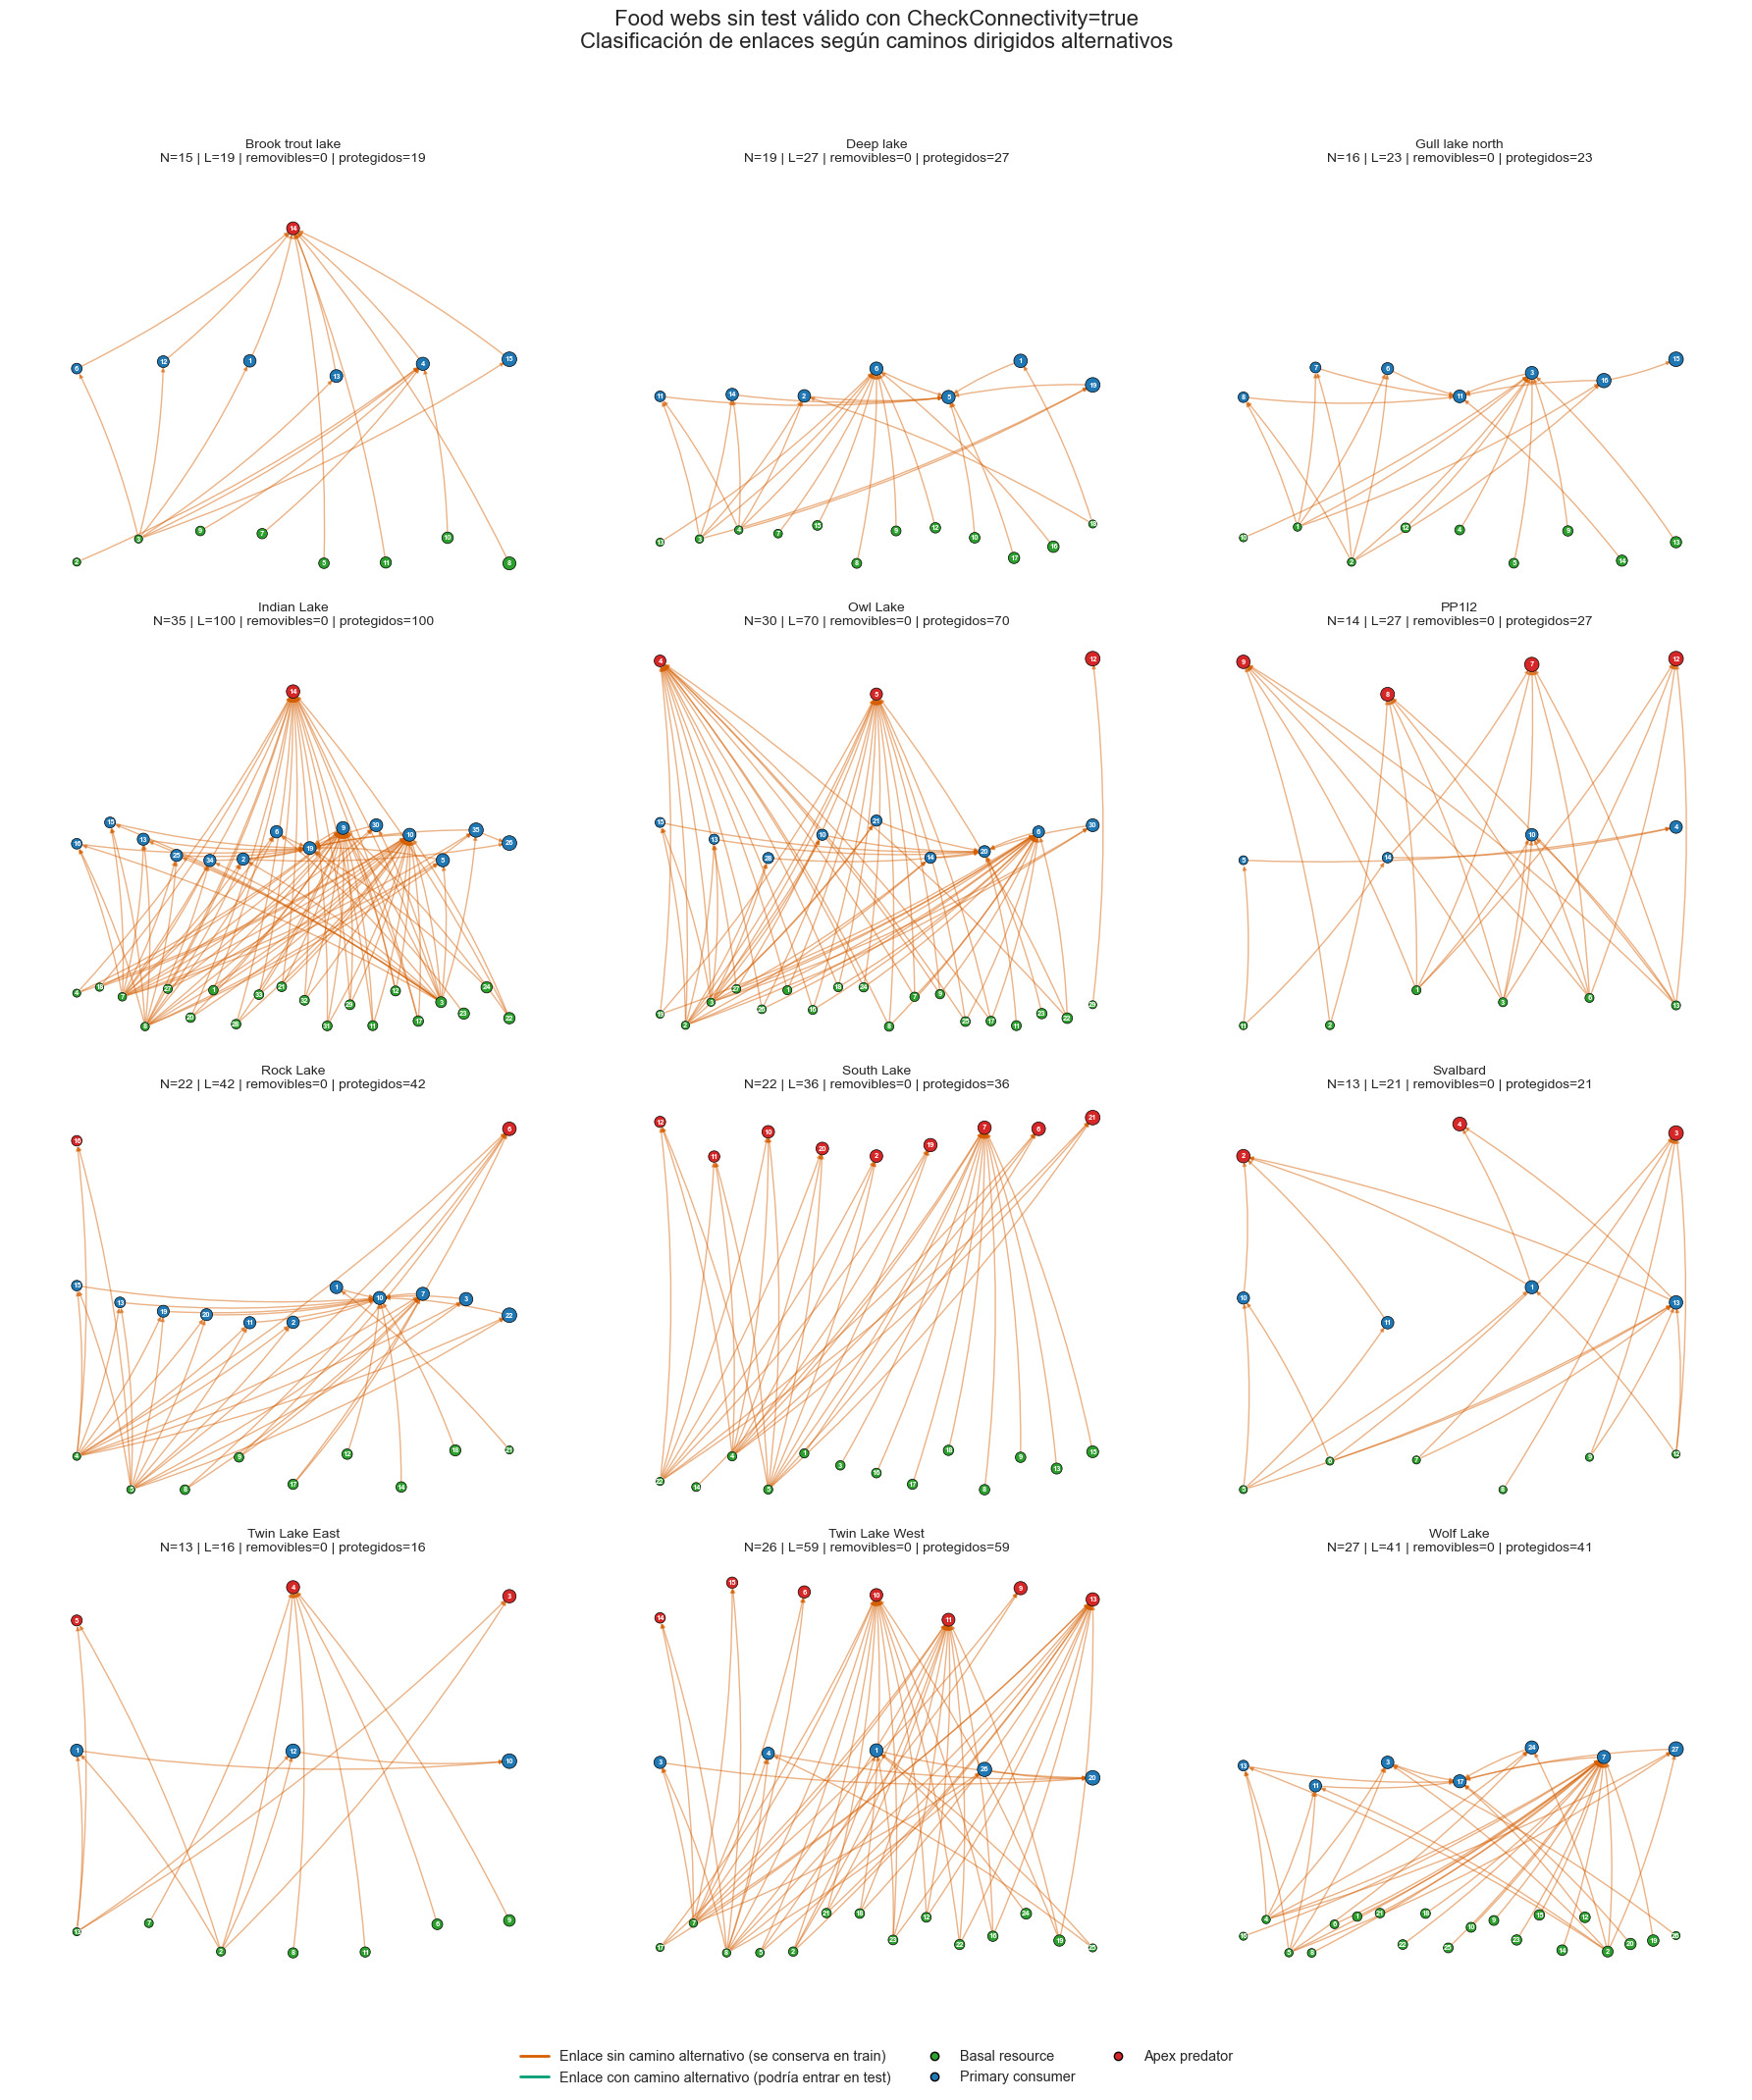

### Resumen de redundancia dirigida

,FoodWeb,Nodes,EmpiricalLinks,EdgesWithAlternativePath,ProtectedEdges,AllEdgesProtected
0,Brook trout lake,15,19,0,19,True
1,Deep lake,19,27,0,27,True
2,Gull lake north,16,23,0,23,True
3,Indian Lake,35,100,0,100,True
4,Owl Lake,30,70,0,70,True
5,PP1I2,14,27,0,27,True
6,Rock Lake,22,42,0,42,True
7,South Lake,22,36,0,36,True
8,Svalbard,13,21,0,21,True
9,Twin Lake East,13,16,0,16,True


In [29]:
# ============================================================
# Roles y colores
# ============================================================

ROLE_CODE = {
    "consumer": 1,
    "resource": 2,
    "consumer-resource": 3,
    "consumer resource": 3,
    "consumer_resource": 3,
}

ROLE_LABEL = {
    1: "Apex predator",
    2: "Basal resource",
    3: "Primary consumer",
    0: "Unknown",
}

ROLE_COLOR = {
    1: "#D62728",  # Apex predator
    2: "#2CA02C",  # Basal resource
    3: "#1F77B4",  # Primary consumer
    0: "#222222",  # Unknown
}

REMOVABLE_EDGE_COLOR = "#009E73"
PROTECTED_EDGE_COLOR = "#D55E00"


# ============================================================
# Carga de archivos MAT
# ============================================================

def matlab_string_array_to_list(values):
    array = np.asarray(values).squeeze()

    if array.ndim == 0:
        return [
            str(array.item()).strip()
        ]

    output = []

    for item in array.ravel():
        if isinstance(item, np.ndarray):
            item = np.asarray(item).squeeze()

            if item.ndim == 0:
                output.append(
                    str(item.item()).strip()
                )
            else:
                output.append(
                    "".join(
                        item.astype(str).ravel()
                    ).strip()
                )
        else:
            output.append(
                str(item).strip()
            )

    return output


def encode_role(role_value: str) -> int:
    key = str(
        role_value
    ).strip().lower()

    return ROLE_CODE.get(key, 0)


def load_foodweb_mat(foodweb_name: str) -> dict:
    mat_path = (
        MAT_DIR
        / f"{foodweb_name}_tax_mass.mat"
    )

    if not mat_path.exists():
        raise FileNotFoundError(
            f"No existe: {mat_path}"
        )

    data = loadmat(
        mat_path,
        squeeze_me=True,
        struct_as_record=False,
        spmatrix=True,
    )

    required_fields = [
        "net",
        "mass",
        "role",
    ]

    missing_fields = [
        field
        for field in required_fields
        if field not in data
    ]

    if missing_fields:
        raise KeyError(
            f"{mat_path.name}: "
            f"faltan {missing_fields}"
        )

    net = data["net"]

    if sparse.issparse(net):
        net = net.astype(bool).tocsr()
    else:
        net = sparse.csr_matrix(
            np.asarray(net) > 0
        )

    net.eliminate_zeros()

    number_nodes = net.shape[0]

    roles = matlab_string_array_to_list(
        data["role"]
    )

    if len(roles) < number_nodes:
        roles.extend(
            ["unknown"]
            * (number_nodes - len(roles))
        )

    mass = np.asarray(
        data["mass"],
        dtype=float,
    ).reshape(-1)

    if mass.size < number_nodes:
        mass = np.pad(
            mass,
            (0, number_nodes - mass.size),
            constant_values=np.nan,
        )

    return {
        "path": mat_path,
        "net": net,
        "role": roles[:number_nodes],
        "mass": mass[:number_nodes],
    }


# ============================================================
# Comprobar caminos alternativos
# ============================================================

def has_alternative_directed_path(
    adjacency: list[list[int]],
    source: int,
    target: int,
) -> bool:
    """
    Comprueba si source puede alcanzar target sin utilizar
    el enlace directo source -> target.
    """
    visited = {source}
    stack = [source]

    while stack:
        current = stack.pop()

        for neighbor in adjacency[current]:

            # Simular la eliminación de source -> target
            if (
                current == source
                and neighbor == target
            ):
                continue

            if neighbor == target:
                return True

            if neighbor not in visited:
                visited.add(neighbor)
                stack.append(neighbor)

    return False


def classify_empirical_edges(net):
    """
    Clasifica cada enlace positivo empírico según exista o no
    un camino dirigido alternativo entre sus extremos.
    """
    adjacency = [
        net.indices[
            net.indptr[node]:
            net.indptr[node + 1]
        ].tolist()
        for node in range(net.shape[0])
    ]

    source, target = net.nonzero()

    empirical_edges = [
        (int(i), int(j))
        for i, j in zip(source, target)
        if i != j
    ]

    removable_edges = []
    protected_edges = []

    for i, j in empirical_edges:
        if has_alternative_directed_path(
            adjacency,
            i,
            j,
        ):
            removable_edges.append((i, j))
        else:
            protected_edges.append((i, j))

    return {
        "empirical_edges": empirical_edges,
        "removable_edges": removable_edges,
        "protected_edges": protected_edges,
    }


# ============================================================
# Layout y dibujo
# ============================================================

def scaled_node_sizes(
    mass,
    minimum=35,
    maximum=115,
):
    mass = np.asarray(
        mass,
        dtype=float,
    )

    valid = (
        np.isfinite(mass)
        & (mass > 0)
    )

    sizes = np.full(
        mass.shape,
        minimum,
        dtype=float,
    )

    if valid.sum() >= 2:
        log_mass = np.log10(
            mass[valid]
        )

        low = np.nanmin(log_mass)
        high = np.nanmax(log_mass)

        if high > low:
            sizes[valid] = (
                minimum
                + (
                    (log_mass - low)
                    / (high - low)
                )
                * (maximum - minimum)
            )
        else:
            sizes[valid] = (
                minimum + maximum
            ) / 2

    return sizes


def role_layered_layout(
    role_codes,
    mass,
):
    """
    Layout visual por rol; no representa altura trófica calculada.
    """
    number_nodes = len(role_codes)

    y_by_role = {
        2: 0.0,  # basal
        3: 1.0,  # primary consumer
        1: 2.0,  # apex
        0: 3.0,  # unknown
    }

    positions = np.zeros(
        (number_nodes, 2),
        dtype=float,
    )

    mass = np.asarray(
        mass,
        dtype=float,
    )

    log_mass = np.full(
        number_nodes,
        np.nan,
    )

    valid_mass = (
        np.isfinite(mass)
        & (mass > 0)
    )

    log_mass[valid_mass] = np.log10(
        mass[valid_mass]
    )

    for role_code in [2, 3, 1, 0]:
        indices = np.where(
            role_codes == role_code
        )[0]

        if len(indices) == 0:
            continue

        valid_indices = indices[
            np.isfinite(log_mass[indices])
        ]

        invalid_indices = indices[
            ~np.isfinite(log_mass[indices])
        ]

        if len(valid_indices):
            valid_indices = valid_indices[
                np.argsort(
                    log_mass[valid_indices]
                )
            ]

        ordered_indices = np.concatenate([
            valid_indices,
            invalid_indices,
        ])

        if len(ordered_indices) == 1:
            x_values = np.array([0.5])
        else:
            x_values = np.linspace(
                0.08,
                0.92,
                len(ordered_indices),
            )

        y_base = y_by_role[role_code]

        for x_value, node_index in zip(
            x_values,
            ordered_indices,
        ):
            jitter = (
                0.12
                * np.sin(
                    (node_index + 1) * 2.17
                )
            )

            positions[node_index] = [
                float(x_value),
                float(y_base + jitter),
            ]

    return positions


def draw_arrow(
    axis,
    positions,
    source,
    target,
    color,
    linewidth,
    alpha,
    zorder,
):
    arrow = FancyArrowPatch(
        positions[source],
        positions[target],
        arrowstyle="-|>",
        mutation_scale=6,
        linewidth=linewidth,
        color=color,
        alpha=alpha,
        shrinkA=4,
        shrinkB=4,
        connectionstyle="arc3,rad=0.06",
        zorder=zorder,
    )

    axis.add_patch(arrow)


# ============================================================
# Dibujar las 12 food webs
# ============================================================

number_columns = 3
number_rows = int(
    np.ceil(
        len(TARGET_FOODWEBS)
        / number_columns
    )
)

fig, axes = plt.subplots(
    number_rows,
    number_columns,
    figsize=(18, 5.4 * number_rows),
)

axes = np.asarray(
    axes
).reshape(-1)

structural_rows = []


for axis, foodweb_name in zip(
    axes,
    TARGET_FOODWEBS,
):
    foodweb = load_foodweb_mat(
        foodweb_name
    )

    net = foodweb["net"]
    mass = foodweb["mass"]

    role_codes = np.array([
        encode_role(role)
        for role in foodweb["role"]
    ])

    edge_classification = (
        classify_empirical_edges(net)
    )

    empirical_edges = edge_classification[
        "empirical_edges"
    ]

    removable_edges = edge_classification[
        "removable_edges"
    ]

    protected_edges = edge_classification[
        "protected_edges"
    ]

    positions = role_layered_layout(
        role_codes,
        mass,
    )

    node_sizes = scaled_node_sizes(
        mass
    )

    node_colors = [
        ROLE_COLOR.get(
            int(role_code),
            ROLE_COLOR[0],
        )
        for role_code in role_codes
    ]

    # Enlaces que CheckConnectivity no permitiría retirar
    for source, target in protected_edges:
        draw_arrow(
            axis=axis,
            positions=positions,
            source=source,
            target=target,
            color=PROTECTED_EDGE_COLOR,
            linewidth=1.0,
            alpha=0.48,
            zorder=1,
        )

    # Enlaces con un camino alternativo
    for source, target in removable_edges:
        draw_arrow(
            axis=axis,
            positions=positions,
            source=source,
            target=target,
            color=REMOVABLE_EDGE_COLOR,
            linewidth=1.8,
            alpha=0.9,
            zorder=2,
        )

    axis.scatter(
        positions[:, 0],
        positions[:, 1],
        s=node_sizes,
        c=node_colors,
        edgecolors="black",
        linewidths=0.5,
        zorder=3,
    )

    # Mostrar identificador de nodo
    for node, (x_value, y_value) in enumerate(
        positions,
        start=1,
    ):
        axis.text(
            x_value,
            y_value,
            str(node),
            ha="center",
            va="center",
            fontsize=5.5,
            color="white",
            fontweight="bold",
            zorder=4,
        )

    number_nodes = net.shape[0]
    number_links = len(empirical_edges)
    number_removable = len(removable_edges)
    number_protected = len(protected_edges)

    axis.set_title(
        f"{foodweb_name}\n"
        f"N={number_nodes} | "
        f"L={number_links} | "
        f"removibles={number_removable} | "
        f"protegidos={number_protected}",
        fontsize=10,
    )

    top_y = (
        3.25
        if np.any(role_codes == 0)
        else 2.25
    )

    axis.set_xlim(-0.05, 1.05)
    axis.set_ylim(-0.25, top_y)
    axis.set_xticks([])
    axis.set_yticks([])

    for spine in axis.spines.values():
        spine.set_visible(False)

    structural_rows.append({
        "FoodWeb": foodweb_name,
        "Nodes": number_nodes,
        "EmpiricalLinks": number_links,
        "EdgesWithAlternativePath": (
            number_removable
        ),
        "ProtectedEdges": number_protected,
        "AllEdgesProtected": (
            number_removable == 0
        ),
    })


# Ocultar ejes sobrantes
for axis in axes[len(TARGET_FOODWEBS):]:
    axis.set_visible(False)


legend_elements = [
    Line2D(
        [0],
        [0],
        color=PROTECTED_EDGE_COLOR,
        linewidth=2,
        label=(
            "Enlace sin camino alternativo "
            "(se conserva en train)"
        ),
    ),
    Line2D(
        [0],
        [0],
        color=REMOVABLE_EDGE_COLOR,
        linewidth=2,
        label=(
            "Enlace con camino alternativo "
            "(podría entrar en test)"
        ),
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor=ROLE_COLOR[2],
        markeredgecolor="black",
        label="Basal resource",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor=ROLE_COLOR[3],
        markeredgecolor="black",
        label="Primary consumer",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor=ROLE_COLOR[1],
        markeredgecolor="black",
        label="Apex predator",
    ),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.01),
)

fig.suptitle(
    "Food webs sin test válido con CheckConnectivity=true\n"
    "Clasificación de enlaces según caminos dirigidos alternativos",
    fontsize=16,
    y=0.995,
)

fig.tight_layout(
    rect=[0, 0.06, 1, 0.97]
)


if SAVE_FIGURES:
    FIG_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    output_path = (
        FIG_DIR
        / "strict_connectivity_invalid_foodwebs_grid.png"
    )

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    print("Figura guardada en:")
    print(output_path)


plt.show()


# ============================================================
# Resumen estructural
# ============================================================

structural_summary = (
    pd.DataFrame(structural_rows)
    .sort_values("FoodWeb")
    .reset_index(drop=True)
)

display(
    Markdown(
        "### Resumen de redundancia dirigida"
    )
)

display(structural_summary)


assert (
    structural_summary[
        "EdgesWithAlternativePath"
    ] == 0
).all(), (
    "Se encontró al menos un enlace con camino alternativo."
)

[INFO] Using Tukey-filtered inputs:
  Original: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_original_50x290_train90_thresh0p50_legacy_uppertriangular_checkconnfalse_adaptivefalse_Apocrita/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figure_inputs/predictive_train90_after_tukey.csv
  Directed-negative: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_randomeligible_roleormass_tau1p00_checkconnfalse_adaptivefalse_Apocrita/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figure_inputs/predictive_train90_after_tukey.csv
[INFO] Food webs satisfying Nodes >= 0: 290

=== Retained and paired food webs by metric ===


,Metric,Original retained food webs,Directed-negative retained food webs,Paired food webs,Original-only food webs,Directed-negative-only food webs
0,ROC-AUC,290,290,290,0,0
1,PR-AUC,290,290,290,0,0
2,F1,290,290,290,0,0
3,MCC,290,290,290,0,0
4,Precision,290,290,290,0,0
5,Recall,290,290,290,0,0
6,TSS,290,290,290,0,0



=== Tukey retention details for paired food webs ===


,Version,Metric,FoodWebs,MinimumRetainedRuns,MedianRetainedRuns,MaximumRetainedRuns
0,Directed-negative,F1,290,40,49.0,50
1,Directed-negative,PR-AUC,290,40,50.0,50
2,Directed-negative,Precision,290,38,49.0,50
3,Directed-negative,ROC-AUC,290,40,49.0,50
4,Directed-negative,Recall,290,39,50.0,50
5,Directed-negative,MCC,290,40,49.0,50
6,Directed-negative,TSS,290,41,50.0,50
7,Original,F1,290,38,49.0,50
8,Original,PR-AUC,290,38,50.0,50
9,Original,Precision,290,38,50.0,50



=== Tukey-filtered web-level predictive metric summary ===


,Version,Metric,FoodWebs,Mean,Median,SD,Variance
0,Directed-negative,F1,290,0.6159,0.6684,0.2109,0.0445
1,Directed-negative,PR-AUC,290,0.5392,0.5450,0.1603,0.0257
2,Directed-negative,Precision,290,0.9265,0.9595,0.1232,0.0152
3,Directed-negative,ROC-AUC,290,0.8632,0.8980,0.1129,0.0127
4,Directed-negative,Recall,290,0.5041,0.5422,0.2234,0.0499
5,Directed-negative,MCC,290,0.5845,0.6047,0.1863,0.0347
6,Directed-negative,TSS,290,0.4836,0.5018,0.2157,0.0465
7,Original,F1,290,0.6236,0.6710,0.1941,0.0377
8,Original,PR-AUC,290,0.5550,0.6030,0.1945,0.0378
9,Original,Precision,290,0.6706,0.7207,0.2022,0.0409



[INFO] Saved publication-ready outputs:
  PNG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_randomeligible_roleormass_tau1p00_checkconnfalse_adaptivefalse_Apocrita/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/figure_3_original_vs_dir_neg_train90_thresh0p50_tukey_iqr1p5_min50pct.png
  SVG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_randomeligible_roleormass_tau1p00_checkconnfalse_adaptivefalse_Apocrita/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/figure_3_original_vs_dir_neg_train90_thresh0p50_tukey_iqr1p5_min50pct.svg
  PDF: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_randomeligible_roleormass_tau1p00_checkconnfalse_adaptivefalse_Apocrita/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/figure_3_original_vs_dir_neg_train90_thresh0p5

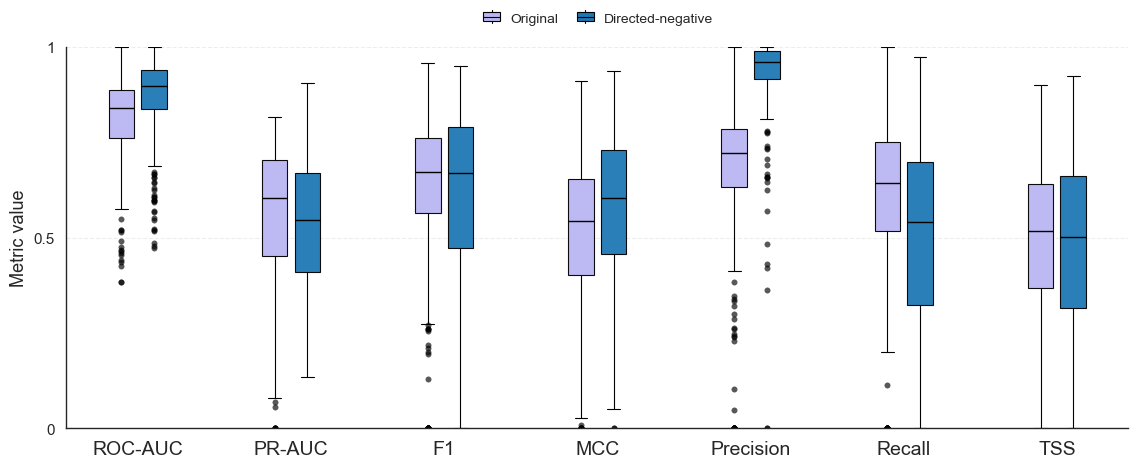

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


sns.set_theme(
    context="paper",
    style="white",
    font_scale=1.1,
)


# ============================================================
# Locate repository root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    for candidate in [start, *start.parents]:
        if (
            (candidate / "src/matlab").is_dir()
            and (candidate / "docs").is_dir()
        ):
            return candidate

    raise RuntimeError(
        f"Could not locate repository root from {start}"
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Final configuration
# ============================================================
TRAIN_RATIO_TARGET = 90
CLASSIFICATION_THRESHOLD = 0.50
NODES_THRESHOLD = 0

TAU_MASS = 1
CHECK_CONNECTIVITY = False
ADAPTIVE_CONNECTIVITY = False

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min50pct_threshold0p50_v1"
)


# ============================================================
# Corrected result roots
# ============================================================
ORIGINAL_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_original_50x290_train90_thresh0p50_"
        "legacy_uppertriangular_checkconnfalse_adaptivefalse_Apocrita"
    )
)

DIR_NEG_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_50x290_train10-90_"
        "thresh10-90_randomeligible_roleormass_"
        "tau1p00_checkconnfalse_adaptivefalse_Apocrita"
    )
)


# ============================================================
# Tukey-filtered figure inputs
# ============================================================
ORIGINAL_INPUT = (
    ORIGINAL_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figure_inputs"
    / "predictive_train90_after_tukey.csv"
)

DIR_NEG_INPUT = (
    DIR_NEG_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figure_inputs"
    / "predictive_train90_after_tukey.csv"
)

FOODWEB_CSV = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)


# ============================================================
# Publication output
# ============================================================
OUT_DIR = (
    DIR_NEG_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figures"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_STEM = (
    "figure_3_original_vs_dir_neg_"
    "train90_thresh0p50_"
    "tukey_iqr1p5_min50pct"
)

PNG_PATH = OUT_DIR / f"{OUTPUT_STEM}.png"
SVG_PATH = OUT_DIR / f"{OUTPUT_STEM}.svg"
PDF_PATH = OUT_DIR / f"{OUTPUT_STEM}.pdf"

SUMMARY_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_summary.csv"
)

RETENTION_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_retention_counts.csv"
)


# ============================================================
# Metrics
# ============================================================
METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

METRIC_ORDER = [
    metric
    for metric, _ in METRIC_SPECS
]

METRIC_LABELS = dict(METRIC_SPECS)

VERSION_ORDER = [
    "original",
    "dir_neg",
]

VERSION_LABELS = {
    "original": "Original",
    "dir_neg": "Directed-negative",
}

VERSION_PALETTE = {
    "original": "#BAB6F2",
    "dir_neg": "#1F78B4",
}

SHOW_WEB_LEVEL_FLIERS = True


# ============================================================
# Validate required inputs
# ============================================================
required_inputs = {
    "Corrected WLNM_original Tukey input": ORIGINAL_INPUT,
    "Final WLNM_dir_neg Tukey input": DIR_NEG_INPUT,
    "Food-web metadata": FOODWEB_CSV,
}

missing_inputs = [
    f"{label}:\n  {path}"
    for label, path in required_inputs.items()
    if not path.is_file()
]

if missing_inputs:
    raise FileNotFoundError(
        "The following required inputs are missing:\n\n"
        + "\n\n".join(missing_inputs)
        + (
            "\n\nThe corrected WLNM_original result must first "
            "be transferred from Apocrita and processed with "
            "apply_wlnm_tukey_retention.py."
        )
    )

print("[INFO] Using Tukey-filtered inputs:")
print(f"  Original: {ORIGINAL_INPUT}")
print(f"  Directed-negative: {DIR_NEG_INPUT}")


# ============================================================
# Helpers
# ============================================================
def normalize_fw_label(name):
    name = str(name).strip()

    for suffix in [
        ".mat",
        ".csv",
    ]:
        if name.endswith(suffix):
            name = name[: -len(suffix)]

    name = name.replace(" ", "_")

    for token in [
        "_results_",
        "_result_",
        "_results",
        "_random",
        "_tax_mass",
        "_tax",
        "_mass",
    ]:
        name = name.replace(token, "_")

    return "_".join(
        part
        for part in name.split("_")
        if part
    ).lower()


def load_tukey_figure_input(
    path,
    version,
):
    df = pd.read_csv(path)

    required_columns = {
        "Foodweb",
        "Metric",
        "MetricFamily",
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "MinimumRetainedRuns",
        "MeetsMinimumRetainedRuns",
        "TrainRatio",
        "Threshold",
    }

    missing_columns = (
        required_columns
        .difference(df.columns)
    )

    if missing_columns:
        raise ValueError(
            f"{path.name} is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    numeric_columns = [
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "MinimumRetainedRuns",
        "MeetsMinimumRetainedRuns",
        "TrainRatio",
        "Threshold",
    ]

    for column in numeric_columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce",
        )

    df = df[
        df["Metric"].isin(METRIC_ORDER)
        & df["MetricFamily"].eq("predictive")
        & np.isclose(
            df["TrainRatio"],
            TRAIN_RATIO_TARGET,
            atol=1e-8,
            equal_nan=False,
        )
        & np.isclose(
            df["Threshold"],
            CLASSIFICATION_THRESHOLD,
            atol=1e-9,
            equal_nan=False,
        )
        & df["MeetsMinimumRetainedRuns"].eq(1)
        & df["MeanAfterTukey"].notna()
    ].copy()

    df["Version"] = version
    df["Value"] = df["MeanAfterTukey"]
    df["FW_KEY"] = (
        df["Foodweb"]
        .apply(normalize_fw_label)
    )

    duplicate_mask = df.duplicated(
        subset=[
            "FW_KEY",
            "Version",
            "Metric",
        ],
        keep=False,
    )

    if duplicate_mask.any():
        duplicated = (
            df.loc[
                duplicate_mask,
                [
                    "Foodweb",
                    "Version",
                    "Metric",
                ],
            ]
            .sort_values(
                [
                    "Metric",
                    "Foodweb",
                ]
            )
        )

        display(duplicated)

        raise ValueError(
            f"Duplicated foodweb–metric rows found in {path}"
        )

    return df


# ============================================================
# Load final Tukey-filtered values
# ============================================================
original_df = load_tukey_figure_input(
    ORIGINAL_INPUT,
    version="original",
)

dir_neg_df = load_tukey_figure_input(
    DIR_NEG_INPUT,
    version="dir_neg",
)

combined_df = pd.concat(
    [
        original_df,
        dir_neg_df,
    ],
    ignore_index=True,
)


# ============================================================
# Apply node-count filter
# ============================================================
metadata_df = pd.read_csv(
    FOODWEB_CSV
)

metadata_df.columns = [
    column.strip()
    for column in metadata_df.columns
]

foodweb_column = next(
    (
        column
        for column in metadata_df.columns
        if column.lower() == "foodweb"
    ),
    None,
)

nodes_column = next(
    (
        column
        for column in metadata_df.columns
        if column.lower() in {
            "nodes",
            "n_nodes",
            "num_nodes",
            "nodecount",
            "s",
        }
    ),
    None,
)

if (
    foodweb_column is None
    or nodes_column is None
):
    raise ValueError(
        "Could not identify Foodweb and Nodes "
        "columns in the metadata file."
    )

metadata_df[nodes_column] = pd.to_numeric(
    metadata_df[nodes_column],
    errors="coerce",
)

metadata_df["FW_KEY"] = (
    metadata_df[foodweb_column]
    .apply(normalize_fw_label)
)

metadata_df = (
    metadata_df[
        [
            "FW_KEY",
            foodweb_column,
            nodes_column,
        ]
    ]
    .drop_duplicates(
        subset=["FW_KEY"]
    )
)

allowed_fw_keys = set(
    metadata_df.loc[
        metadata_df[nodes_column]
        >= NODES_THRESHOLD,
        "FW_KEY",
    ]
)

print(
    f"[INFO] Food webs satisfying "
    f"Nodes >= {NODES_THRESHOLD}: "
    f"{len(allowed_fw_keys)}"
)

combined_df = combined_df[
    combined_df["FW_KEY"]
    .isin(allowed_fw_keys)
].copy()

if combined_df.empty:
    raise RuntimeError(
        "No retained food-web metrics remain "
        "after the node-count filter."
    )


# ============================================================
# Enforce paired food webs separately per metric
# ============================================================
paired_frames = []
pairing_rows = []

for metric in METRIC_ORDER:
    metric_df = combined_df[
        combined_df["Metric"].eq(metric)
    ].copy()

    original_keys = set(
        metric_df.loc[
            metric_df["Version"].eq("original"),
            "FW_KEY",
        ]
    )

    dir_neg_keys = set(
        metric_df.loc[
            metric_df["Version"].eq("dir_neg"),
            "FW_KEY",
        ]
    )

    common_keys = (
        original_keys
        .intersection(dir_neg_keys)
    )

    pairing_rows.append({
        "Metric": METRIC_LABELS[metric],
        "Original retained food webs": len(
            original_keys
        ),
        "Directed-negative retained food webs": len(
            dir_neg_keys
        ),
        "Paired food webs": len(
            common_keys
        ),
        "Original-only food webs": len(
            original_keys - dir_neg_keys
        ),
        "Directed-negative-only food webs": len(
            dir_neg_keys - original_keys
        ),
    })

    paired_metric_df = metric_df[
        metric_df["FW_KEY"]
        .isin(common_keys)
    ].copy()

    paired_frames.append(
        paired_metric_df
    )

plot_df = pd.concat(
    paired_frames,
    ignore_index=True,
)

if plot_df.empty:
    raise RuntimeError(
        "No paired food webs remain for plotting."
    )

pairing_table = pd.DataFrame(
    pairing_rows
)

print(
    "\n=== Retained and paired food webs "
    "by metric ==="
)

display(pairing_table)


# ============================================================
# Retention details
# ============================================================
retention_table = (
    plot_df
    .groupby(
        [
            "Version",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FW_KEY",
            "nunique",
        ),
        MinimumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "min",
        ),
        MedianRetainedRuns=(
            "RetainedRunsAfterTukey",
            "median",
        ),
        MaximumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "max",
        ),
    )
)

retention_table["Version"] = (
    retention_table["Version"]
    .map(VERSION_LABELS)
)

retention_table["Metric"] = (
    retention_table["Metric"]
    .map(METRIC_LABELS)
)

retention_table = retention_table[
    [
        "Version",
        "Metric",
        "FoodWebs",
        "MinimumRetainedRuns",
        "MedianRetainedRuns",
        "MaximumRetainedRuns",
    ]
]

print(
    "\n=== Tukey retention details "
    "for paired food webs ==="
)

display(retention_table)


# ============================================================
# Web-level summary
# ============================================================
summary_table = (
    plot_df
    .groupby(
        [
            "Version",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FW_KEY",
            "nunique",
        ),
        Mean=(
            "Value",
            "mean",
        ),
        Median=(
            "Value",
            "median",
        ),
        SD=(
            "Value",
            "std",
        ),
        Variance=(
            "Value",
            "var",
        ),
    )
)

summary_table["Version"] = (
    summary_table["Version"]
    .map(VERSION_LABELS)
)

summary_table["Metric"] = (
    summary_table["Metric"]
    .map(METRIC_LABELS)
)

for column in [
    "Mean",
    "Median",
    "SD",
    "Variance",
]:
    summary_table[column] = (
        summary_table[column]
        .round(4)
    )

print(
    "\n=== Tukey-filtered web-level "
    "predictive metric summary ==="
)

display(summary_table)


# ============================================================
# Custom miniature boxplot legend
# ============================================================
class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans,
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get(
            "edgecolor",
            "black",
        )
        linewidth = orig_handle.get(
            "linewidth",
            0.6,
        )

        center_x = (
            xdescent
            + 0.5 * width
        )

        center_y = (
            ydescent
            + 0.44 * height
        )

        box_width = (
            0.8 * width
        )

        box_height = (
            0.8 * height
        )

        box_x = (
            center_x
            - box_width / 2
        )

        box_y = (
            center_y
            - box_height / 2
        )

        whisker_top_y = (
            box_y
            + box_height
            + 0.18 * height
        )

        whisker_bottom_y = (
            box_y
            - 0.18 * height
        )

        box = Rectangle(
            (
                box_x,
                box_y,
            ),
            box_width,
            box_height,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [
                box_x,
                box_x + box_width,
            ],
            [
                center_y,
                center_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        upper_whisker = Line2D(
            [
                center_x,
                center_x,
            ],
            [
                box_y + box_height,
                whisker_top_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        lower_whisker = Line2D(
            [
                center_x,
                center_x,
            ],
            [
                whisker_bottom_y,
                box_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [
            box,
            median,
            upper_whisker,
            lower_whisker,
        ]


# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(
    figsize=(11.5, 4.8)
)

group_gap = 1.5

group_centers = (
    1.0
    + np.arange(
        len(METRIC_SPECS)
    )
    * group_gap
)

offsets = {
    "original": -0.16,
    "dir_neg": 0.16,
}

box_width = 0.25

for version in VERSION_ORDER:
    version_data = []
    version_positions = []

    for metric_index, (
        metric,
        metric_label,
    ) in enumerate(METRIC_SPECS):

        values = (
            plot_df.loc[
                (
                    plot_df["Version"]
                    .eq(version)
                )
                & (
                    plot_df["Metric"]
                    .eq(metric)
                ),
                "Value",
            ]
            .dropna()
            .to_numpy()
        )

        if len(values) == 0:
            continue

        version_data.append(
            values
        )

        version_positions.append(
            group_centers[metric_index]
            + offsets[version]
        )

    ax.boxplot(
        version_data,
        positions=version_positions,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=SHOW_WEB_LEVEL_FLIERS,
        boxprops={
            "facecolor": VERSION_PALETTE[version],
            "edgecolor": "black",
            "linewidth": 0.8,
            "alpha": 0.95,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.0,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 0.8,
        },
        capprops={
            "color": "black",
            "linewidth": 0.8,
        },
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.2,
            "alpha": 0.65,
        },
    )


# ============================================================
# Axes and legend
# ============================================================
legend_handles = [
    {
        "facecolor": VERSION_PALETTE[version],
        "edgecolor": "black",
        "linewidth": 0.8,
    }
    for version in VERSION_ORDER
]

ax.set_xlim(
    group_centers[0] - 0.7,
    group_centers[-1] + 0.7,
)

ax.set_ylim(
    0,
    1.0,
)

ax.set_xticks(
    group_centers,
    labels=[
        metric_label
        for _, metric_label in METRIC_SPECS
    ],
)

plt.setp(
    ax.get_xticklabels(),
    rotation=0,
    fontsize=14,
)

ax.set_ylabel(
    "Metric value",
    fontsize=13,
)

ax.set_xlabel("")

ax.set_yticks(
    [
        0,
        0.5,
        1.0,
    ]
)

ax.set_yticklabels(
    [
        "0",
        "0.5",
        "1",
    ]
)

ax.tick_params(
    axis="y",
    labelsize=11,
)

ax.grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.35,
)

ax.legend(
    handles=legend_handles,
    labels=[
        VERSION_LABELS[version]
        for version in VERSION_ORDER
    ],
    handler_map={
        dict: HandlerMiniBoxplot()
    },
    loc="lower center",
    bbox_to_anchor=(
        0.5,
        1.03,
    ),
    ncol=len(VERSION_ORDER),
    frameon=False,
    fontsize=10,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
    columnspacing=1.2,
)

sns.despine(
    ax=ax
)

plt.tight_layout()


# ============================================================
# Export
# ============================================================
fig.savefig(
    PNG_PATH,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    SVG_PATH,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
    facecolor="white",
)

summary_table.to_csv(
    SUMMARY_PATH,
    index=False,
)

retention_table.to_csv(
    RETENTION_PATH,
    index=False,
)

print(
    "\n[INFO] Saved publication-ready outputs:"
)

print(
    f"  PNG: {PNG_PATH}"
)

print(
    f"  SVG: {SVG_PATH}"
)

print(
    f"  PDF: {PDF_PATH}"
)

print(
    f"  Summary: {SUMMARY_PATH}"
)

print(
    f"  Retention counts: {RETENTION_PATH}"
)

print(
    "\n[INFO] Final directed configuration:"
)

print(
    f"  tau_mass={TAU_MASS}"
)

print(
    f"  check_connectivity={CHECK_CONNECTIVITY}"
)

print(
    f"  adaptive_connectivity={ADAPTIVE_CONNECTIVITY}"
)

print(
    f"  classification_threshold="
    f"{CLASSIFICATION_THRESHOLD}"
)

print(
    f"  retention_protocol={PROTOCOL_NAME}"
)

plt.show()

[INFO] Validated result configuration:
  tau_mass=1.00
  check_connectivity=False
  adaptive_connectivity=False
  negative_sampling=random_eligible_pool
  eligibility=role_or_mass
  classification_threshold=0.50
  retention_protocol=tukey_iqr_1p5_min50pct_threshold0p50_v1
[INFO] Food webs after node filter: 290
[INFO] Training ratios: [10, 20, 30, 40, 50, 60, 70, 80, 90]
[INFO] Ecosystems: ['lakes', 'marine', 'streams', 'terrestrial aboveground', 'terrestrial belowground']

=== Tukey retention by training ratio and metric ===


,TRAINRATIO,Metric,MetricLabel,FoodWebs,MinimumRetainedRuns,MedianRetainedRuns,MaximumRetainedRuns
0,10,F1Score,F1,290,38,50.0,50
1,10,PR_AUC,PR-AUC,290,40,50.0,50
2,10,Precision,Precision,290,34,50.0,50
3,10,ROC_AUC,ROC-AUC,290,41,50.0,50
4,10,Recall,Recall,290,38,50.0,50
...,...,...,...,...,...,...,...
58,90,Precision,Precision,290,38,49.0,50
59,90,ROC_AUC,ROC-AUC,290,40,49.0,50
60,90,Recall,Recall,290,39,50.0,50
61,90,TestMCC,MCC,290,40,49.0,50


[INFO] Food webs represented: 290

[INFO] Saved publication-ready outputs:
  PNG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_randomeligible_roleormass_tau1p00_checkconnfalse_adaptivefalse_Apocrita/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/figure_4_predictive_metrics_by_train_ratio_tau1p00_checkconnfalse_adaptivefalse_thresh0p50_tukey_iqr1p5_min50pct.png
  SVG: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_randomeligible_roleormass_tau1p00_checkconnfalse_adaptivefalse_Apocrita/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/figure_4_predictive_metrics_by_train_ratio_tau1p00_checkconnfalse_adaptivefalse_thresh0p50_tukey_iqr1p5_min50pct.svg
  PDF: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_randomeligible_roleormass_tau1p00_checkconnfalse_adaptivefalse_Ap

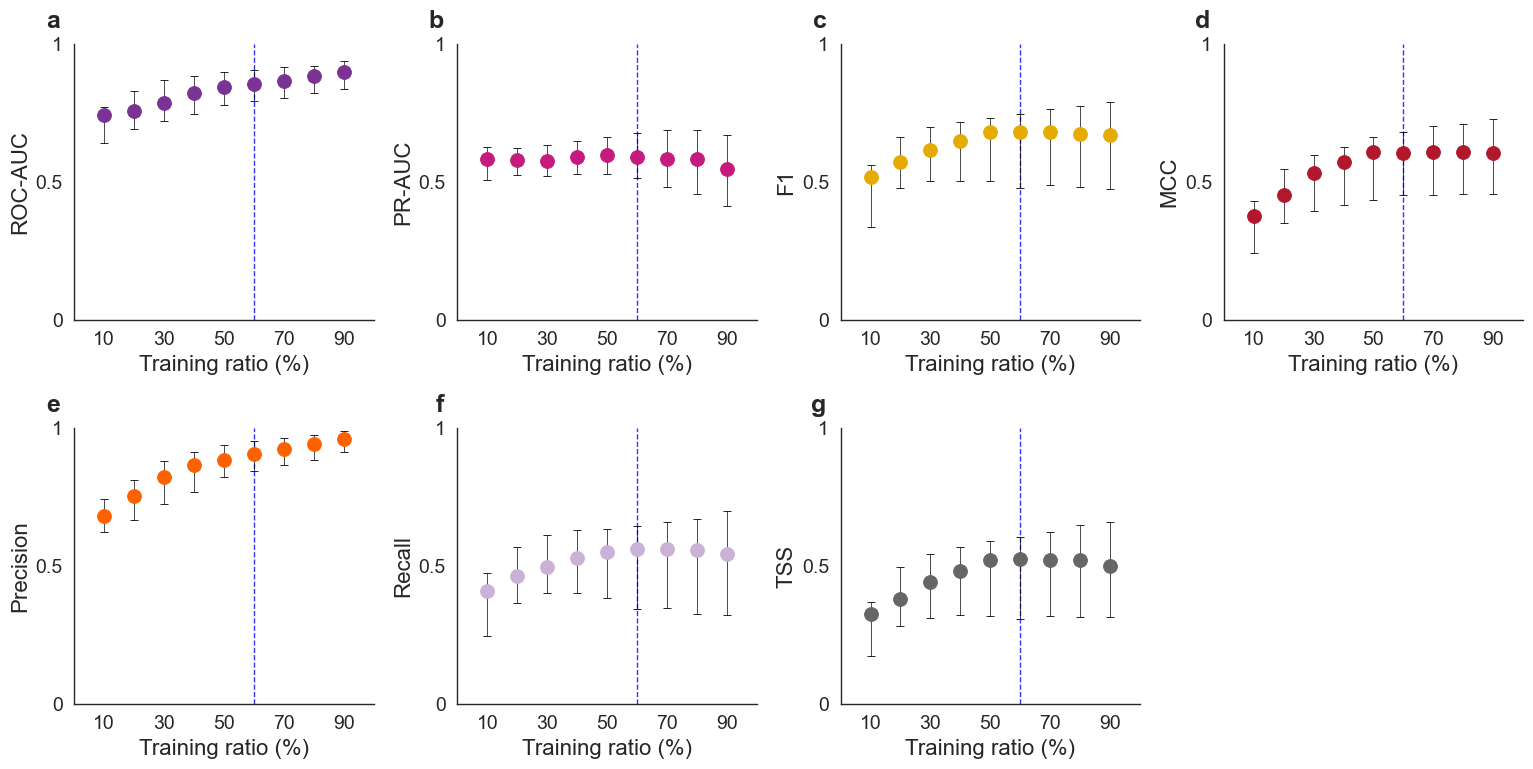

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display


sns.set_context(
    "paper",
    font_scale=1.35,
)

sns.set_style("white")


# ============================================================
# Locate repository root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    for candidate in [start, *start.parents]:
        if (
            (candidate / "src/matlab").is_dir()
            and (candidate / "docs").is_dir()
        ):
            return candidate

    raise RuntimeError(
        f"Could not locate repository root from {start}"
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Final experimental configuration
# ============================================================
TAU_MASS = 1.00
CHECK_CONNECTIVITY = False
ADAPTIVE_CONNECTIVITY = False
CLASSIFICATION_THRESHOLD = 0.50

NODES_THRESHOLD = 0

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min50pct_threshold0p50_v1"
)


# ============================================================
# Correct result root
# ============================================================
RESULT_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_50x290_train10-90_"
        "thresh10-90_randomeligible_roleormass_"
        "tau1p00_checkconnfalse_adaptivefalse_Apocrita"
    )
)

MANIFEST_PATH = (
    RESULT_ROOT
    / "RUN_MANIFEST.txt"
)

RESULTS_FILE = (
    RESULT_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figure_inputs"
    / "predictive_train10-90_after_tukey.csv"
)

FOODWEB_CSV = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)


# ============================================================
# Output paths
# ============================================================
OUT_DIR = (
    RESULT_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figures"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_STEM = (
    "figure_4_predictive_metrics_by_train_ratio_"
    "tau1p00_checkconnfalse_adaptivefalse_"
    "thresh0p50_tukey_iqr1p5_min50pct"
)

PNG_PATH = OUT_DIR / f"{OUTPUT_STEM}.png"
SVG_PATH = OUT_DIR / f"{OUTPUT_STEM}.svg"
PDF_PATH = OUT_DIR / f"{OUTPUT_STEM}.pdf"

SUMMARY_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_summary.csv"
)

RETENTION_PATH = (
    OUT_DIR
    / f"{OUTPUT_STEM}_retention.csv"
)


# ============================================================
# Metrics
# ============================================================
METRICS = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

METRIC_LABELS = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
}

METRIC_PALETTE = {
    "ROC-AUC": "#7B3294",
    "PR-AUC": "#C51B7D",
    "F1": "#E6AB02",
    "MCC": "#B2182B",
    "Precision": "#FE6100",
    "Recall": "#CAB2D6",
    "TSS": "#666666",
}

SHOW_GRID = False

Y_MIN = 0.0
Y_MAX = 1.0

INDEPENDENT_Y = False
Y_PADDING = 0.02

REFERENCE_TRAIN_RATIO = 60


# ============================================================
# Validate files
# ============================================================
required_files = {
    "RUN_MANIFEST.txt": MANIFEST_PATH,
    "Tukey-filtered predictive input": RESULTS_FILE,
    "Food-web metadata": FOODWEB_CSV,
}

missing_files = [
    f"{label}:\n  {path}"
    for label, path in required_files.items()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "The following required files are missing:\n\n"
        + "\n\n".join(missing_files)
    )


# ============================================================
# Validate manifest configuration
# ============================================================
def read_manifest(path):
    values = {}

    for line in path.read_text(
        encoding="utf-8",
        errors="replace",
    ).splitlines():

        if "=" not in line:
            continue

        key, value = line.split(
            "=",
            maxsplit=1,
        )

        values[key.strip()] = value.strip()

    return values


manifest = read_manifest(
    MANIFEST_PATH
)

expected_manifest = {
    "TauMass": "1.00",
    "CheckConnectivity": "false",
    "AdaptiveConnectivity": "false",
    "NegativeSampling": "random_eligible_pool",
    "Eligibility": "role_or_mass",
    "PrioritySampling": "false",
}

configuration_errors = []

for key, expected_value in expected_manifest.items():
    observed_value = manifest.get(key)

    if observed_value != expected_value:
        configuration_errors.append(
            f"{key}: expected {expected_value!r}, "
            f"observed {observed_value!r}"
        )

if configuration_errors:
    raise ValueError(
        "The selected result root does not match the "
        "requested configuration:\n\n"
        + "\n".join(configuration_errors)
    )

print("[INFO] Validated result configuration:")
print(f"  tau_mass={TAU_MASS:.2f}")
print(f"  check_connectivity={CHECK_CONNECTIVITY}")
print(f"  adaptive_connectivity={ADAPTIVE_CONNECTIVITY}")
print(
    "  negative_sampling="
    f"{manifest['NegativeSampling']}"
)
print(
    "  eligibility="
    f"{manifest['Eligibility']}"
)
print(
    "  classification_threshold="
    f"{CLASSIFICATION_THRESHOLD:.2f}"
)
print(f"  retention_protocol={PROTOCOL_NAME}")


# ============================================================
# Food-web name normalisation
# ============================================================
def normalize_fw_label(name):
    name = str(name).strip()

    for suffix in [
        ".mat",
        ".csv",
    ]:
        if name.endswith(suffix):
            name = name[: -len(suffix)]

    name = name.replace(
        " ",
        "_",
    )

    for token in [
        "_results_",
        "_result_",
        "_results",
        "_random",
        "_tax_mass",
        "_tax",
        "_mass",
    ]:
        name = name.replace(
            token,
            "_",
        )

    return "_".join(
        part
        for part in name.split("_")
        if part
    ).lower()


# ============================================================
# Load Tukey-filtered web-level results
# ============================================================
df = pd.read_csv(
    RESULTS_FILE
)

required_columns = {
    "Foodweb",
    "Metric",
    "MetricLabel",
    "MetricFamily",
    "TrainRatio",
    "Threshold",
    "MeanAfterTukey",
    "RetainedRunsAfterTukey",
    "MinimumRetainedRuns",
    "MeetsMinimumRetainedRuns",
}

missing_columns = (
    required_columns
    .difference(df.columns)
)

if missing_columns:
    raise ValueError(
        f"{RESULTS_FILE.name} is missing required columns: "
        f"{sorted(missing_columns)}"
    )

numeric_columns = [
    "TrainRatio",
    "Threshold",
    "MeanAfterTukey",
    "RetainedRunsAfterTukey",
    "MinimumRetainedRuns",
    "MeetsMinimumRetainedRuns",
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce",
    )


# ============================================================
# Enforce the requested configuration
# ============================================================
df = df[
    df["MetricFamily"].eq("predictive")
    & df["Metric"].isin(METRICS)
    & np.isclose(
        df["Threshold"],
        CLASSIFICATION_THRESHOLD,
        atol=1e-9,
        equal_nan=False,
    )
    & df["MeetsMinimumRetainedRuns"].eq(1)
    & df["MeanAfterTukey"].notna()
].copy()

if df.empty:
    raise RuntimeError(
        "No retained predictive results remain after "
        "applying the final configuration."
    )

df["TRAINRATIO"] = (
    df["TrainRatio"]
    .round()
    .astype(int)
)

df["Value"] = (
    df["MeanAfterTukey"]
)

df["FW_KEY"] = (
    df["Foodweb"]
    .apply(normalize_fw_label)
)


# ============================================================
# Validate unique web-level observations
# ============================================================
duplicate_mask = df.duplicated(
    subset=[
        "FW_KEY",
        "TRAINRATIO",
        "Metric",
    ],
    keep=False,
)

if duplicate_mask.any():
    duplicated = (
        df.loc[
            duplicate_mask,
            [
                "Foodweb",
                "TRAINRATIO",
                "Metric",
            ],
        ]
        .sort_values(
            [
                "Metric",
                "TRAINRATIO",
                "Foodweb",
            ]
        )
    )

    display(duplicated)

    raise ValueError(
        "Duplicated Foodweb × TrainRatio × Metric "
        "rows were found."
    )


# ============================================================
# Load food-web metadata
# ============================================================
metadata = pd.read_csv(
    FOODWEB_CSV
)

metadata.columns = [
    column.strip()
    for column in metadata.columns
]

foodweb_column = next(
    (
        column
        for column in metadata.columns
        if column.lower() == "foodweb"
    ),
    None,
)

nodes_column = next(
    (
        column
        for column in metadata.columns
        if column.lower() in {
            "nodes",
            "n_nodes",
            "num_nodes",
            "nodecount",
            "s",
        }
    ),
    None,
)

ecosystem_column = next(
    (
        column
        for column in metadata.columns
        if column.lower() in {
            "ecosystem",
            "ecosystemtype",
            "ecosystem_type",
        }
    ),
    None,
)

if (
    foodweb_column is None
    or nodes_column is None
    or ecosystem_column is None
):
    raise ValueError(
        "Could not identify Foodweb, Nodes, and "
        "Ecosystem columns in the metadata."
    )

metadata[nodes_column] = pd.to_numeric(
    metadata[nodes_column],
    errors="coerce",
)

metadata["FW_KEY"] = (
    metadata[foodweb_column]
    .apply(normalize_fw_label)
)

metadata = (
    metadata[
        [
            "FW_KEY",
            nodes_column,
            ecosystem_column,
        ]
    ]
    .drop_duplicates(
        subset=["FW_KEY"]
    )
    .rename(
        columns={
            nodes_column: "Nodes",
            ecosystem_column: "Ecosystem",
        }
    )
)


# ============================================================
# Merge metadata and apply node filter
# ============================================================
df = df.merge(
    metadata,
    on="FW_KEY",
    how="left",
    validate="many_to_one",
)

missing_metadata = (
    df.loc[
        df["Nodes"].isna(),
        "Foodweb",
    ]
    .drop_duplicates()
    .sort_values()
)

if not missing_metadata.empty:
    print(
        "[WARNING] Food webs without node metadata:"
    )

    display(
        missing_metadata.to_frame(
            name="Foodweb"
        )
    )

df = df[
    df["Nodes"] >= NODES_THRESHOLD
].copy()

if df.empty:
    raise RuntimeError(
        f"No food webs remain after applying "
        f"Nodes >= {NODES_THRESHOLD}."
    )

print(
    f"[INFO] Food webs after node filter: "
    f"{df['FW_KEY'].nunique()}"
)

print(
    "[INFO] Training ratios: "
    f"{sorted(df['TRAINRATIO'].unique().tolist())}"
)

print(
    "[INFO] Ecosystems: "
    f"{sorted(df['Ecosystem'].dropna().unique().tolist())}"
)


# ============================================================
# Retention report
# ============================================================
retention_table = (
    df
    .groupby(
        [
            "TRAINRATIO",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FW_KEY",
            "nunique",
        ),
        MinimumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "min",
        ),
        MedianRetainedRuns=(
            "RetainedRunsAfterTukey",
            "median",
        ),
        MaximumRetainedRuns=(
            "RetainedRunsAfterTukey",
            "max",
        ),
    )
)

retention_table["MetricLabel"] = (
    retention_table["Metric"]
    .map(METRIC_LABELS)
)

retention_table = retention_table[
    [
        "TRAINRATIO",
        "Metric",
        "MetricLabel",
        "FoodWebs",
        "MinimumRetainedRuns",
        "MedianRetainedRuns",
        "MaximumRetainedRuns",
    ]
]

print(
    "\n=== Tukey retention by training ratio "
    "and metric ==="
)

display(
    retention_table
)


# ============================================================
# Across-food-web summary
# ============================================================
summary = (
    df
    .groupby(
        [
            "TRAINRATIO",
            "Metric",
        ],
        as_index=False,
    )
    .agg(
        median=(
            "Value",
            "median",
        ),
        q25=(
            "Value",
            lambda values: values.quantile(0.25),
        ),
        q75=(
            "Value",
            lambda values: values.quantile(0.75),
        ),
        mean=(
            "Value",
            "mean",
        ),
        sd=(
            "Value",
            "std",
        ),
        n_webs=(
            "FW_KEY",
            "nunique",
        ),
    )
)

summary["MetricLabel"] = (
    summary["Metric"]
    .map(METRIC_LABELS)
)

train_ratios = sorted(
    summary["TRAINRATIO"]
    .unique()
    .tolist()
)

print(
    f"[INFO] Food webs represented: "
    f"{df['FW_KEY'].nunique()}"
)


# ============================================================
# Consistent metric colours
# ============================================================
metric_colors = {
    metric: METRIC_PALETTE[
        METRIC_LABELS[metric]
    ]
    for metric in METRICS
}


# ============================================================
# Final plot
# ============================================================
number_of_metrics = len(METRICS)

number_of_rows = 2

number_of_columns = int(
    np.ceil(
        number_of_metrics
        / number_of_rows
    )
)

fig, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(
        4 * number_of_columns,
        8.0,
    ),
    sharex=False,
    sharey=False,
)

axes = np.asarray(
    axes
).reshape(
    number_of_rows,
    number_of_columns,
)

axes_flat = axes.flatten()

panel_letters = list(
    "abcdefghijklmnopqrstuvwxyz"
)

for index, metric in enumerate(METRICS):
    ax = axes_flat[index]

    panel_df = (
        summary[
            summary["Metric"].eq(metric)
        ]
        .sort_values("TRAINRATIO")
    )

    if panel_df.empty:
        ax.set_axis_off()
        continue

    x_values = (
        panel_df["TRAINRATIO"]
        .to_numpy()
    )

    median_values = (
        panel_df["median"]
        .to_numpy()
    )

    error_values = np.vstack(
        [
            (
                panel_df["median"]
                - panel_df["q25"]
            ).to_numpy(),
            (
                panel_df["q75"]
                - panel_df["median"]
            ).to_numpy(),
        ]
    )

    color = metric_colors[metric]

    ax.errorbar(
        x_values,
        median_values,
        yerr=error_values,
        fmt="o",
        linestyle="none",
        color=color,
        ecolor="black",
        markersize=10,
        linewidth=1.2,
        elinewidth=0.5,
        capsize=3,
        capthick=0.8,
        markerfacecolor=color,
        markeredgecolor=color,
        markeredgewidth=0.6,
    )

    ax.axvline(
        x=REFERENCE_TRAIN_RATIO,
        color="blue",
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
        zorder=0,
    )

    if INDEPENDENT_Y:
        local_minimum = max(
            Y_MIN,
            panel_df["q25"].min()
            - Y_PADDING,
        )

        local_maximum = min(
            Y_MAX,
            panel_df["q75"].max()
            + Y_PADDING,
        )

        if np.isclose(
            local_minimum,
            local_maximum,
        ):
            local_minimum = max(
                Y_MIN,
                local_minimum - 0.02,
            )

            local_maximum = min(
                Y_MAX,
                local_maximum + 0.02,
            )

        ax.set_ylim(
            local_minimum,
            local_maximum,
        )

    else:
        ax.set_ylim(
            Y_MIN,
            Y_MAX,
        )

        ax.set_yticks(
            [
                0,
                0.5,
                1.0,
            ]
        )

        ax.set_yticklabels(
            [
                "0",
                "0.5",
                "1",
            ]
        )

    if SHOW_GRID:
        ax.grid(
            True,
            axis="y",
            linestyle="--",
            alpha=0.30,
        )
    else:
        ax.grid(False)

    visible_ticks = [
        ratio
        for ratio in [
            10,
            30,
            50,
            70,
            90,
        ]
        if ratio in train_ratios
    ]

    ax.set_xticks(
        visible_ticks
    )

    ax.set_xticklabels(
        [
            str(ratio)
            for ratio in visible_ticks
        ]
    )

    ax.set_xlim(
        min(train_ratios) - 10,
        max(train_ratios) + 10,
    )

    ax.set_xlabel(
        "Training ratio (%)",
        fontsize=16,
    )

    ax.set_ylabel(
        METRIC_LABELS[metric],
        fontsize=16,
    )

    ax.set_title("")

    if index < len(panel_letters):
        ax.annotate(
            panel_letters[index],
            xy=(0, 1),
            xycoords="axes fraction",
            xytext=(-10, 8),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=18,
            fontweight="bold",
            annotation_clip=False,
        )

    ax.tick_params(
        axis="both",
        labelsize=14,
    )

    sns.despine(
        ax=ax
    )


# ============================================================
# Hide unused panels
# ============================================================
for index in range(
    number_of_metrics,
    len(axes_flat),
):
    axes_flat[index].set_axis_off()


# ============================================================
# Layout and export
# ============================================================
fig.tight_layout(
    rect=[
        0.03,
        0,
        1,
        0.985,
    ]
)

fig.savefig(
    PNG_PATH,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    SVG_PATH,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
    facecolor="white",
)

summary.to_csv(
    SUMMARY_PATH,
    index=False,
)

retention_table.to_csv(
    RETENTION_PATH,
    index=False,
)

print(
    "\n[INFO] Saved publication-ready outputs:"
)

print(f"  PNG: {PNG_PATH}")
print(f"  SVG: {SVG_PATH}")
print(f"  PDF: {PDF_PATH}")
print(f"  Summary: {SUMMARY_PATH}")
print(f"  Retention: {RETENTION_PATH}")

plt.show()

[INFO] Source file: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_randomeligible_roleormass_tau1p00_checkconnfalse_adaptivefalse_Apocrita/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figure_inputs/ecological_train60_after_tukey.csv
[INFO] Loaded outlier-filtered web-level rows: 1,159
[INFO] Plotting rows after empirical/mean-pseudo expansion: 2,318
[INFO] Each food web contributes one empirical value and one filtered mean pseudo value.
[INFO] Mean pseudo values were calculated after removing pseudo-run outliers.
[INFO] Configuration: tau_mass=1.00, check_connectivity=False, adaptive_connectivity=False, classification_threshold=0.50.


,Metric,FoodWebs,TotalPseudoRunOutliersRemoved,MinRetainedRuns,MedianRetainedRuns
0,Connectance,290,267,41,50.0
1,MeanGenerality,290,343,42,49.0
2,MeanTrophicHeight,289,1051,27,44.0
3,MeanVulnerability,290,271,43,49.0


[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_randomeligible_roleormass_tau1p00_checkconnfalse_adaptivefalse_Apocrita/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/fig5_wlnm_dir_neg_train60_tau1p00_checkconnfalse_adaptivefalse_threshold0p50_tukey_filtered.png


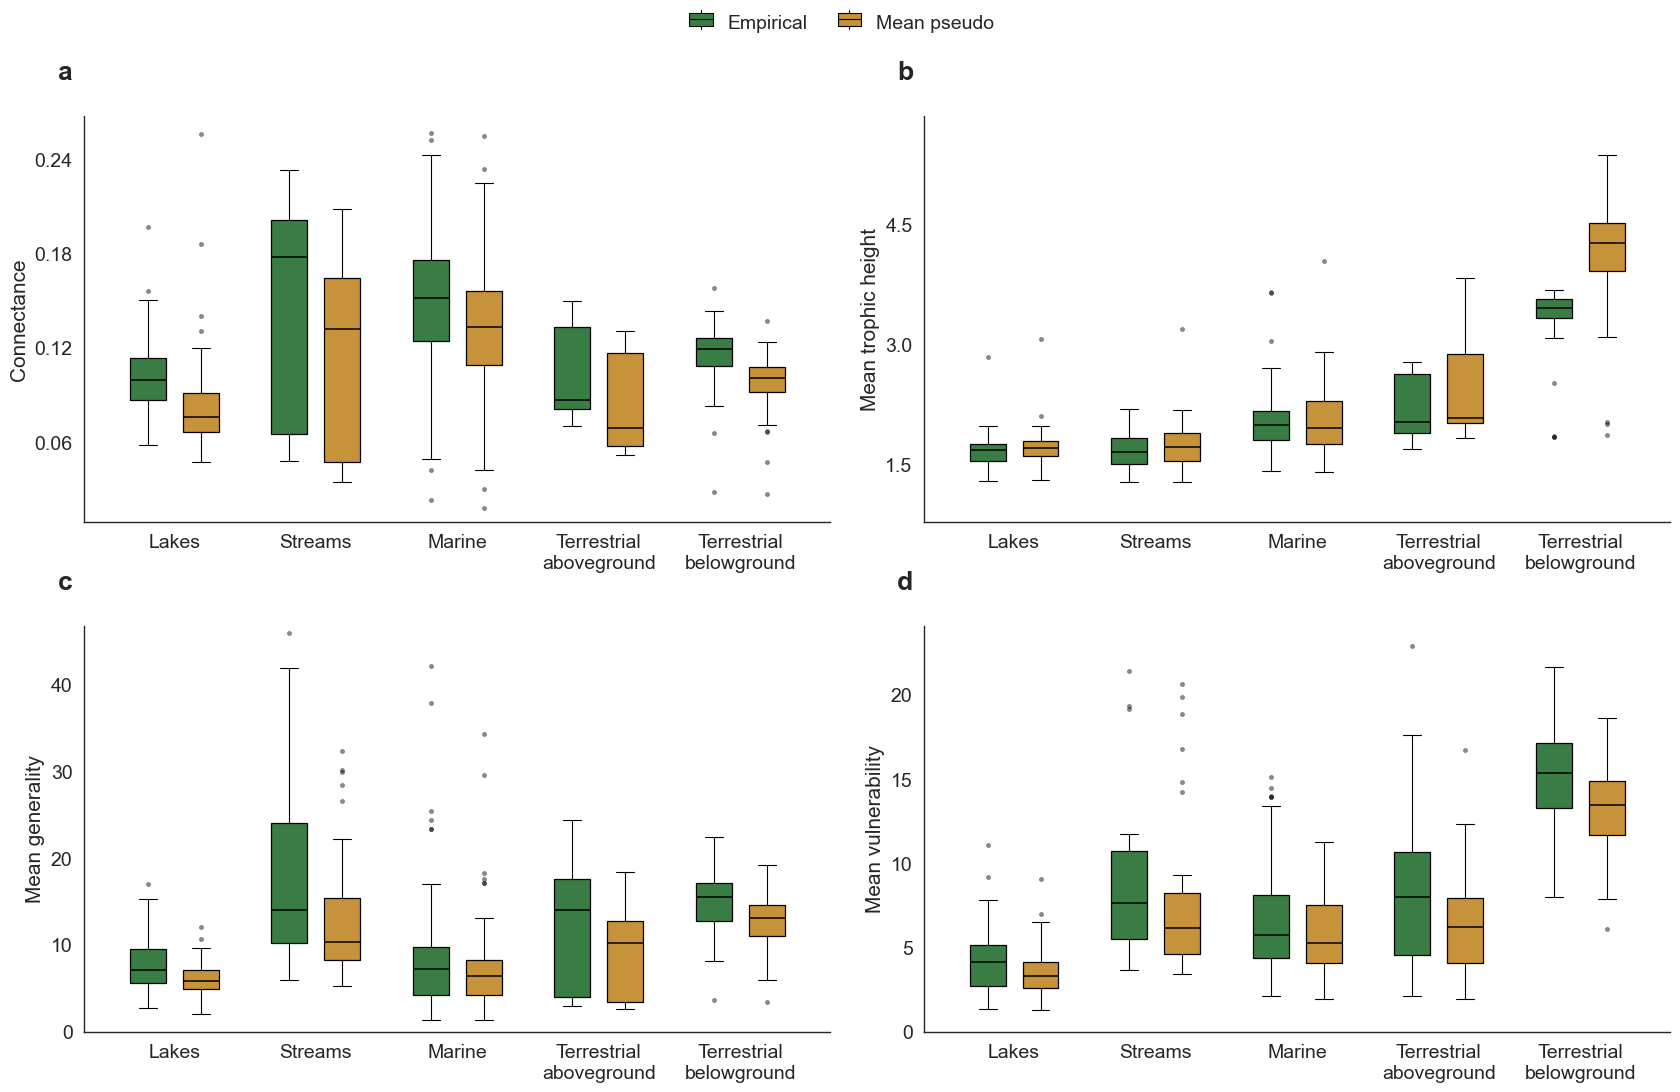

In [9]:
import math
import numpy as np
import pandas as pd
import seaborn as sns

from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase
from matplotlib.ticker import MaxNLocator


sns.set_theme(
    context="paper",
    style="white",
    font_scale=1.15,
)


# ============================================================
# Locate repo root
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    for path in [start, *start.parents]:
        if (
            (path / "src/matlab").exists()
            and (path / "docs").exists()
        ):
            return path

    raise RuntimeError(
        f"Could not locate repo root from {start}"
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Final data configuration
# ============================================================

TRAIN_RATIO = 60
CLASSIFICATION_THRESHOLD = 0.50

TAU_MASS = 1.00
CHECK_CONNECTIVITY = False
ADAPTIVE_CONNECTIVITY = False

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min50pct_threshold0p50_v1"
)


# ============================================================
# Final corrected result input
# ============================================================

RESULT_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_50x290_train10-90_"
        "thresh10-90_randomeligible_roleormass_"
        "tau1p00_checkconnfalse_adaptivefalse_Apocrita"
    )
)

RETENTION_ROOT = (
    RESULT_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
)

ECOLOGICAL_INPUT = (
    RETENTION_ROOT
    / "figure_inputs"
    / f"ecological_train{TRAIN_RATIO}_after_tukey.csv"
)

FOODWEB_METADATA = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)

RUN_MANIFEST = (
    RESULT_ROOT
    / "RUN_MANIFEST.txt"
)

OUT_DIR = (
    RETENTION_ROOT
    / "figures"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUT_PATH = (
    OUT_DIR
    / (
        f"fig5_wlnm_dir_neg_train{TRAIN_RATIO}_"
        "tau1p00_checkconnfalse_adaptivefalse_"
        "threshold0p50_tukey_filtered.png"
    )
)


# ============================================================
# Validate input configuration
# ============================================================

required_files = {
    "Tukey-filtered ecological input": ECOLOGICAL_INPUT,
    "Food-web metadata": FOODWEB_METADATA,
    "Run manifest": RUN_MANIFEST,
}

missing_files = [
    f"{label}:\n  {path}"
    for label, path in required_files.items()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "Missing required files:\n\n"
        + "\n\n".join(missing_files)
    )


def read_manifest(path):
    values = {}

    with path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        for line in handle:
            line = line.strip()

            if not line or "=" not in line:
                continue

            key, value = line.split("=", 1)
            values[key.strip()] = value.strip()

    return values


manifest = read_manifest(RUN_MANIFEST)

expected_manifest = {
    "Version": "WLNM_dir_neg",
    "TauMass": "1.00",
    "CheckConnectivity": "false",
    "AdaptiveConnectivity": "false",
    "NegativeSampling": "random_eligible_pool",
    "Eligibility": "role_or_mass",
    "PrioritySampling": "false",
}

configuration_errors = []

for key, expected in expected_manifest.items():
    observed = manifest.get(key)

    if observed is None:
        configuration_errors.append(
            f"{key}: missing"
        )
    elif observed.casefold() != expected.casefold():
        configuration_errors.append(
            f"{key}: expected {expected}, found {observed}"
        )

if configuration_errors:
    raise ValueError(
        "The selected result root does not match the final "
        "configuration:\n\n"
        + "\n".join(configuration_errors)
    )


# ============================================================
# CONFIG — original styling preserved
# ============================================================

BOX_WIDTH = 0.30
TYPE_OFFSET = 0.22
GROUP_SPACING = 1.18

# These are web-level boxplot fliers, not pseudo-run outliers.
# Pseudo-run outliers were removed before MeanPseudoAfterFiltering.
SHOW_WEB_LEVEL_FLIERS = True

base_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}

metric_order = [
    "Connectance",
    "MeanTrophicHeight",
    "MeanGenerality",
    "MeanVulnerability",
]

metric_labels = {
    "Connectance": "Connectance",
    "MeanTrophicHeight": "Mean trophic height",
    "MeanGenerality": "Mean generality",
    "MeanVulnerability": "Mean vulnerability",
}

panel_letters = list(
    "abcdefghijklmnopqrstuvwxyz"
)

type_palette = {
    "Empirical": "#3A7D44",
    "Mean pseudo": "#C6923A",
}


# ============================================================
# HELPERS — original styling preserved
# ============================================================

def format_ecosystem_label(eco: str) -> str:
    eco_clean = str(eco).strip().lower()

    return ecosystem_labels.get(
        eco_clean,
        str(eco).strip().capitalize(),
    )


def draw_box(
    ax,
    values,
    position,
    facecolor,
    showfliers=False,
):
    ax.boxplot(
        values,
        positions=[position],
        widths=BOX_WIDTH,
        patch_artist=True,
        manage_ticks=False,
        showfliers=showfliers,
        boxprops={
            "facecolor": facecolor,
            "edgecolor": "black",
            "linewidth": 0.9,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.1,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 0.8,
        },
        capprops={
            "color": "black",
            "linewidth": 0.8,
        },
        flierprops={
            "marker": "o",
            "markersize": 3.0,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.4,
            "linestyle": "none",
            "alpha": 0.45,
        },
    )


def get_boxplot_visible_ylim(
    grouped_values,
    lower_bound=0.0,
    pad_fraction=0.12,
):
    visible_lows = []
    visible_highs = []

    for values in grouped_values:
        values = np.asarray(
            values,
            dtype=float,
        )

        values = values[
            np.isfinite(values)
        ]

        if values.size == 0:
            continue

        q1, q3 = np.nanpercentile(
            values,
            [25, 75],
        )

        iqr = q3 - q1

        if np.isclose(iqr, 0):
            lower_whisker = np.nanmin(values)
            upper_whisker = np.nanmax(values)
        else:
            lower_fence = q1 - 1.5 * iqr
            upper_fence = q3 + 1.5 * iqr

            non_fliers = values[
                (values >= lower_fence)
                & (values <= upper_fence)
            ]

            if non_fliers.size == 0:
                non_fliers = values

            lower_whisker = np.nanmin(
                non_fliers
            )

            upper_whisker = np.nanmax(
                non_fliers
            )

        visible_lows.extend([
            lower_whisker,
            q1,
        ])

        visible_highs.extend([
            upper_whisker,
            q3,
        ])

    if not visible_lows or not visible_highs:
        return None

    local_min = np.nanmin(
        visible_lows
    )

    local_max = np.nanmax(
        visible_highs
    )

    data_range = (
        local_max - local_min
        if local_max > local_min
        else 0.05
    )

    local_min = max(
        lower_bound,
        local_min - pad_fraction * data_range,
    )

    local_max = (
        local_max
        + pad_fraction * data_range
    )

    if np.isclose(
        local_min,
        local_max,
    ):
        local_min = max(
            lower_bound,
            local_min - 0.02,
        )

        local_max = (
            local_max + 0.02
        )

    return local_min, local_max


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans,
    ):
        facecolor = orig_handle[
            "facecolor"
        ]

        edgecolor = orig_handle.get(
            "edgecolor",
            "black",
        )

        linewidth = orig_handle.get(
            "linewidth",
            0.8,
        )

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = (
            box_y
            + box_h
            + 0.18 * height
        )

        whisk_bot_y = (
            box_y
            - 0.18 * height
        )

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [
                box_x,
                box_x + box_w,
            ],
            [
                cy,
                cy,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [
                cx,
                cx,
            ],
            [
                box_y + box_h,
                whisk_top_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [
                cx,
                cx,
            ],
            [
                whisk_bot_y,
                box_y,
            ],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [
            box,
            median,
            whisker_top,
            whisker_bottom,
        ]


# ============================================================
# LOAD NEW TUKEY-FILTERED INPUT
# ============================================================

def normalise_foodweb(value):
    value = Path(
        str(value).strip()
    ).name

    for extension in (
        ".mat",
        ".csv",
    ):
        if value.lower().endswith(
            extension
        ):
            value = value[
                :-len(extension)
            ].rstrip()

    for suffix in (
        "_tax_mass",
        "_taxmass",
    ):
        if value.lower().endswith(
            suffix
        ):
            value = value[
                :-len(suffix)
            ].rstrip()

    return " ".join(
        value.casefold().split()
    )


raw_results = pd.read_csv(
    ECOLOGICAL_INPUT
)

required_result_columns = {
    "Foodweb",
    "TrainRatio",
    "Threshold",
    "Metric",
    "MetricFamily",
    "MeanAfterTukey",
    "ReferenceValue",
    "RetainedRunsAfterTukey",
    "OutlierRunsExcluded",
    "MeetsMinimumRetainedRuns",
}

missing_result_columns = sorted(
    required_result_columns.difference(
        raw_results.columns
    )
)

if missing_result_columns:
    raise ValueError(
        "The Tukey-filtered input is missing columns:\n  "
        + "\n  ".join(
            missing_result_columns
        )
    )

numeric_result_columns = [
    "TrainRatio",
    "Threshold",
    "MeanAfterTukey",
    "ReferenceValue",
    "RetainedRunsAfterTukey",
    "OutlierRunsExcluded",
    "MeetsMinimumRetainedRuns",
]

for column in numeric_result_columns:
    raw_results[column] = pd.to_numeric(
        raw_results[column],
        errors="coerce",
    )


new_to_original_metrics = {
    "PseudoConnectance": "Connectance",
    "PseudoMeanTrophicHeight": "MeanTrophicHeight",
    "PseudoMeanGenerality": "MeanGenerality",
    "PseudoMeanVulnerability": "MeanVulnerability",
}

athen = raw_results.loc[
    raw_results["MetricFamily"]
    .astype(str)
    .str.casefold()
    .eq("pseudo_ecological")
    & raw_results["Metric"].isin(
        new_to_original_metrics
    )
    & np.isclose(
        raw_results["TrainRatio"],
        TRAIN_RATIO,
        equal_nan=False,
    )
    & np.isclose(
        raw_results["Threshold"],
        CLASSIFICATION_THRESHOLD,
        equal_nan=False,
    )
].copy()

if athen.empty:
    raise ValueError(
        "No ecological results were found for "
        f"train_ratio={TRAIN_RATIO} and "
        f"classification_threshold="
        f"{CLASSIFICATION_THRESHOLD:.2f}."
    )

athen["FW_KEY"] = (
    athen["Foodweb"]
    .apply(normalise_foodweb)
)

athen["Metric"] = (
    athen["Metric"]
    .map(new_to_original_metrics)
)


# ============================================================
# Add ecosystem metadata
# ============================================================

metadata = pd.read_csv(
    FOODWEB_METADATA
)

if (
    "Foodweb" not in metadata.columns
    or "EcosystemType" not in metadata.columns
):
    raise ValueError(
        "foodweb_metrics_ecosystem.csv must contain "
        "Foodweb and EcosystemType."
    )

metadata["FW_KEY"] = (
    metadata["Foodweb"]
    .apply(normalise_foodweb)
)

metadata = (
    metadata[
        [
            "FW_KEY",
            "EcosystemType",
        ]
    ]
    .drop_duplicates(
        subset=["FW_KEY"],
        keep="first",
    )
)

athen = athen.merge(
    metadata,
    on="FW_KEY",
    how="left",
    validate="many_to_one",
)

missing_ecosystems = (
    athen["EcosystemType"].isna()
)

if missing_ecosystems.any():
    missing_names = sorted(
        athen.loc[
            missing_ecosystems,
            "Foodweb",
        ]
        .astype(str)
        .unique()
    )

    raise ValueError(
        "Ecosystem metadata could not be matched for "
        f"{len(missing_names)} food webs:\n  "
        + "\n  ".join(
            missing_names[:30]
        )
    )


# ============================================================
# Adapt new columns to the original figure schema
# ============================================================

athen = athen.rename(
    columns={
        "Foodweb": "FoodWeb",
        "ReferenceValue": "EmpiricalValue",
        "MeanAfterTukey": "MeanPseudoAfterFiltering",
        "MeetsMinimumRetainedRuns": "IncludedAfterFiltering",
        "OutlierRunsExcluded": "OutlierRunsRemoved",
        "RetainedRunsAfterTukey": "ValidRunsAfterFiltering",
    }
)


# ============================================================
# Original figure preparation preserved
# ============================================================

athen["TrainRatio"] = pd.to_numeric(
    athen["TrainRatio"],
    errors="coerce",
)

athen["EmpiricalValue"] = pd.to_numeric(
    athen["EmpiricalValue"],
    errors="coerce",
)

athen["MeanPseudoAfterFiltering"] = pd.to_numeric(
    athen["MeanPseudoAfterFiltering"],
    errors="coerce",
)

athen["IncludedAfterFiltering"] = (
    pd.to_numeric(
        athen["IncludedAfterFiltering"],
        errors="coerce",
    )
    .fillna(0)
    .astype(int)
)

athen["OutlierRunsRemoved"] = (
    pd.to_numeric(
        athen["OutlierRunsRemoved"],
        errors="coerce",
    )
    .fillna(0)
    .astype(int)
)

athen["ValidRunsAfterFiltering"] = (
    pd.to_numeric(
        athen["ValidRunsAfterFiltering"],
        errors="coerce",
    )
    .fillna(0)
    .astype(int)
)

plot_source = (
    athen[
        (athen["TrainRatio"] == TRAIN_RATIO)
        & (
            athen["Metric"]
            .isin(metric_order)
        )
        & (
            athen[
                "IncludedAfterFiltering"
            ]
            == 1
        )
    ]
    .copy()
)

plot_source["ecosystem"] = (
    plot_source["EcosystemType"]
    .astype(str)
    .str.strip()
    .str.lower()
)

empirical_df = (
    plot_source[
        [
            "FoodWeb",
            "ecosystem",
            "Metric",
            "EmpiricalValue",
        ]
    ]
    .rename(
        columns={
            "EmpiricalValue": "value"
        }
    )
)

empirical_df["Web type"] = (
    "Empirical"
)

pseudo_df = (
    plot_source[
        [
            "FoodWeb",
            "ecosystem",
            "Metric",
            "MeanPseudoAfterFiltering",
        ]
    ]
    .rename(
        columns={
            "MeanPseudoAfterFiltering": "value"
        }
    )
)

pseudo_df["Web type"] = (
    "Mean pseudo"
)

plot_df = pd.concat(
    [
        empirical_df,
        pseudo_df,
    ],
    ignore_index=True,
)

plot_df["value"] = pd.to_numeric(
    plot_df["value"],
    errors="coerce",
)

plot_df = plot_df.dropna(
    subset=[
        "value",
        "ecosystem",
        "Metric",
        "Web type",
    ]
)

print(
    f"[INFO] Source file: "
    f"{ECOLOGICAL_INPUT}"
)

print(
    f"[INFO] Loaded outlier-filtered "
    f"web-level rows: {len(plot_source):,}"
)

print(
    f"[INFO] Plotting rows after "
    f"empirical/mean-pseudo expansion: "
    f"{len(plot_df):,}"
)

print(
    "[INFO] Each food web contributes one empirical "
    "value and one filtered mean pseudo value."
)

print(
    "[INFO] Mean pseudo values were calculated after "
    "removing pseudo-run outliers."
)

print(
    "[INFO] Configuration: "
    "tau_mass=1.00, "
    "check_connectivity=False, "
    "adaptive_connectivity=False, "
    "classification_threshold=0.50."
)

removed_summary = (
    plot_source
    .groupby(
        "Metric",
        as_index=False,
    )
    .agg(
        FoodWebs=(
            "FoodWeb",
            "nunique",
        ),
        TotalPseudoRunOutliersRemoved=(
            "OutlierRunsRemoved",
            "sum",
        ),
        MinRetainedRuns=(
            "ValidRunsAfterFiltering",
            "min",
        ),
        MedianRetainedRuns=(
            "ValidRunsAfterFiltering",
            "median",
        ),
    )
)

display(
    removed_summary
)


# ============================================================
# PLOT — original styling preserved
# ============================================================

n_panels = len(metric_order)
n_cols = 2

n_rows = math.ceil(
    n_panels / n_cols
)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(17, 10.6),
    sharey=False,
)

axes = np.array(
    axes
).reshape(-1)

legend_handles = [
    {
        "facecolor": type_palette["Empirical"],
        "edgecolor": "black",
        "linewidth": 0.8,
    },
    {
        "facecolor": type_palette["Mean pseudo"],
        "edgecolor": "black",
        "linewidth": 0.8,
    },
]

legend_labels = [
    "Empirical",
    "Mean pseudo",
]

for idx, (
    ax,
    metric,
) in enumerate(
    zip(
        axes,
        metric_order,
    )
):
    panel_df = plot_df[
        plot_df["Metric"] == metric
    ].copy()

    if panel_df.empty:
        ax.set_visible(False)
        continue

    present_ecosystems = [
        ecosystem
        for ecosystem in base_ecosystem_order
        if ecosystem
        in panel_df["ecosystem"].unique()
    ]

    extra_ecosystems = [
        ecosystem
        for ecosystem
        in panel_df["ecosystem"].unique()
        if ecosystem
        not in base_ecosystem_order
    ]

    eco_order = (
        present_ecosystems
        + extra_ecosystems
    )

    base_positions = (
        np.arange(
            len(eco_order)
        )
        * GROUP_SPACING
    )

    boxplot_groups = []

    for ecosystem, base_x in zip(
        eco_order,
        base_positions,
    ):
        ecosystem_df = panel_df[
            panel_df["ecosystem"]
            == ecosystem
        ]

        empirical_values = (
            ecosystem_df[
                ecosystem_df["Web type"]
                == "Empirical"
            ]["value"]
            .dropna()
            .values
        )

        pseudo_values = (
            ecosystem_df[
                ecosystem_df["Web type"]
                == "Mean pseudo"
            ]["value"]
            .dropna()
            .values
        )

        if len(empirical_values):
            draw_box(
                ax=ax,
                values=empirical_values,
                position=(
                    base_x
                    - TYPE_OFFSET
                ),
                facecolor=type_palette[
                    "Empirical"
                ],
                showfliers=(
                    SHOW_WEB_LEVEL_FLIERS
                ),
            )

            boxplot_groups.append(
                empirical_values
            )

        if len(pseudo_values):
            draw_box(
                ax=ax,
                values=pseudo_values,
                position=(
                    base_x
                    + TYPE_OFFSET
                ),
                facecolor=type_palette[
                    "Mean pseudo"
                ],
                showfliers=(
                    SHOW_WEB_LEVEL_FLIERS
                ),
            )

            boxplot_groups.append(
                pseudo_values
            )

    ax.set_title("")

    ax.set_ylabel(
        metric_labels[metric],
        fontsize=15,
    )

    ax.set_xlabel("")

    ax.tick_params(
        axis="both",
        labelsize=14,
    )

    ylim = get_boxplot_visible_ylim(
        boxplot_groups,
        lower_bound=0.0,
        pad_fraction=0.12,
    )

    if ylim is not None:
        ax.set_ylim(*ylim)

        ax.yaxis.set_major_locator(
            MaxNLocator(5)
        )

    ax.set_xlim(
        base_positions[0] - 0.75,
        base_positions[-1] + 0.75,
    )

    # Fixed ticks and labels: same appearance, no warning.
    ax.set_xticks(
        base_positions,
        labels=[
            format_ecosystem_label(
                ecosystem
            )
            for ecosystem
            in eco_order
        ],
    )

    plt.setp(
        ax.get_xticklabels(),
        rotation=0,
        fontsize=14,
    )

    ax.grid(
        False,
        axis="x",
    )

    ax.grid(
        False,
        axis="y",
    )

    sns.despine(
        ax=ax
    )

    ax.annotate(
        panel_letters[idx],
        xy=(0, 1.05),
        xycoords="axes fraction",
        xytext=(-8, 8),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=19,
        fontweight="bold",
        annotation_clip=False,
    )

for panel_index in range(
    len(metric_order),
    len(axes),
):
    axes[
        panel_index
    ].set_visible(False)


# ============================================================
# GLOBAL LEGEND — original styling preserved
# ============================================================

fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    handler_map={
        dict: HandlerMiniBoxplot()
    },
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        1.04,
    ),
    ncol=2,
    frameon=False,
    fontsize=14,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    columnspacing=1.4,
    borderpad=0.2,
    labelspacing=0.45,
)

fig.tight_layout(
    pad=1.3,
    w_pad=2.0,
    h_pad=0,
)

fig.savefig(
    OUT_PATH,
    dpi=300,
    bbox_inches="tight",
)

print(
    f"[INFO] Saved figure: "
    f"{OUT_PATH}"
)

plt.show()

[INFO] Retention manifest validated.
[INFO] Configuration: role-or-mass eligibility.
[INFO] Mass-ratio threshold: 1.0.
[INFO] Classification threshold: 0.5.
[INFO] Repeated CV experiments per K: 20.
[INFO] Tukey filtering: 1.5×IQR per food web, K and metric.
[INFO] Using Tukey-filtered input:
  /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_kfold_20x290_cvK3-5-10_thresh0p50_randomeligible_roleormass_tau1p00_Apocrita/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figure_inputs/predictive_train10-90_after_tukey.csv

[INFO] Retained food webs per CvK and metric:


Metric,ROC_AUC,PR_AUC,F1Score,TestMCC,Precision,Recall,TestTSS
CvK,,,,,,,
3,290,290,290,290,290,290,290
5,290,290,290,290,290,290,290
10,290,290,290,290,290,290,290



[INFO] Tukey-filtered metric-level shape:
(6090, 32)

[INFO] Web-level shape:
(870, 16)

[INFO] Food-web count per CvK:
CvK
3     290
5     290
10    290
Name: Foodweb, dtype: int64

[INFO] Tukey retention summary:


,CvK,FoodWebs,Metrics,TrainRatio,Threshold,MinimumRetained,MedianRetained,MaximumRetained
0,3,290,7,66.666667,0.5,12,20.0,20
1,5,290,7,80.000000,0.5,11,20.0,20
2,10,290,7,90.000000,0.5,12,20.0,20



=== Web-level k-fold predictive metric summary after Tukey filtering at threshold 0.5 ===


,CvK,Label,Metric,N food webs,Mean,Median,SD,Variance
0,3,3-fold (66.7% train),ROC-AUC,290,0.8372,0.8570,0.0973,0.0095
1,3,3-fold (66.7% train),PR-AUC,290,0.5721,0.5829,0.1425,0.0203
2,3,3-fold (66.7% train),F1,290,0.6127,0.6665,0.1898,0.0360
3,3,3-fold (66.7% train),MCC,290,0.5621,0.5924,0.1703,0.0290
4,3,3-fold (66.7% train),Precision,290,0.8888,0.9147,0.1064,0.0113
5,3,3-fold (66.7% train),Recall,290,0.5034,0.5460,0.1997,0.0399
6,3,3-fold (66.7% train),TSS,290,0.4721,0.5025,0.1933,0.0374
7,5,5-fold (80% train),ROC-AUC,290,0.8464,0.8754,0.1032,0.0106
8,5,5-fold (80% train),PR-AUC,290,0.5612,0.5836,0.1502,0.0226
9,5,5-fold (80% train),F1,290,0.6087,0.6738,0.2003,0.0401


[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_kfold_20x290_cvK3-5-10_thresh0p50_randomeligible_roleormass_tau1p00_Apocrita/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/predictive_metrics_wlnm_dir_neg_kfold_roleormass_tau1p00_threshold0p5_tukey_web_level.png


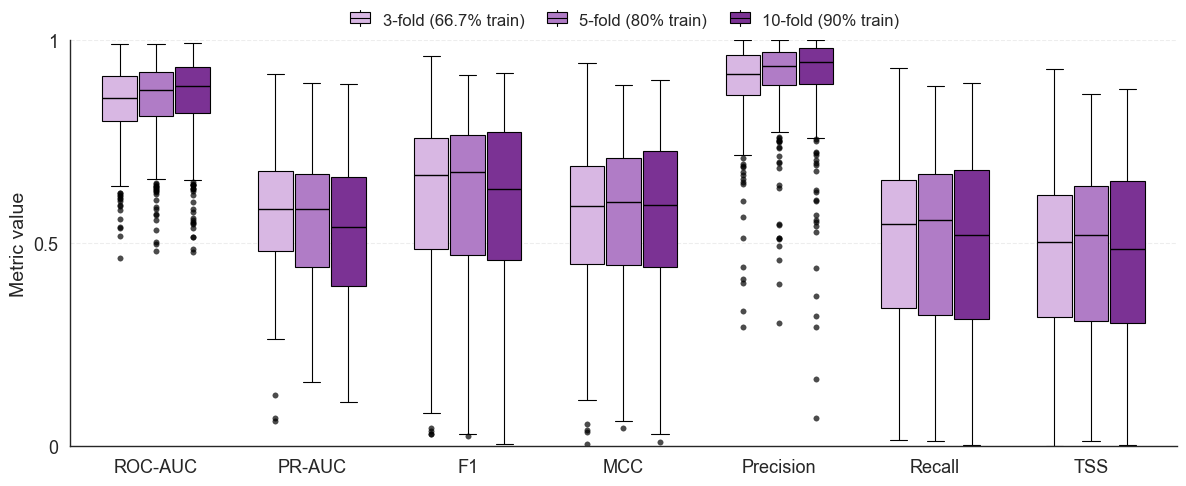

In [5]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


sns.set_context("paper", font_scale=1.15)
sns.set_style("white")


# ============================================================
# Locate repository root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    for path in [start, *start.parents]:
        if (path / "src/matlab").exists() and (path / "docs").exists():
            return path

    raise RuntimeError(
        f"Could not locate repository root from: {start}"
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Input configuration
# ============================================================
RESULT_DIR = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_kfold_20x290_"
        "cvK3-5-10_thresh0p50_randomeligible_"
        "roleormass_tau1p00_Apocrita"
    )
)

RETENTION_DIR = (
    RESULT_DIR
    / "retention_protocol"
    / "tukey_iqr_1p5_min50pct_threshold0p50_v1"
)

INPUT_PATH = (
    RETENTION_DIR
    / "figure_inputs"
    / "predictive_train10-90_after_tukey.csv"
)

MANIFEST_PATH = RETENTION_DIR / "retention_manifest.json"

OUT_DIR = RETENTION_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PATH = (
    OUT_DIR
    / (
        "predictive_metrics_wlnm_dir_neg_kfold_"
        "roleormass_tau1p00_threshold0p5_"
        "tukey_web_level.png"
    )
)

# ============================================================
# Experimental configuration
# ============================================================
THRESHOLD_TARGET = 0.5
K_TARGET = 10

cvk_order = [3, 5, 10]

SHOW_WEB_LEVEL_FLIERS = True

METRICS = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

plot_metrics = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]


# ============================================================
# Helpers
# ============================================================
def cvk_label(k: int) -> str:
    train_ratio_map = {
        3: "66.7%",
        5: "80%",
        10: "90%",
    }

    if k in train_ratio_map:
        return f"{k}-fold ({train_ratio_map[k]} train)"

    return f"{k}-fold"


def validate_retention_manifest(manifest_path: Path) -> dict:
    if not manifest_path.is_file():
        raise FileNotFoundError(
            "Retention manifest not found:\n"
            f"  {manifest_path}"
        )

    with manifest_path.open("r", encoding="utf-8") as handle:
        manifest = json.load(handle)

    source_metadata = manifest.get("source_manifest", {})

    expected_metadata = {
        "Version": "WLNM_dir_neg_kfold",
        "Eligibility": "role_or_mass",
        "MassEligibilityEnabled": "true",
        "TauMass": "1.00",
        "NegativeSampling": "random_eligible_pool",
        "PrioritySampling": "false",
        "ClassificationThreshold": "0.50",
        "NumExperimentsPerFold": "20",
        "TargetNegativePositiveRatio": "2",
        "FoldConnectivityConstraint": "not_applicable",
    }

    mismatches = []

    for key, expected_value in expected_metadata.items():
        actual_value = source_metadata.get(key)

        if (
            str(actual_value).strip().lower()
            != str(expected_value).strip().lower()
        ):
            mismatches.append(
                f"{key}: expected {expected_value!r}, "
                f"found {actual_value!r}"
            )

    if mismatches:
        raise ValueError(
            "The retention manifest does not match the expected "
            "role-or-mass k-fold configuration:\n  "
            + "\n  ".join(mismatches)
        )

    print("[INFO] Retention manifest validated.")
    print("[INFO] Configuration: role-or-mass eligibility.")
    print("[INFO] Mass-ratio threshold: 1.0.")
    print("[INFO] Classification threshold: 0.5.")
    print("[INFO] Repeated CV experiments per K: 20.")
    print("[INFO] Tukey filtering: 1.5×IQR per food web, K and metric.")

    return manifest


def load_tukey_web_level_metrics(input_path: Path):
    required_columns = {
        "Foodweb",
        "Version",
        "TrainRatio",
        "Threshold",
        "K",
        "CvK",
        "Metric",
        "MetricLabel",
        "MetricFamily",
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "ExpectedRuns",
        "MinimumRetainedRuns",
        "MeetsMinimumRetainedRuns",
    }

    if not input_path.is_file():
        raise FileNotFoundError(
            "Tukey-filtered figure input not found:\n"
            f"  {input_path}"
        )

    print(f"[INFO] Using Tukey-filtered input:\n  {input_path}")

    df = pd.read_csv(input_path)

    missing_columns = sorted(required_columns.difference(df.columns))

    if missing_columns:
        raise ValueError(
            "The Tukey input is missing required columns:\n  "
            + "\n  ".join(missing_columns)
        )

    numeric_columns = [
        "TrainRatio",
        "Threshold",
        "K",
        "CvK",
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "ExpectedRuns",
        "MinimumRetainedRuns",
        "MeetsMinimumRetainedRuns",
    ]

    for column in numeric_columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce",
        )

    # Keep only the intended predictive metrics.
    df = df.loc[
        df["MetricFamily"].astype(str).eq("predictive")
        & df["Metric"].isin(METRICS)
    ].copy()

    # Keep only the fixed classification threshold of 0.5.
    df = df.loc[
        np.isclose(
            df["Threshold"],
            THRESHOLD_TARGET,
            atol=1e-9,
            equal_nan=False,
        )
    ].copy()

    # Keep the expected WLNM subgraph parameter.
    if K_TARGET is not None:
        df = df.loc[df["K"].eq(K_TARGET)].copy()

    # Keep 3-, 5- and 10-fold results.
    df = df.loc[df["CvK"].isin(cvk_order)].copy()

    # Keep only food-web/metric groups satisfying MinRetainedRuns.
    df = df.loc[
        df["MeetsMinimumRetainedRuns"].eq(1)
        & df["MeanAfterTukey"].notna()
    ].copy()

    if df.empty:
        raise ValueError(
            "No Tukey-filtered observations remained after applying "
            "the required configuration."
        )

    df["CvK"] = df["CvK"].astype(int)

    duplicate_mask = df.duplicated(
        subset=["Foodweb", "CvK", "Metric"],
        keep=False,
    )

    if duplicate_mask.any():
        duplicate_rows = (
            df.loc[
                duplicate_mask,
                ["Foodweb", "CvK", "Metric"],
            ]
            .sort_values(["Foodweb", "CvK", "Metric"])
        )

        raise ValueError(
            "Duplicate food-web/CvK/metric rows were found:\n"
            f"{duplicate_rows.head(20).to_string(index=False)}"
        )

    # Validate expected coverage.
    coverage = (
        df.groupby(["CvK", "Metric"])["Foodweb"]
        .nunique()
        .unstack("Metric")
        .reindex(index=cvk_order, columns=METRICS)
    )

    print("\n[INFO] Retained food webs per CvK and metric:")
    display(coverage)

    incomplete_coverage = coverage.ne(290) | coverage.isna()

    if incomplete_coverage.any().any():
        failed = []

        for cvk in cvk_order:
            for metric in METRICS:
                observed = coverage.loc[cvk, metric]

                if pd.isna(observed) or int(observed) != 290:
                    failed.append(
                        f"CvK={cvk}, metric={metric}: "
                        f"{observed} food webs"
                    )

        raise ValueError(
            "Expected 290 retained food webs for every predictive "
            "metric and CvK:\n  "
            + "\n  ".join(failed)
        )

    # Each row currently represents one Tukey-filtered food-web mean
    # for one metric and one CvK.
    metric_values = (
        df.pivot(
            index=["Foodweb", "CvK"],
            columns="Metric",
            values="MeanAfterTukey",
        )
        .reset_index()
    )

    metric_values.columns.name = None

    # Keep experimental metadata and metric-specific retention counts.
    metadata = (
        df.groupby(
            ["Foodweb", "CvK"],
            as_index=False,
        )
        .agg(
            TrainRatio=("TrainRatio", "median"),
            K=("K", "median"),
            Threshold=("Threshold", "median"),
            MinRetainedRuns=(
                "RetainedRunsAfterTukey",
                "min",
            ),
            MedianRetainedRuns=(
                "RetainedRunsAfterTukey",
                "median",
            ),
            MaxRetainedRuns=(
                "RetainedRunsAfterTukey",
                "max",
            ),
        )
    )

    df_web = metadata.merge(
        metric_values,
        on=["Foodweb", "CvK"],
        how="inner",
        validate="one_to_one",
    )

    cvk_to_label = {
        k: cvk_label(k)
        for k in cvk_order
    }

    df_web["CvK_label"] = df_web["CvK"].map(cvk_to_label)

    missing_metric_values = df_web[METRICS].isna().sum()

    if missing_metric_values.any():
        raise ValueError(
            "Missing metric values after converting the Tukey input "
            "to web-level format:\n"
            f"{missing_metric_values[missing_metric_values > 0]}"
        )

    return df, df_web


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans,
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [
            box,
            median,
            whisker_top,
            whisker_bottom,
        ]


def plot_kfold_web_level_metrics(df_web: pd.DataFrame) -> None:
    if df_web.empty:
        print("No data to plot.")
        return

    present_cvks = [
        k
        for k in cvk_order
        if (df_web["CvK"] == k).any()
    ]

    if len(present_cvks) < 2:
        print("Not enough CV regimes present to plot.")
        return

    cvk_palette = {
        3: "#D8B7E3",
        5: "#B07CC6",
        10: "#7B3294",
    }

    label_map = {
        k: cvk_label(k)
        for k in present_cvks
    }

    fig, ax = plt.subplots(figsize=(12, 5))

    group_gap = 1.45
    group_centers = (
        1.0
        + np.arange(len(plot_metrics)) * group_gap
    )

    offsets = np.linspace(
        -0.34,
        0.34,
        len(present_cvks),
    )

    box_width = 0.32

    for j, cvk in enumerate(present_cvks):
        data_for_cvk = []
        positions_for_cvk = []

        for i, (metric, _) in enumerate(plot_metrics):
            values = (
                df_web.loc[
                    df_web["CvK"] == cvk,
                    metric,
                ]
                .dropna()
                .values
            )

            if len(values) == 0:
                continue

            data_for_cvk.append(values)
            positions_for_cvk.append(
                group_centers[i] + offsets[j]
            )

        if not data_for_cvk:
            continue

        boxplot = ax.boxplot(
            data_for_cvk,
            positions=positions_for_cvk,
            widths=box_width,
            patch_artist=True,
            manage_ticks=False,
            showfliers=SHOW_WEB_LEVEL_FLIERS,
            boxprops=dict(
                edgecolor="black",
                linewidth=0.8,
            ),
            medianprops=dict(
                color="black",
                linewidth=1.0,
            ),
            whiskerprops=dict(
                color="black",
                linewidth=0.8,
            ),
            capprops=dict(
                color="black",
                linewidth=0.8,
            ),
            flierprops=dict(
                marker="o",
                markersize=4,
                markerfacecolor="black",
                markeredgecolor="black",
                markeredgewidth=0.2,
                alpha=0.7,
            ),
        )

        for box in boxplot["boxes"]:
            box.set_facecolor(cvk_palette[cvk])

    legend_handles = [
        {
            "facecolor": cvk_palette[k],
            "edgecolor": "black",
            "linewidth": 0.8,
        }
        for k in present_cvks
    ]

    ax.set_xlim(
        group_centers[0] - 0.8,
        group_centers[-1] + 0.8,
    )

    ax.set_ylim(0, 1.0)

    ax.set_xticks(group_centers)
    ax.set_xticklabels(
        [label for _, label in plot_metrics],
        ha="center",
        fontsize=13,
    )

    ax.set_ylabel(
        "Metric value",
        fontsize=14,
    )

    ax.set_xlabel("")

    ax.tick_params(
        axis="y",
        labelsize=13,
    )

    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1"])

    ax.grid(
        True,
        axis="y",
        linestyle="--",
        alpha=0.35,
    )

    sns.despine(ax=ax)

    ax.legend(
        handles=legend_handles,
        labels=[
            label_map[k]
            for k in present_cvks
        ],
        handler_map={
            dict: HandlerMiniBoxplot()
        },
        loc="lower center",
        bbox_to_anchor=(0.5, 1),
        ncol=len(present_cvks),
        frameon=False,
        fontsize=12,
        handlelength=1.5,
        handleheight=0.9,
        handletextpad=0.6,
        borderpad=0.2,
        labelspacing=0.45,
        columnspacing=1.2,
    )

    plt.tight_layout()

    fig.savefig(
        OUT_PATH,
        dpi=300,
        bbox_inches="tight",
    )

    print(f"[INFO] Saved figure: {OUT_PATH}")

    plt.show()


# ============================================================
# Run
# ============================================================
manifest = validate_retention_manifest(MANIFEST_PATH)

df_retained, df_web = load_tukey_web_level_metrics(
    INPUT_PATH
)

print("\n[INFO] Tukey-filtered metric-level shape:")
print(df_retained.shape)

print("\n[INFO] Web-level shape:")
print(df_web.shape)

print("\n[INFO] Food-web count per CvK:")
print(
    df_web.groupby("CvK")["Foodweb"]
    .nunique()
)

retention_summary = (
    df_retained
    .groupby("CvK")
    .agg(
        FoodWebs=("Foodweb", "nunique"),
        Metrics=("Metric", "nunique"),
        TrainRatio=("TrainRatio", "median"),
        Threshold=("Threshold", "median"),
        MinimumRetained=(
            "RetainedRunsAfterTukey",
            "min",
        ),
        MedianRetained=(
            "RetainedRunsAfterTukey",
            "median",
        ),
        MaximumRetained=(
            "RetainedRunsAfterTukey",
            "max",
        ),
    )
    .reset_index()
)

print("\n[INFO] Tukey retention summary:")
display(retention_summary)

summary_rows = []

for cvk in cvk_order:
    for metric, metric_label in plot_metrics:
        values = (
            df_web.loc[
                df_web["CvK"] == cvk,
                metric,
            ]
            .dropna()
        )

        if values.empty:
            continue

        summary_rows.append(
            {
                "CvK": cvk,
                "Label": cvk_label(cvk),
                "Metric": metric_label,
                "N food webs": int(values.shape[0]),
                "Mean": values.mean(),
                "Median": values.median(),
                "SD": values.std(ddof=1),
                "Variance": values.var(ddof=1),
            }
        )

summary_table = pd.DataFrame(summary_rows)

for column in [
    "Mean",
    "Median",
    "SD",
    "Variance",
]:
    summary_table[column] = (
        summary_table[column]
        .round(4)
    )

print(
    "\n=== Web-level k-fold predictive metric summary "
    "after Tukey filtering at threshold 0.5 ==="
)

display(summary_table)

plot_kfold_web_level_metrics(df_web)

[INFO] Filtered food webs by size: kept 290 / 290 (>= 0 nodes).

[INFO] Retained metric-food-web observations:
Total rows: 2,030
Rows per ecosystem:
EcosystemType
lakes                      385
marine                     938
streams                    196
terrestrial aboveground    147
terrestrial belowground    364
dtype: int64

[INFO] Web-level observations after Tukey filtering:
Total web-level rows: 290


,EcosystemType,FoodWebs,MinRunsAveraged,MedianRunsAveraged,MaxRunsAveraged
0,lakes,55,38,44.0,50
1,marine,134,38,47.0,50
2,streams,28,38,46.0,50
3,terrestrial aboveground,21,42,47.0,50
4,terrestrial belowground,52,43,48.0,50



=== Web-level precision median and variance by ecosystem ===


,EcosystemType,n_foodwebs,Precision_Median,Precision_Variance
0,lakes,55,1.0000,0.010588
1,marine,134,0.9412,0.011941
2,streams,28,0.9547,0.066328
3,terrestrial aboveground,21,0.8694,0.001765
4,terrestrial belowground,52,0.9868,0.000425



=== Ecosystems with lowest/highest median precision and variance ===
Lowest median precision:  terrestrial aboveground (median = 0.8694, variance = 0.001765, n_foodwebs = 21)
Highest median precision: lakes (median = 1.0, variance = 0.010588, n_foodwebs = 55)
Lowest variance:          terrestrial belowground (variance = 0.000425, median = 0.9868, n_foodwebs = 52)
Highest variance:         streams (variance = 0.066328, median = 0.9547, n_foodwebs = 28)
[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_randomeligible_roleormass_tau1p00_checkconnfalse_adaptivefalse_Apocrita/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figures/predictive_metrics_wlnm_dir_neg_train90_by_ecosystem_tau1p00_checkconnfalse_adaptivefalse_threshold0p50_tukey_filtered.png
[INFO] Configuration: tau_mass=1.00, check_connectivity=False, adaptive_connectivity=False, classification_threshold=0.50, train_ratio=90.


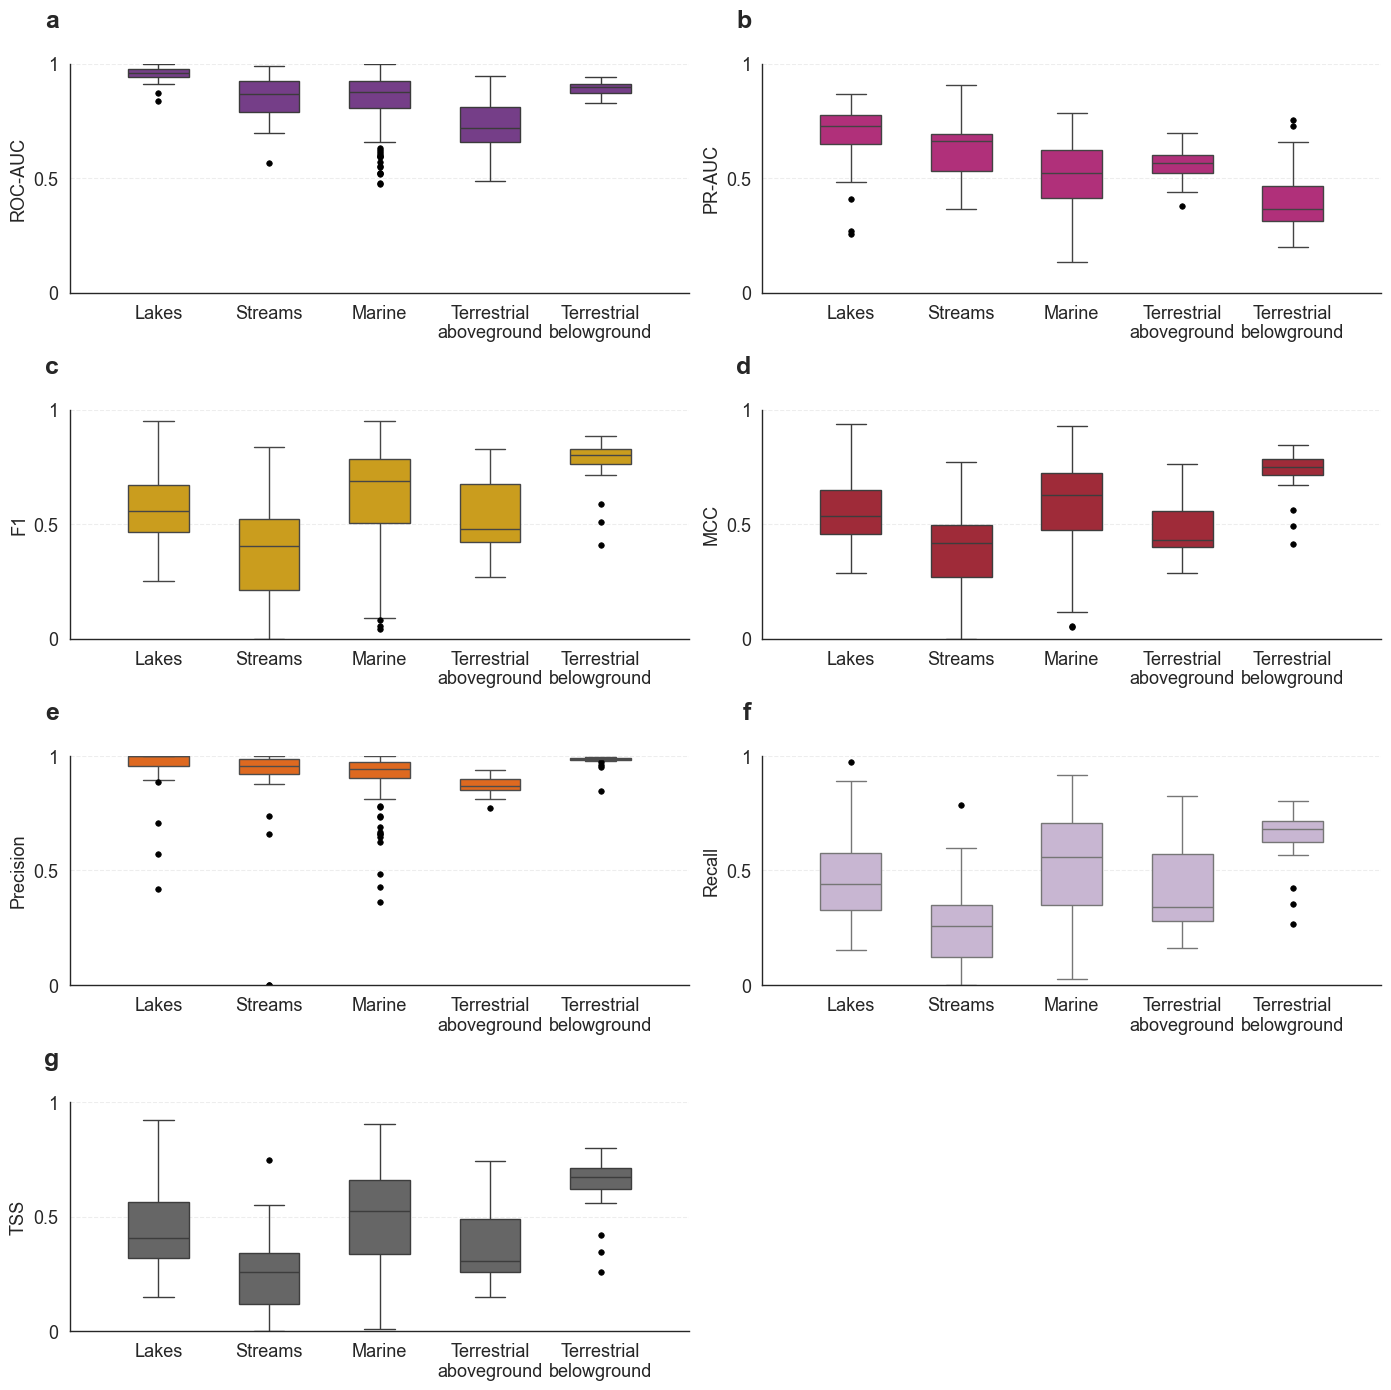

In [10]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display


sns.set_context("paper")
sns.set_style("white")


# ============================================================
# Locate repo root
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    for path in [start, *start.parents]:
        if (
            (path / "src/matlab").exists()
            and (path / "docs").exists()
        ):
            return path

    raise RuntimeError(
        f"Could not locate repo root from {start}"
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Final configuration
# ============================================================

TAU_MASS = 1.00
CHECK_CONNECTIVITY = False
ADAPTIVE_CONNECTIVITY = False
CLASSIFICATION_THRESHOLD = 0.50

MIN_NODES = 0
TRAIN_RATIO_TARGET = 90

SHOW_WEB_LEVEL_FLIERS = True

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min50pct_threshold0p50_v1"
)


# ============================================================
# Updated input data
# ============================================================

RESULT_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_50x290_train10-90_"
        "thresh10-90_randomeligible_roleormass_"
        "tau1p00_checkconnfalse_adaptivefalse_Apocrita"
    )
)

RETENTION_ROOT = (
    RESULT_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
)

PREDICTIVE_INPUT = (
    RETENTION_ROOT
    / "figure_inputs"
    / (
        f"predictive_train{TRAIN_RATIO_TARGET}"
        "_after_tukey.csv"
    )
)

ECOSYSTEM_FILE = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)

RUN_MANIFEST = (
    RESULT_ROOT
    / "RUN_MANIFEST.txt"
)

OUT_DIR = (
    RETENTION_ROOT
    / "figures"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUT_PATH = (
    OUT_DIR
    / (
        "predictive_metrics_wlnm_dir_neg_"
        f"train{TRAIN_RATIO_TARGET}_by_ecosystem_"
        "tau1p00_checkconnfalse_adaptivefalse_"
        "threshold0p50_tukey_filtered.png"
    )
)


# ============================================================
# Metrics — original order, labels and colours preserved
# ============================================================

METRIC_ORDER = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

xtick_labels = [
    "ROC-AUC",
    "PR-AUC",
    "F1",
    "MCC",
    "Precision",
    "Recall",
    "TSS",
]

metric_palette = {
    "ROC_AUC": "#7B3294",
    "PR_AUC": "#C51B7D",
    "Precision": "#FE6100",
    "Recall": "#CAB2D6",
    "F1Score": "#E6AB02",
    "TestMCC": "#B2182B",
    "TestTSS": "#666666",
    "TestTPR": "#1B9E77",
}

metric_label_map = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
    "TestTPR": "TPR",
}


# ============================================================
# Validate inputs
# ============================================================

required_files = {
    "Tukey-filtered predictive input": PREDICTIVE_INPUT,
    "Ecosystem metadata": ECOSYSTEM_FILE,
    "Run manifest": RUN_MANIFEST,
}

missing_files = [
    f"{label}:\n  {path}"
    for label, path in required_files.items()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "The following required inputs are missing:\n\n"
        + "\n\n".join(missing_files)
    )


def read_manifest(path):
    manifest = {}

    with path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        for line in handle:
            line = line.strip()

            if not line or "=" not in line:
                continue

            key, value = line.split("=", 1)
            manifest[key.strip()] = value.strip()

    return manifest


manifest = read_manifest(
    RUN_MANIFEST
)

expected_manifest = {
    "Version": "WLNM_dir_neg",
    "TauMass": "1.00",
    "CheckConnectivity": "false",
    "AdaptiveConnectivity": "false",
    "NegativeSampling": "random_eligible_pool",
    "Eligibility": "role_or_mass",
    "PrioritySampling": "false",
}

configuration_errors = []

for key, expected_value in expected_manifest.items():
    observed_value = manifest.get(key)

    if observed_value is None:
        configuration_errors.append(
            f"{key}: missing"
        )
    elif (
        observed_value.casefold()
        != expected_value.casefold()
    ):
        configuration_errors.append(
            f"{key}: expected {expected_value}, "
            f"found {observed_value}"
        )

if configuration_errors:
    raise ValueError(
        "The selected result root does not match the "
        "requested configuration:\n\n"
        + "\n".join(configuration_errors)
    )


# ============================================================
# Normalisation helpers
# ============================================================

def normalize_colname(value):
    return (
        str(value)
        .strip()
        .lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb(value):
    value = Path(
        str(value).strip()
    ).name

    for extension in (
        ".mat",
        ".csv",
    ):
        if value.lower().endswith(
            extension
        ):
            value = value[
                :-len(extension)
            ].rstrip()

    for suffix in (
        "_tax_mass",
        "_taxmass",
    ):
        if value.lower().endswith(
            suffix
        ):
            value = value[
                :-len(suffix)
            ].rstrip()

    return " ".join(
        value.casefold().split()
    )


# ============================================================
# Load ecosystem metadata
# ============================================================

df_ecosystem = pd.read_csv(
    ECOSYSTEM_FILE
)

node_candidates = {
    "nnodes",
    "numnodes",
    "nodes",
    "nodecount",
    "n",
    "s",
}

norm_map = {
    normalize_colname(column): column
    for column in df_ecosystem.columns
}

node_col = next(
    (
        norm_map[candidate]
        for candidate in node_candidates
        if candidate in norm_map
    ),
    None,
)

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in "
        "ecosystem metadata."
    )

if (
    "Foodweb" not in df_ecosystem.columns
    or "EcosystemType" not in df_ecosystem.columns
):
    raise RuntimeError(
        "The ecosystem metadata must contain Foodweb "
        "and EcosystemType."
    )

df_ecosystem[node_col] = pd.to_numeric(
    df_ecosystem[node_col],
    errors="coerce",
)

df_ecosystem["FW_KEY"] = (
    df_ecosystem["Foodweb"]
    .apply(normalize_foodweb)
)

metadata_for_merge = (
    df_ecosystem[
        [
            "FW_KEY",
            "EcosystemType",
            node_col,
        ]
    ]
    .drop_duplicates(
        subset=["FW_KEY"],
        keep="first",
    )
)


# ============================================================
# Load new Tukey-filtered predictive data
# ============================================================

predictive = pd.read_csv(
    PREDICTIVE_INPUT
)

required_columns = {
    "Foodweb",
    "TrainRatio",
    "Threshold",
    "Metric",
    "MetricFamily",
    "MeanAfterTukey",
    "RetainedRunsAfterTukey",
    "OutlierRunsExcluded",
    "MeetsMinimumRetainedRuns",
}

missing_columns = sorted(
    required_columns.difference(
        predictive.columns
    )
)

if missing_columns:
    raise ValueError(
        "The predictive Tukey input is missing columns:\n  "
        + "\n  ".join(missing_columns)
    )

numeric_columns = [
    "TrainRatio",
    "Threshold",
    "MeanAfterTukey",
    "RetainedRunsAfterTukey",
    "OutlierRunsExcluded",
    "MeetsMinimumRetainedRuns",
]

for column in numeric_columns:
    predictive[column] = pd.to_numeric(
        predictive[column],
        errors="coerce",
    )


# ============================================================
# Select requested configuration
# ============================================================

predictive = predictive.loc[
    predictive["MetricFamily"]
    .astype(str)
    .str.casefold()
    .eq("predictive")
    & predictive["Metric"].isin(
        METRIC_ORDER
    )
    & np.isclose(
        predictive["TrainRatio"],
        TRAIN_RATIO_TARGET,
        equal_nan=False,
    )
    & np.isclose(
        predictive["Threshold"],
        CLASSIFICATION_THRESHOLD,
        equal_nan=False,
    )
    & predictive[
        "MeetsMinimumRetainedRuns"
    ].eq(1)
    & predictive[
        "MeanAfterTukey"
    ].notna()
].copy()

if predictive.empty:
    raise RuntimeError(
        "No retained predictive results were found for "
        f"TrainRatio={TRAIN_RATIO_TARGET} and "
        f"Threshold={CLASSIFICATION_THRESHOLD:.2f}."
    )

predictive["FW_KEY"] = (
    predictive["Foodweb"]
    .apply(normalize_foodweb)
)

duplicated_rows = predictive.duplicated(
    subset=[
        "FW_KEY",
        "Metric",
    ],
    keep=False,
)

if duplicated_rows.any():
    raise ValueError(
        "More than one retained row was found per "
        "food web and metric."
    )


# ============================================================
# Merge with ecosystem metadata
# ============================================================

predictive = predictive.merge(
    metadata_for_merge,
    on="FW_KEY",
    how="left",
    validate="many_to_one",
)

missing_ecosystem = (
    predictive["EcosystemType"].isna()
)

if missing_ecosystem.any():
    missing_foodwebs = sorted(
        predictive.loc[
            missing_ecosystem,
            "Foodweb",
        ]
        .astype(str)
        .unique()
    )

    raise ValueError(
        "Ecosystem metadata could not be matched for "
        f"{len(missing_foodwebs)} food webs:\n  "
        + "\n  ".join(
            missing_foodwebs[:30]
        )
    )


# ============================================================
# Apply node-count filter
# ============================================================

before_n = (
    predictive["FW_KEY"]
    .nunique()
)

predictive = predictive.loc[
    predictive[node_col]
    .ge(MIN_NODES)
].copy()

after_n = (
    predictive["FW_KEY"]
    .nunique()
)

print(
    f"[INFO] Filtered food webs by size: "
    f"kept {after_n} / {before_n} "
    f"(>= {MIN_NODES} nodes)."
)

if predictive.empty:
    raise ValueError(
        f"No food webs left after filtering "
        f"Nodes >= {MIN_NODES}."
    )

print(
    "\n[INFO] Retained metric-food-web observations:"
)

print(
    f"Total rows: {len(predictive):,}"
)

print(
    "Rows per ecosystem:"
)

print(
    predictive
    .groupby("EcosystemType")
    .size()
)


# ============================================================
# Adapt new input to original web-level structure
# ============================================================

metric_values = (
    predictive
    .pivot(
        index=[
            "Foodweb",
            "FW_KEY",
            "EcosystemType",
            node_col,
        ],
        columns="Metric",
        values="MeanAfterTukey",
    )
    .reset_index()
)

metric_values.columns.name = None

retention_by_web = (
    predictive
    .groupby(
        [
            "Foodweb",
            "FW_KEY",
        ],
        as_index=False,
    )
    .agg(
        RunsAveraged=(
            "RetainedRunsAfterTukey",
            "min",
        ),
        MaximumRunsAveraged=(
            "RetainedRunsAfterTukey",
            "max",
        ),
        TotalOutlierRunsExcluded=(
            "OutlierRunsExcluded",
            "sum",
        ),
    )
)

df_web = metric_values.merge(
    retention_by_web,
    on=[
        "Foodweb",
        "FW_KEY",
    ],
    how="left",
    validate="one_to_one",
)

print(
    "\n[INFO] Web-level observations after "
    "Tukey filtering:"
)

print(
    f"Total web-level rows: "
    f"{len(df_web):,}"
)

display(
    df_web
    .groupby("EcosystemType")
    .agg(
        FoodWebs=(
            "Foodweb",
            "nunique",
        ),
        MinRunsAveraged=(
            "RunsAveraged",
            "min",
        ),
        MedianRunsAveraged=(
            "RunsAveraged",
            "median",
        ),
        MaxRunsAveraged=(
            "MaximumRunsAveraged",
            "max",
        ),
    )
    .reset_index()
)


# ============================================================
# Precision summary by ecosystem, web-level
# ============================================================

precision_summary = (
    df_web
    .dropna(
        subset=[
            "EcosystemType",
            "Precision",
        ]
    )
    .groupby(
        "EcosystemType",
        as_index=False,
    )
    .agg(
        n_foodwebs=(
            "Foodweb",
            "nunique",
        ),
        Precision_Median=(
            "Precision",
            "median",
        ),
        Precision_Variance=(
            "Precision",
            lambda values: values.var(
                ddof=1
            ),
        ),
    )
)

precision_summary[
    "Precision_Median"
] = precision_summary[
    "Precision_Median"
].round(4)

precision_summary[
    "Precision_Variance"
] = precision_summary[
    "Precision_Variance"
].round(6)

print(
    "\n=== Web-level precision median and "
    "variance by ecosystem ==="
)

display(
    precision_summary
)

lowest_precision = precision_summary.loc[
    precision_summary[
        "Precision_Median"
    ].idxmin()
]

highest_precision = precision_summary.loc[
    precision_summary[
        "Precision_Median"
    ].idxmax()
]

lowest_variance = precision_summary.loc[
    precision_summary[
        "Precision_Variance"
    ].idxmin()
]

highest_variance = precision_summary.loc[
    precision_summary[
        "Precision_Variance"
    ].idxmax()
]

print(
    "\n=== Ecosystems with lowest/highest "
    "median precision and variance ==="
)

print(
    f"Lowest median precision:  "
    f"{lowest_precision['EcosystemType']} "
    f"(median = "
    f"{lowest_precision['Precision_Median']}, "
    f"variance = "
    f"{lowest_precision['Precision_Variance']}, "
    f"n_foodwebs = "
    f"{lowest_precision['n_foodwebs']})"
)

print(
    f"Highest median precision: "
    f"{highest_precision['EcosystemType']} "
    f"(median = "
    f"{highest_precision['Precision_Median']}, "
    f"variance = "
    f"{highest_precision['Precision_Variance']}, "
    f"n_foodwebs = "
    f"{highest_precision['n_foodwebs']})"
)

print(
    f"Lowest variance:          "
    f"{lowest_variance['EcosystemType']} "
    f"(variance = "
    f"{lowest_variance['Precision_Variance']}, "
    f"median = "
    f"{lowest_variance['Precision_Median']}, "
    f"n_foodwebs = "
    f"{lowest_variance['n_foodwebs']})"
)

print(
    f"Highest variance:         "
    f"{highest_variance['EcosystemType']} "
    f"(variance = "
    f"{highest_variance['Precision_Variance']}, "
    f"median = "
    f"{highest_variance['Precision_Median']}, "
    f"n_foodwebs = "
    f"{highest_variance['n_foodwebs']})"
)


# ============================================================
# Prepare long-format web-level data
# ============================================================

df_plot = df_web.melt(
    id_vars=[
        "Foodweb",
        "EcosystemType",
        "RunsAveraged",
    ],
    value_vars=METRIC_ORDER,
    var_name="Metric",
    value_name="Value",
)


# ============================================================
# Preferred ecosystem order — preserved
# ============================================================

preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystems_present = (
    df_web["EcosystemType"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

eco_lookup = {
    ecosystem.lower(): ecosystem
    for ecosystem in ecosystems_present
}

ecosystem_order = [
    eco_lookup[ecosystem]
    for ecosystem
    in preferred_ecosystem_order
    if ecosystem in eco_lookup
]

ecosystem_order += [
    ecosystem
    for ecosystem
    in ecosystems_present
    if ecosystem.lower()
    not in set(
        preferred_ecosystem_order
    )
]


# ============================================================
# Labels — preserved
# ============================================================

labels_map = (
    df_web[
        [
            "Foodweb",
            "EcosystemType",
        ]
    ]
    .drop_duplicates()
    .groupby("EcosystemType")[
        "Foodweb"
    ]
    .nunique()
    .to_dict()
)


def format_ecosystem_label(
    ecosystem,
    number_foodwebs,
):
    ecosystem_clean = str(
        ecosystem
    ).strip()

    ecosystem_lower = (
        ecosystem_clean.lower()
    )

    label_replacements = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": (
            "Terrestrial\naboveground"
        ),
        "terrestrial belowground": (
            "Terrestrial\nbelowground"
        ),
    }

    return label_replacements.get(
        ecosystem_lower,
        ecosystem_clean.capitalize(),
    )


labels_map = {
    ecosystem: format_ecosystem_label(
        ecosystem,
        number_foodwebs,
    )
    for ecosystem, number_foodwebs
    in labels_map.items()
}

subset = df_plot.copy()

subset["Metric"] = pd.Categorical(
    subset["Metric"],
    categories=METRIC_ORDER,
    ordered=True,
)


# ============================================================
# Plot — styling preserved
# ============================================================

n_panels = len(
    METRIC_ORDER
)

n_cols = 2

n_rows = math.ceil(
    n_panels / n_cols
)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 14),
    sharey=False,
)

axes = np.array(
    axes
).reshape(-1)

panel_letters = list(
    "abcdefghijklmnopqrstuvwxyz"
)

for index, metric in enumerate(
    METRIC_ORDER
):
    ax = axes[index]

    sub = subset[
        subset["Metric"]
        == metric
    ].copy()

    if sub.empty:
        ax.set_axis_off()
        continue

    sns.boxplot(
        data=sub,
        x="EcosystemType",
        y="Value",
        order=ecosystem_order,
        color=metric_palette.get(
            metric,
            "#7B3294",
        ),
        width=0.55,
        showfliers=(
            SHOW_WEB_LEVEL_FLIERS
        ),
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
        ax=ax,
    )

    legend = ax.get_legend()

    if legend is not None:
        legend.remove()

    ax.set_xlabel("")

    ax.set_xticks(
        range(
            len(ecosystem_order)
        )
    )

    ax.set_xticklabels(
        [
            labels_map.get(
                ecosystem,
                ecosystem,
            )
            for ecosystem
            in ecosystem_order
        ],
        rotation=0,
        ha="center",
        fontsize=13,
        linespacing=1.1,
    )

    ax.set_ylabel(
        metric_label_map.get(
            metric,
            metric,
        ),
        fontsize=13,
    )

    ax.tick_params(
        axis="y",
        labelsize=13,
    )

    ax.set_yticks([
        0,
        0.5,
        1.0,
    ])

    ax.set_yticklabels([
        "0",
        "0.5",
        "1",
    ])

    ax.grid(
        True,
        axis="y",
        linestyle="--",
        alpha=0.35,
    )

    ax.set_xlim(
        -0.8,
        len(ecosystem_order)
        - 1
        + 0.8,
    )

    ax.set_ylim(
        0,
        1.0,
    )

    ax.grid(
        False,
        axis="x",
    )

    sns.despine(
        ax=ax
    )

    ax.annotate(
        panel_letters[index],
        xy=(0, 1.1),
        xycoords="axes fraction",
        xytext=(-8, 6),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

for panel_index in range(
    n_panels,
    len(axes),
):
    axes[
        panel_index
    ].set_axis_off()

fig.tight_layout(
    rect=[
        0,
        0,
        1,
        1,
    ],
    w_pad=1,
    h_pad=1,
)

fig.savefig(
    OUT_PATH,
    dpi=300,
    bbox_inches="tight",
)

print(
    f"[INFO] Saved figure: "
    f"{OUT_PATH}"
)

print(
    "[INFO] Configuration: "
    "tau_mass=1.00, "
    "check_connectivity=False, "
    "adaptive_connectivity=False, "
    "classification_threshold=0.50, "
    f"train_ratio={TRAIN_RATIO_TARGET}."
)

plt.show()

Filtered data: TrainRatio = 90.0, Threshold = 0.50, Nodes >= 0. Rows kept: 290 / 290. Food webs kept: 290 / 290.
[INFO] Using Tukey-filtered food-web means.
[INFO] Configuration: tau_mass=1.00, check_connectivity=False, adaptive_connectivity=False, classification_threshold=0.50, train_ratio=90.

=== OLS linear regression: metric ~ number of nodes ===
a) ROC-AUC: y = 0.903689 - 0.000627x; F1,288 = 38.4906; R² = 0.1179; P < 0.0001; n = 290
b) PR-AUC: y = 0.576392 - 0.000576x; F1,288 = 14.9419; R² = 0.0493; P = 0.0001; n = 290
c) F1: y = 0.630837 - 0.000231x; F1,288 = 1.3287; R² = 0.0046; P = 0.2500; n = 290
d) MCC: y = 0.594726 - 0.000158x; F1,288 = 0.7976; R² = 0.0028; P = 0.3726; n = 290
e) Precision: y = 0.909014 + 0.000271x; F1,288 = 5.4156; R² = 0.0185; P = 0.0207; n = 290
f) Recall: y = 0.535035 - 0.000480x; F1,288 = 5.1553; R² = 0.0176; P = 0.0239; n = 290
g) TSS: y = 0.505017 - 0.000332x; F1,288 = 2.6359; R² = 0.0091; P = 0.1056; n = 290


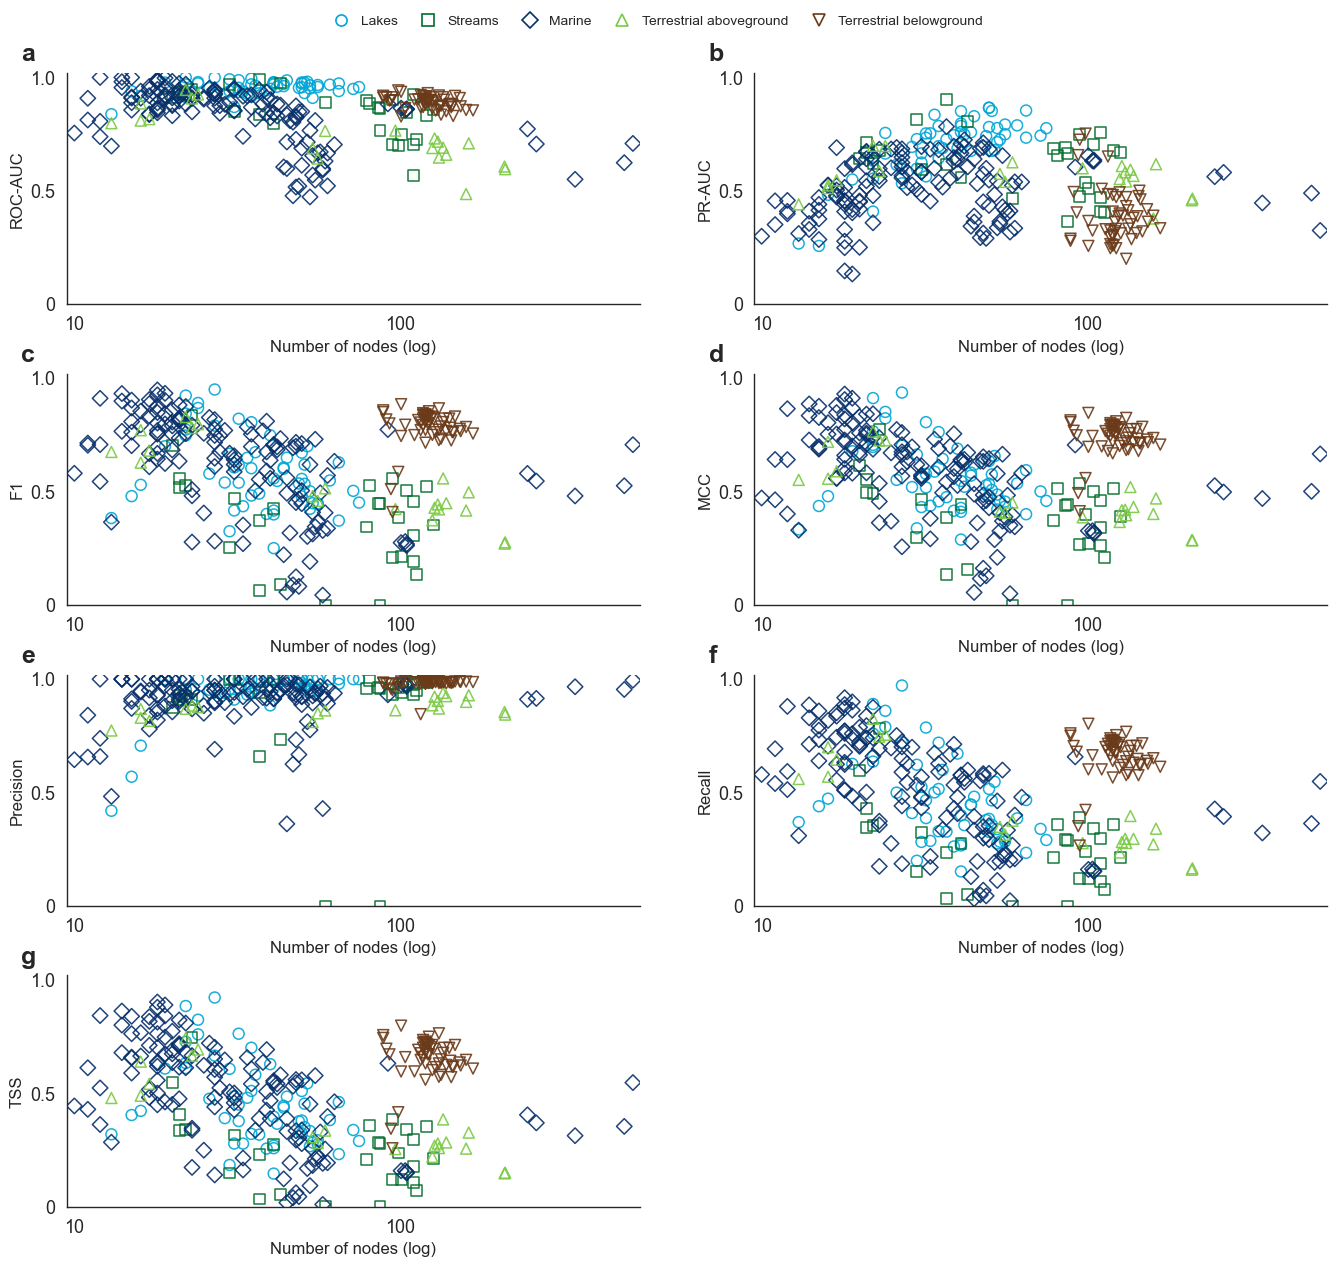

In [2]:
import os
import math
import tempfile

from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(
        Path(tempfile.gettempdir())
        / "qmul_phd_framework_mplconfig"
    ),
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter


sns.set_theme(
    style="white",
    context="paper",
    font_scale=1.2,
)


# ============================================================
# Locate repository root
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    for candidate in [
        start,
        *start.parents,
    ]:
        if (
            (candidate / "src/matlab").is_dir()
            and (candidate / "docs").is_dir()
        ):
            return candidate

    raise RuntimeError(
        f"Could not locate repository root from {start}"
    )


REPO_ROOT = find_repo_root()


# ============================================================
# Final data configuration
# ============================================================

TAU_MASS = 1.00
CHECK_CONNECTIVITY = False
ADAPTIVE_CONNECTIVITY = False
CLASSIFICATION_THRESHOLD = 0.50

TARGET_RATIO = 90.0
MIN_NODES = 0

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min50pct_threshold0p50_v1"
)

RESULT_ROOT = (
    REPO_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_50x290_train10-90_"
        "thresh10-90_randomeligible_roleormass_"
        "tau1p00_checkconnfalse_adaptivefalse_Apocrita"
    )
)

PREDICTIVE_INPUT = (
    RESULT_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figure_inputs"
    / (
        f"predictive_train{int(TARGET_RATIO)}"
        "_after_tukey.csv"
    )
)

ECOSYSTEM_FILE = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)

RUN_MANIFEST = (
    RESULT_ROOT
    / "RUN_MANIFEST.txt"
)


# ============================================================
# Figure configuration — preserved
# ============================================================

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

ecosystem_palette = {
    "Lakes": "#00A6D6",
    "Streams": "#006D2C",
    "Marine": "#08306B",
    "Terrestrial aboveground": "#7AC943",
    "Terrestrial belowground": "#6B3A19",
    "Unknown": "#999999",
}

ecosystem_markers = {
    "Lakes": "o",
    "Streams": "s",
    "Marine": "D",
    "Terrestrial aboveground": "^",
    "Terrestrial belowground": "v",
    "Unknown": "x",
}

ECOSYSTEM_ORDER = [
    "Lakes",
    "Streams",
    "Marine",
    "Terrestrial aboveground",
    "Terrestrial belowground",
]

Y_MIN = 0.0
Y_MAX = 1.0
Y_PAD_TOP = 0.02
X_MAX = 550
N_COLS = 2


# ============================================================
# Helpers
# ============================================================

def normalize_colname(value):
    return (
        str(value)
        .strip()
        .lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb_name(value):
    value = Path(
        str(value).strip()
    ).name

    for extension in (
        ".mat",
        ".csv",
    ):
        if value.lower().endswith(
            extension
        ):
            value = value[
                :-len(extension)
            ].rstrip()

    for suffix in (
        "_tax_mass",
        "_taxmass",
    ):
        if value.lower().endswith(
            suffix
        ):
            value = value[
                :-len(suffix)
            ].rstrip()

    return " ".join(
        value.casefold().split()
    )


def find_column(
    dataframe,
    candidates,
):
    norm_map = {
        normalize_colname(column): column
        for column in dataframe.columns
    }

    for candidate in candidates:
        normalized_candidate = normalize_colname(
            candidate
        )

        if normalized_candidate in norm_map:
            return norm_map[
                normalized_candidate
            ]

    raise KeyError(
        "Could not find any of these columns: "
        f"{candidates}"
    )


def normalize_train_ratio(series):
    values = pd.to_numeric(
        series,
        errors="coerce",
    )

    return np.where(
        values <= 1.0,
        values * 100.0,
        values,
    )


def format_ecosystem_label(name):
    name = str(
        name
    ).strip().lower()

    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": (
            "Terrestrial aboveground"
        ),
        "terrestrial belowground": (
            "Terrestrial belowground"
        ),
        "unknown": "Unknown",
    }

    return label_map.get(
        name,
        str(name).strip().capitalize(),
    )


def format_p_value(p_value):
    if pd.isna(p_value):
        return "P = NA"

    if p_value < 0.0001:
        return "P < 0.0001"

    return f"P = {p_value:.4f}"


def format_equation(
    intercept,
    slope,
):
    sign = (
        "+"
        if slope >= 0
        else "-"
    )

    return (
        f"y = {intercept:.6f} "
        f"{sign} {abs(slope):.6f}x"
    )


# ============================================================
# Regression helper — preserved
# ============================================================

def fit_linear_regression(
    data,
    x_col,
    y_col,
    n_points=100,
):
    """
    Fits an OLS linear regression:

        y_col ~ x_col

    For this figure:
        metric ~ Nodes
    """
    work = (
        data[
            [
                x_col,
                y_col,
            ]
        ]
        .dropna()
        .copy()
    )

    if work.empty:
        return None

    work[x_col] = (
        work[x_col]
        .astype(float)
    )

    work[y_col] = (
        work[y_col]
        .astype(float)
    )

    if (
        len(work) < 3
        or work[x_col].nunique() < 2
    ):
        return None

    x = work[
        [x_col]
    ]

    y = work[
        y_col
    ]

    x_model = sm.add_constant(
        x,
        has_constant="add",
    )

    model = sm.OLS(
        y,
        x_model,
    ).fit()

    intercept = model.params[
        "const"
    ]

    slope = model.params[
        x_col
    ]

    x_line = np.linspace(
        work[x_col].min(),
        work[x_col].max(),
        n_points,
    )

    x_line_model = pd.DataFrame({
        x_col: x_line
    })

    x_line_model = sm.add_constant(
        x_line_model,
        has_constant="add",
    )

    y_line = model.predict(
        x_line_model
    )

    return {
        "x_line": x_line,
        "y_line": y_line,
        "intercept": intercept,
        "slope": slope,
        "f_value": model.fvalue,
        "df_model": int(
            model.df_model
        ),
        "df_resid": int(
            model.df_resid
        ),
        "p_value": model.pvalues[
            x_col
        ],
        "r_squared": model.rsquared,
        "n": len(work),
        "model": model,
    }


# ============================================================
# Validate selected inputs
# ============================================================

required_files = {
    "Tukey-filtered predictive input": (
        PREDICTIVE_INPUT
    ),
    "Ecosystem metadata": (
        ECOSYSTEM_FILE
    ),
    "Run manifest": (
        RUN_MANIFEST
    ),
}

missing_files = [
    f"{label}:\n  {path}"
    for label, path in required_files.items()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "The following required files are missing:\n\n"
        + "\n\n".join(
            missing_files
        )
    )


def read_manifest(path):
    manifest = {}

    with path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        for line in handle:
            line = line.strip()

            if (
                not line
                or "=" not in line
            ):
                continue

            key, value = line.split(
                "=",
                1,
            )

            manifest[
                key.strip()
            ] = value.strip()

    return manifest


manifest = read_manifest(
    RUN_MANIFEST
)

expected_manifest = {
    "Version": "WLNM_dir_neg",
    "TauMass": "1.00",
    "CheckConnectivity": "false",
    "AdaptiveConnectivity": "false",
    "NegativeSampling": "random_eligible_pool",
    "Eligibility": "role_or_mass",
    "PrioritySampling": "false",
}

configuration_errors = []

for key, expected_value in expected_manifest.items():
    observed_value = manifest.get(
        key
    )

    if observed_value is None:
        configuration_errors.append(
            f"{key}: missing"
        )
    elif (
        observed_value.casefold()
        != expected_value.casefold()
    ):
        configuration_errors.append(
            f"{key}: expected {expected_value}, "
            f"found {observed_value}"
        )

if configuration_errors:
    raise ValueError(
        "The selected result directory does not match "
        "the requested configuration:\n\n"
        + "\n".join(
            configuration_errors
        )
    )


# ============================================================
# Load ecosystem metadata
# ============================================================

df_ecosystem = pd.read_csv(
    ECOSYSTEM_FILE
).copy()

foodweb_col = find_column(
    df_ecosystem,
    [
        "foodweb",
    ],
)

ecosystem_col = find_column(
    df_ecosystem,
    [
        "ecosystemtype",
        "ecosystem",
        "ecosystem_type",
    ],
)

nodes_col = find_column(
    df_ecosystem,
    [
        "nodes",
        "n_nodes",
        "num_nodes",
        "nodecount",
        "s",
    ],
)

df_ecosystem = (
    df_ecosystem.rename(
        columns={
            foodweb_col: (
                "MetadataFoodweb"
            ),
            ecosystem_col: (
                "EcosystemType"
            ),
            nodes_col: (
                "Nodes"
            ),
        }
    )
)

df_ecosystem = (
    df_ecosystem[
        [
            "MetadataFoodweb",
            "EcosystemType",
            "Nodes",
        ]
    ]
    .copy()
)

df_ecosystem[
    "MetadataFoodweb"
] = df_ecosystem[
    "MetadataFoodweb"
].astype(str)

df_ecosystem[
    "FoodwebKey"
] = df_ecosystem[
    "MetadataFoodweb"
].apply(
    normalize_foodweb_name
)

df_ecosystem[
    "EcosystemType"
] = (
    df_ecosystem[
        "EcosystemType"
    ]
    .astype(str)
    .str.strip()
)

df_ecosystem[
    "Nodes"
] = pd.to_numeric(
    df_ecosystem[
        "Nodes"
    ],
    errors="coerce",
)

df_ecosystem = (
    df_ecosystem
    .drop_duplicates(
        subset=[
            "FoodwebKey",
        ]
    )
    .copy()
)


# ============================================================
# Load updated Tukey-filtered results
# ============================================================

tukey_results = pd.read_csv(
    PREDICTIVE_INPUT
).copy()

required_columns = {
    "Foodweb",
    "TrainRatio",
    "Threshold",
    "Metric",
    "MetricFamily",
    "MeanAfterTukey",
    "RetainedRunsAfterTukey",
    "OutlierRunsExcluded",
    "MeetsMinimumRetainedRuns",
}

missing_columns = sorted(
    required_columns.difference(
        tukey_results.columns
    )
)

if missing_columns:
    raise ValueError(
        "The Tukey-filtered input is missing columns:\n  "
        + "\n  ".join(
            missing_columns
        )
    )

numeric_columns = [
    "TrainRatio",
    "Threshold",
    "MeanAfterTukey",
    "RetainedRunsAfterTukey",
    "OutlierRunsExcluded",
    "MeetsMinimumRetainedRuns",
]

for column in numeric_columns:
    tukey_results[column] = pd.to_numeric(
        tukey_results[column],
        errors="coerce",
    )

tukey_results[
    "TrainRatio"
] = normalize_train_ratio(
    tukey_results[
        "TrainRatio"
    ]
)

metric_columns = [
    metric_column
    for metric_column, _
    in METRIC_SPECS
]

tukey_results = tukey_results.loc[
    tukey_results[
        "MetricFamily"
    ]
    .astype(str)
    .str.casefold()
    .eq("predictive")
    & tukey_results[
        "Metric"
    ].isin(
        metric_columns
    )
    & np.isclose(
        tukey_results[
            "TrainRatio"
        ],
        TARGET_RATIO,
        equal_nan=False,
    )
    & np.isclose(
        tukey_results[
            "Threshold"
        ],
        CLASSIFICATION_THRESHOLD,
        equal_nan=False,
    )
    & tukey_results[
        "MeetsMinimumRetainedRuns"
    ].eq(1)
    & tukey_results[
        "MeanAfterTukey"
    ].notna()
].copy()

if tukey_results.empty:
    raise RuntimeError(
        "No retained results were found for "
        f"TrainRatio={TARGET_RATIO}, "
        f"Threshold={CLASSIFICATION_THRESHOLD:.2f}."
    )

tukey_results[
    "FoodwebKey"
] = tukey_results[
    "Foodweb"
].apply(
    normalize_foodweb_name
)

duplicate_groups = (
    tukey_results
    .duplicated(
        subset=[
            "FoodwebKey",
            "Metric",
        ],
        keep=False,
    )
)

if duplicate_groups.any():
    raise ValueError(
        "More than one retained row was found per "
        "food web and metric."
    )


# ============================================================
# Convert metric rows to original wide format
# ============================================================

df_all = (
    tukey_results
    .pivot(
        index=[
            "Foodweb",
            "FoodwebKey",
        ],
        columns="Metric",
        values="MeanAfterTukey",
    )
    .reset_index()
    .copy()
)

df_all.columns.name = None


# ============================================================
# Merge + filter
# ============================================================

df_merged = (
    df_all.merge(
        df_ecosystem[
            [
                "FoodwebKey",
                "EcosystemType",
                "Nodes",
            ]
        ],
        on="FoodwebKey",
        how="left",
        validate="one_to_one",
    )
    .copy()
)

missing_metadata = (
    df_merged[
        "EcosystemType"
    ].isna()
)

if missing_metadata.any():
    missing_foodwebs = sorted(
        df_merged.loc[
            missing_metadata,
            "Foodweb",
        ]
        .astype(str)
        .unique()
    )

    raise ValueError(
        "Ecosystem metadata could not be matched for "
        f"{len(missing_foodwebs)} food webs:\n  "
        + "\n  ".join(
            missing_foodwebs[:30]
        )
    )

df_merged[
    "Nodes"
] = pd.to_numeric(
    df_merged[
        "Nodes"
    ],
    errors="coerce",
)

df_merged[
    "EcosystemType"
] = df_merged[
    "EcosystemType"
].fillna(
    "Unknown"
)

for metric_column in metric_columns:
    if metric_column not in df_merged.columns:
        raise RuntimeError(
            f"Required metric column "
            f"'{metric_column}' is missing."
        )

    df_merged[
        metric_column
    ] = pd.to_numeric(
        df_merged[
            metric_column
        ],
        errors="coerce",
    )

before_rows = len(
    df_merged
)

before_foodwebs = (
    df_merged[
        "Foodweb"
    ]
    .nunique()
)

df_tr = df_merged.loc[
    df_merged[
        "Nodes"
    ].ge(
        MIN_NODES
    )
].copy()

after_rows = len(
    df_tr
)

after_foodwebs = (
    df_tr[
        "Foodweb"
    ]
    .nunique()
)

print(
    f"Filtered data: TrainRatio = {TARGET_RATIO}, "
    f"Threshold = {CLASSIFICATION_THRESHOLD:.2f}, "
    f"Nodes >= {MIN_NODES}. "
    f"Rows kept: {after_rows} / {before_rows}. "
    f"Food webs kept: "
    f"{after_foodwebs} / {before_foodwebs}."
)

if df_tr.empty:
    raise RuntimeError(
        "No rows remain after applying the "
        "node-count filter."
    )


# ============================================================
# Mean per food web
# ============================================================

agg_dict = {
    metric_column: "mean"
    for metric_column, _
    in METRIC_SPECS
}

df_scatter = (
    df_tr
    .groupby(
        [
            "Foodweb",
            "EcosystemType",
            "Nodes",
        ],
        as_index=False,
    )
    .agg(
        agg_dict
    )
    .copy()
)

df_scatter = (
    df_scatter
    .dropna(
        subset=[
            "Nodes",
        ]
    )
    .copy()
)

if df_scatter.empty:
    raise RuntimeError(
        "No data left after grouping by food web."
    )

x_min = max(
    1,
    df_scatter[
        "Nodes"
    ].min() * 0.95,
)

x_max = min(
    X_MAX,
    df_scatter[
        "Nodes"
    ].max() * 1.05,
)

print(
    "[INFO] Using Tukey-filtered food-web means."
)

print(
    "[INFO] Configuration: "
    "tau_mass=1.00, "
    "check_connectivity=False, "
    "adaptive_connectivity=False, "
    "classification_threshold=0.50, "
    f"train_ratio={TARGET_RATIO:.0f}."
)


# ============================================================
# Ecosystem order + palette — preserved
# ============================================================

available_ecosystems = (
    df_scatter[
        "EcosystemType"
    ]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

available_by_label = {
    format_ecosystem_label(
        ecosystem
    ): ecosystem
    for ecosystem in available_ecosystems
}

eco_order = [
    available_by_label[label]
    for label in ECOSYSTEM_ORDER
    if label in available_by_label
]

eco_order += [
    ecosystem
    for ecosystem
    in available_ecosystems
    if ecosystem not in eco_order
]

df_scatter[
    "EcosystemType"
] = pd.Categorical(
    df_scatter[
        "EcosystemType"
    ],
    categories=eco_order,
    ordered=True,
)

eco_palette = {
    ecosystem: ecosystem_palette.get(
        format_ecosystem_label(
            ecosystem
        ),
        "#999999",
    )
    for ecosystem in eco_order
}

eco_markers = {
    ecosystem: ecosystem_markers.get(
        format_ecosystem_label(
            ecosystem
        ),
        "o",
    )
    for ecosystem in eco_order
}


# ============================================================
# Plot — original styling preserved
# ============================================================

n_panels = len(
    METRIC_SPECS
)

n_rows = math.ceil(
    n_panels / N_COLS
)

fig, axes = plt.subplots(
    n_rows,
    N_COLS,
    figsize=(14, 14),
    sharex=False,
    sharey=False,
)

axes = np.array(
    axes
).reshape(-1)

panel_letters = list(
    "abcdefghijklmnopqrstuvwxyz"
)

total_foodwebs = (
    df_scatter[
        "Foodweb"
    ]
    .nunique()
)

print(
    "\n=== OLS linear regression: "
    "metric ~ number of nodes ==="
)

for index, (
    (
        metric_column,
        metric_label,
    ),
    ax,
) in enumerate(
    zip(
        METRIC_SPECS,
        axes,
    )
):
    data = (
        df_scatter
        .dropna(
            subset=[
                "Nodes",
                metric_column,
            ]
        )
        .copy()
    )

    n_metric_foodwebs = (
        data[
            "Foodweb"
        ]
        .nunique()
    )

    for ecosystem in eco_order:
        ecosystem_data = data.loc[
            data[
                "EcosystemType"
            ]
            == ecosystem
        ]

        if ecosystem_data.empty:
            continue

        ax.scatter(
            ecosystem_data[
                "Nodes"
            ],
            ecosystem_data[
                metric_column
            ],
            marker=eco_markers[
                ecosystem
            ],
            facecolors="none",
            edgecolors=eco_palette[
                ecosystem
            ],
            linewidths=1.1,
            s=62,
            alpha=0.9,
            label=format_ecosystem_label(
                ecosystem
            ),
        )

    fit = fit_linear_regression(
        data,
        "Nodes",
        metric_column,
    )

    if fit is not None:
        # Regression line intentionally remains hidden,
        # matching the original figure.
        #
        # ax.plot(
        #     fit["x_line"],
        #     fit["y_line"],
        #     color="black",
        #     linewidth=2.0,
        #     linestyle="-",
        #     zorder=5,
        # )

        equation = format_equation(
            fit["intercept"],
            fit["slope"],
        )

        p_text = format_p_value(
            fit["p_value"]
        )

        print(
            f"{panel_letters[index]}) "
            f"{metric_label}: "
            f"{equation}; "
            f"F{fit['df_model']},"
            f"{fit['df_resid']} = "
            f"{fit['f_value']:.4f}; "
            f"R² = "
            f"{fit['r_squared']:.4f}; "
            f"{p_text}; "
            f"n = {fit['n']}"
        )

    else:
        print(
            f"{panel_letters[index]}) "
            f"{metric_label}: "
            "regression not fitted; "
            "insufficient data."
        )

    ax.set_ylabel(
        metric_label,
        fontsize=12,
    )

    ax.set_xlabel(
        "Number of nodes (log)",
        fontsize=12,
    )

    ax.tick_params(
        axis="x",
        labelbottom=True,
        labelsize=13,
    )

    ax.tick_params(
        axis="y",
        labelleft=True,
        labelsize=13,
    )

    ax.set_xscale(
        "log"
    )

    ax.set_xlim(
        x_min,
        x_max,
    )

    ax.xaxis.set_major_formatter(
        ScalarFormatter()
    )

    ax.ticklabel_format(
        axis="x",
        style="plain",
    )

    ax.set_ylim(
        Y_MIN,
        Y_MAX + Y_PAD_TOP,
    )

    ax.set_yticks([
        0,
        0.5,
        1.0,
    ])

    ax.set_yticklabels(
        [
            "0",
            "0.5",
            "1.0",
        ],
        fontsize=13,
    )

    sns.despine(
        ax=ax
    )

    ax.text(
        -0.08,
        1.03,
        panel_letters[index],
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="bottom",
        ha="left",
        clip_on=False,
    )

for panel_index in range(
    n_panels,
    len(axes),
):
    axes[
        panel_index
    ].set_axis_off()


# ============================================================
# Figure-level legend — original styling preserved
# ============================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        marker=eco_markers[
            ecosystem
        ],
        linestyle="",
        markersize=8,
        markerfacecolor="none",
        markeredgecolor=eco_palette[
            ecosystem
        ],
        markeredgewidth=1.2,
        label=format_ecosystem_label(
            ecosystem
        ),
    )
    for ecosystem
    in eco_order
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        0.95,
    ),
    ncol=min(
        len(eco_order),
        5,
    ),
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.4,
    fontsize=10,
)

fig.subplots_adjust(
    top=0.90,
    hspace=0.3,
    wspace=0.2,
    left=0.08,
    right=0.98,
    bottom=0.09,
)

plt.show()

[INFO] Tukey-filtered input: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_randomeligible_roleormass_tau1p00_checkconnfalse_adaptivefalse_Apocrita/retention_protocol/tukey_iqr_1p5_min50pct_threshold0p50_v1/figure_inputs/predictive_train90_after_tukey.csv
[INFO] Food webs in filtered result: 290
[INFO] Configuration: tau_mass=1.00, check_connectivity=False, adaptive_connectivity=False, classification_threshold=0.50.
[INFO] Food webs in metadata file: 290
[CHECK] K = 10: 290 -> 290 food webs
[CHECK] TrainRatio = 90.0: 290 -> 290 food webs
[CHECK] Nodes >= 0: 290 -> 290 food webs
[CHECK] available connectance for x-axis: 290 -> 290 food webs
[FINAL] Food webs retained after structural filters: 290

=== OLS linear regression: metric ~ empirical connectance ===
a) ROC-AUC: y = 0.4820x + 0.7967; F1,288 = 14.3673; R² = 0.0475; P = 0.0002; n = 290
b) PR-AUC: y = 0.3122x + 0.4961; F1,288 = 2.8742; R² = 0.0099; P = 0.0911; n = 290
c)

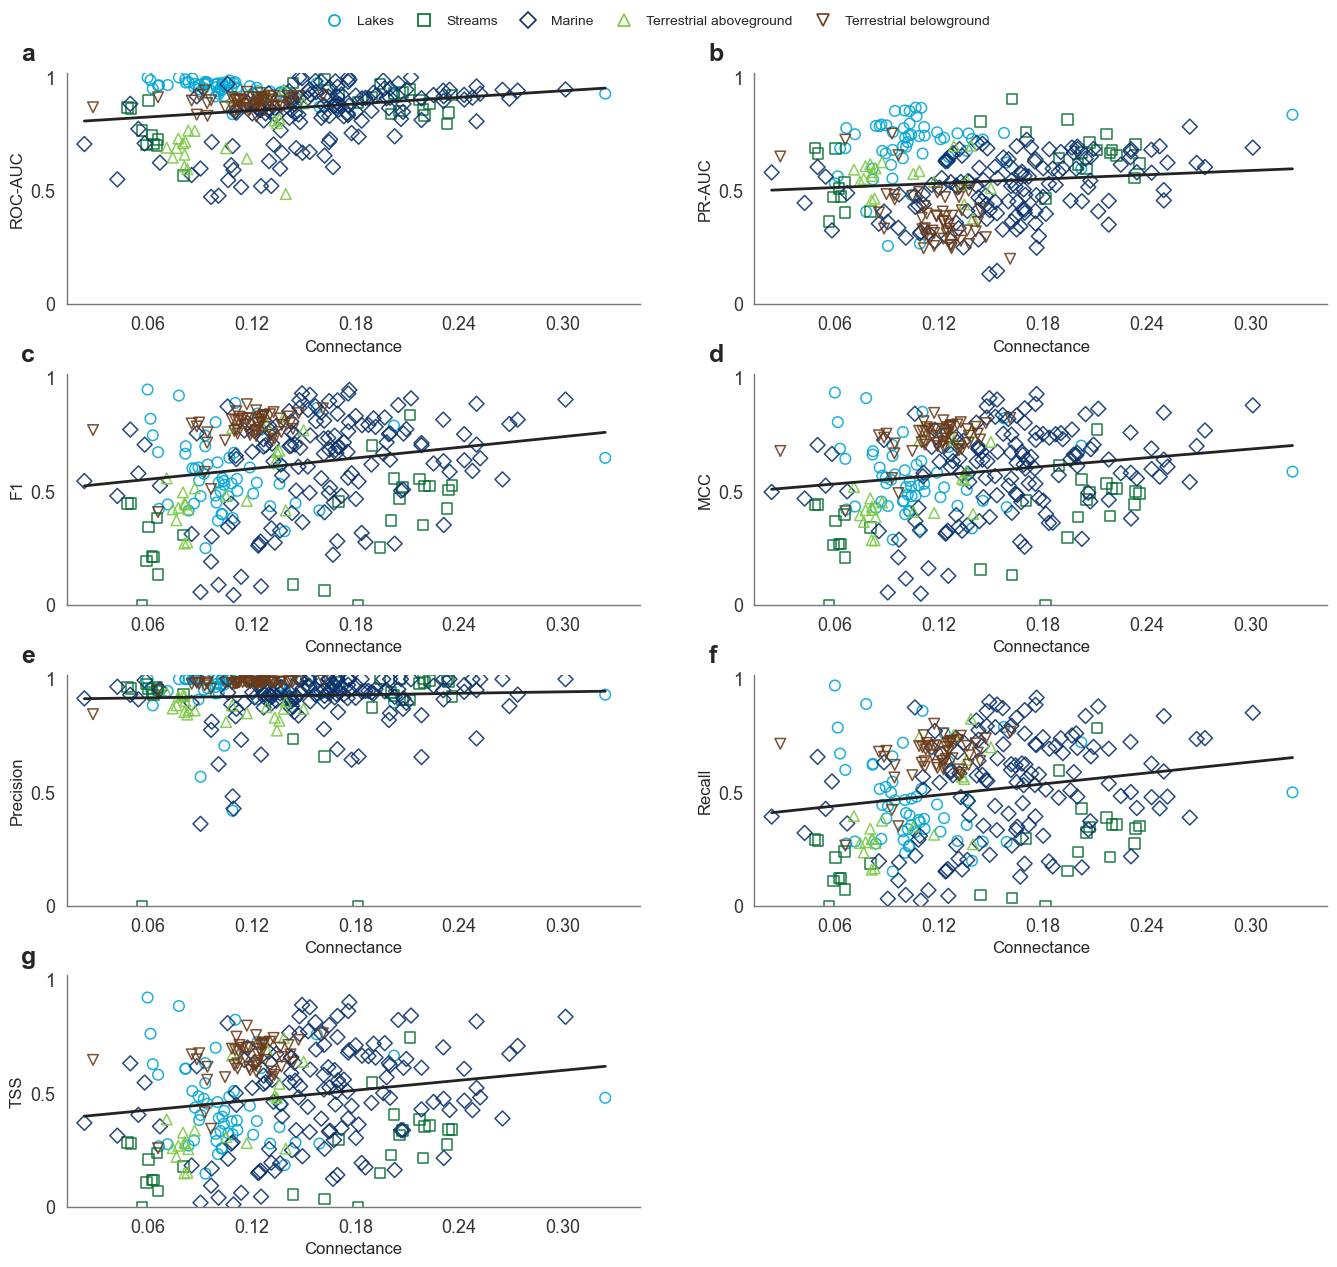

In [3]:
import os
import math
import tempfile

from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(
        Path(tempfile.gettempdir())
        / "qmul_phd_framework_mplconfig"
    ),
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

from matplotlib.lines import Line2D


sns.set_theme(
    style="white",
    context="paper",
    font_scale=1.2,
)


# ============================================================
# Locate project root
# ============================================================

def find_project_root(start=None):
    start = (
        Path.cwd()
        if start is None
        else Path(start).resolve()
    )

    for path in [
        start,
        *start.parents,
    ]:
        if (
            (path / "src/matlab").is_dir()
            and (path / "docs").is_dir()
        ):
            return path

    raise FileNotFoundError(
        "Could not find project root from "
        "current working directory."
    )


PROJECT_ROOT = find_project_root()


# ============================================================
# Final input configuration
# ============================================================

TAU_MASS = 1.00
CHECK_CONNECTIVITY = False
ADAPTIVE_CONNECTIVITY = False
CLASSIFICATION_THRESHOLD = 0.50

K_TARGET = 10
TARGET_RATIO = 90.0
MIN_NODES = 0
AGGREGATE_REPEATS = True

PROTOCOL_NAME = (
    "tukey_iqr_1p5_min50pct_threshold0p50_v1"
)

RESULT_ROOT = (
    PROJECT_ROOT
    / "src/matlab/data"
    / (
        "result_wlnm_dir_neg_50x290_train10-90_"
        "thresh10-90_randomeligible_roleormass_"
        "tau1p00_checkconnfalse_adaptivefalse_Apocrita"
    )
)

PREDICTIVE_INPUT = (
    RESULT_ROOT
    / "retention_protocol"
    / PROTOCOL_NAME
    / "figure_inputs"
    / (
        f"predictive_train{int(TARGET_RATIO)}"
        "_after_tukey.csv"
    )
)

ECOSYSTEM_FILE = (
    PROJECT_ROOT
    / "src/matlab/data/foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)

RUN_MANIFEST = (
    RESULT_ROOT
    / "RUN_MANIFEST.txt"
)


# ============================================================
# Figure configuration — preserved
# ============================================================

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

ecosystem_palette = {
    "Lakes": "#00A6D6",
    "Streams": "#006D2C",
    "Marine": "#08306B",
    "Terrestrial aboveground": "#7AC943",
    "Terrestrial belowground": "#6B3A19",
    "Unknown": "#999999",
}

ecosystem_markers = {
    "Lakes": "o",
    "Streams": "s",
    "Marine": "D",
    "Terrestrial aboveground": "^",
    "Terrestrial belowground": "v",
    "Unknown": "x",
}

ECOSYSTEM_ORDER = [
    "Lakes",
    "Streams",
    "Marine",
    "Terrestrial aboveground",
    "Terrestrial belowground",
]

Y_MIN = 0.0
Y_MAX = 1.0
Y_PAD_TOP = 0.02
N_COLS = 2


# ============================================================
# Helpers
# ============================================================

def normalize_colname(value):
    return (
        str(value)
        .strip()
        .lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb_name(value):
    value = Path(
        str(value).strip()
    ).name

    for extension in (
        ".mat",
        ".csv",
    ):
        if value.lower().endswith(
            extension
        ):
            value = value[
                :-len(extension)
            ].rstrip()

    for suffix in (
        "_tax_mass",
        "_taxmass",
    ):
        if value.lower().endswith(
            suffix
        ):
            value = value[
                :-len(suffix)
            ].rstrip()

    return " ".join(
        value.casefold().split()
    )


def find_column(
    dataframe,
    candidates,
):
    norm_map = {
        normalize_colname(column): column
        for column in dataframe.columns
    }

    for candidate in candidates:
        normalized_candidate = normalize_colname(
            candidate
        )

        if normalized_candidate in norm_map:
            return norm_map[
                normalized_candidate
            ]

    raise KeyError(
        "Could not find any of these columns: "
        f"{candidates}"
    )


def normalize_train_ratio(series):
    values = pd.to_numeric(
        series,
        errors="coerce",
    )

    return np.where(
        values <= 1.0,
        values * 100.0,
        values,
    )


def format_ecosystem_label(name):
    name = str(
        name
    ).strip().lower()

    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": (
            "Terrestrial aboveground"
        ),
        "terrestrial belowground": (
            "Terrestrial belowground"
        ),
        "unknown": "Unknown",
    }

    return label_map.get(
        name,
        str(name).strip().capitalize(),
    )


def report_foodweb_count(
    stage_name,
    before,
    after,
):
    print(
        f"[CHECK] {stage_name}: "
        f"{len(before)} -> {len(after)} food webs"
    )


# ============================================================
# Validate selected inputs
# ============================================================

required_files = {
    "Tukey-filtered predictive input": (
        PREDICTIVE_INPUT
    ),
    "Food-web metadata": (
        ECOSYSTEM_FILE
    ),
    "Run manifest": (
        RUN_MANIFEST
    ),
}

missing_files = [
    f"{label}:\n  {path}"
    for label, path in required_files.items()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "The following required inputs are missing:\n\n"
        + "\n\n".join(
            missing_files
        )
    )


def read_manifest(path):
    manifest = {}

    with path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        for line in handle:
            line = line.strip()

            if (
                not line
                or "=" not in line
            ):
                continue

            key, value = line.split(
                "=",
                1,
            )

            manifest[
                key.strip()
            ] = value.strip()

    return manifest


manifest = read_manifest(
    RUN_MANIFEST
)

expected_manifest = {
    "Version": "WLNM_dir_neg",
    "TauMass": "1.00",
    "CheckConnectivity": "false",
    "AdaptiveConnectivity": "false",
    "NegativeSampling": "random_eligible_pool",
    "Eligibility": "role_or_mass",
    "PrioritySampling": "false",
}

configuration_errors = []

for key, expected_value in expected_manifest.items():
    observed_value = manifest.get(
        key
    )

    if observed_value is None:
        configuration_errors.append(
            f"{key}: missing"
        )
    elif (
        observed_value.casefold()
        != expected_value.casefold()
    ):
        configuration_errors.append(
            f"{key}: expected {expected_value}, "
            f"found {observed_value}"
        )

if configuration_errors:
    raise ValueError(
        "The selected result directory does not match "
        "the requested configuration:\n\n"
        + "\n".join(
            configuration_errors
        )
    )


# ============================================================
# Load Tukey-filtered results
# ============================================================

def load_results(path):
    results = pd.read_csv(
        path
    ).copy()

    required_columns = {
        "Foodweb",
        "K",
        "TrainRatio",
        "Threshold",
        "Metric",
        "MetricFamily",
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "OutlierRunsExcluded",
        "MeetsMinimumRetainedRuns",
    }

    missing_columns = sorted(
        required_columns.difference(
            results.columns
        )
    )

    if missing_columns:
        raise ValueError(
            "The Tukey-filtered input is missing columns:\n  "
            + "\n  ".join(
                missing_columns
            )
        )

    numeric_columns = [
        "K",
        "TrainRatio",
        "Threshold",
        "MeanAfterTukey",
        "RetainedRunsAfterTukey",
        "OutlierRunsExcluded",
        "MeetsMinimumRetainedRuns",
    ]

    for column in numeric_columns:
        results[column] = pd.to_numeric(
            results[column],
            errors="coerce",
        )

    results[
        "TrainRatio"
    ] = normalize_train_ratio(
        results[
            "TrainRatio"
        ]
    )

    metric_columns = [
        metric
        for metric, _
        in METRIC_SPECS
    ]

    results = results.loc[
        results[
            "MetricFamily"
        ]
        .astype(str)
        .str.casefold()
        .eq("predictive")
        & results[
            "Metric"
        ].isin(
            metric_columns
        )
        & np.isclose(
            results[
                "K"
            ],
            K_TARGET,
            equal_nan=False,
        )
        & np.isclose(
            results[
                "TrainRatio"
            ],
            TARGET_RATIO,
            equal_nan=False,
        )
        & np.isclose(
            results[
                "Threshold"
            ],
            CLASSIFICATION_THRESHOLD,
            equal_nan=False,
        )
        & results[
            "MeetsMinimumRetainedRuns"
        ].eq(1)
        & results[
            "MeanAfterTukey"
        ].notna()
    ].copy()

    if results.empty:
        raise RuntimeError(
            "No retained predictive results were found for "
            f"K={K_TARGET}, "
            f"TrainRatio={TARGET_RATIO}, "
            f"Threshold={CLASSIFICATION_THRESHOLD:.2f}."
        )

    results[
        "FoodwebKey"
    ] = results[
        "Foodweb"
    ].apply(
        normalize_foodweb_name
    )

    duplicated = results.duplicated(
        subset=[
            "FoodwebKey",
            "Metric",
        ],
        keep=False,
    )

    if duplicated.any():
        raise ValueError(
            "More than one retained result was found per "
            "food web and metric."
        )

    wide_results = (
        results
        .pivot(
            index=[
                "Foodweb",
                "FoodwebKey",
                "K",
                "TrainRatio",
            ],
            columns="Metric",
            values="MeanAfterTukey",
        )
        .reset_index()
        .copy()
    )

    wide_results.columns.name = None

    print(
        "[INFO] Tukey-filtered input: "
        f"{path}"
    )

    print(
        "[INFO] Food webs in filtered result: "
        f"{wide_results['Foodweb'].nunique()}"
    )

    print(
        "[INFO] Configuration: "
        "tau_mass=1.00, "
        "check_connectivity=False, "
        "adaptive_connectivity=False, "
        "classification_threshold=0.50."
    )

    return wide_results


# ============================================================
# Load food-web metadata
# ============================================================

def load_foodweb_metadata(path):
    metadata = pd.read_csv(
        path
    ).copy()

    foodweb_col = find_column(
        metadata,
        [
            "foodweb",
        ],
    )

    ecosystem_col = find_column(
        metadata,
        [
            "ecosystemtype",
            "ecosystem",
            "ecosystem_type",
        ],
    )

    nodes_col = find_column(
        metadata,
        [
            "nodes",
            "n_nodes",
            "num_nodes",
            "nodecount",
            "s",
        ],
    )

    edges_col = find_column(
        metadata,
        [
            "edges",
            "n_edges",
            "num_edges",
            "edgecount",
            "l",
        ],
    )

    connectance_col = find_column(
        metadata,
        [
            "connectance",
            "c",
        ],
    )

    metadata = metadata.rename(
        columns={
            foodweb_col: (
                "MetadataFoodweb"
            ),
            ecosystem_col: (
                "EcosystemType"
            ),
            nodes_col: (
                "Nodes"
            ),
            edges_col: (
                "Edges"
            ),
            connectance_col: (
                "MetadataConnectance"
            ),
        }
    )

    metadata = metadata[
        [
            "MetadataFoodweb",
            "EcosystemType",
            "Nodes",
            "Edges",
            "MetadataConnectance",
        ]
    ].copy()

    metadata[
        "MetadataFoodweb"
    ] = metadata[
        "MetadataFoodweb"
    ].astype(str)

    metadata[
        "FoodwebKey"
    ] = metadata[
        "MetadataFoodweb"
    ].apply(
        normalize_foodweb_name
    )

    metadata[
        "EcosystemType"
    ] = (
        metadata[
            "EcosystemType"
        ]
        .astype(str)
        .str.strip()
    )

    metadata[
        "Nodes"
    ] = pd.to_numeric(
        metadata[
            "Nodes"
        ],
        errors="coerce",
    )

    metadata[
        "Edges"
    ] = pd.to_numeric(
        metadata[
            "Edges"
        ],
        errors="coerce",
    )

    metadata[
        "MetadataConnectance"
    ] = pd.to_numeric(
        metadata[
            "MetadataConnectance"
        ],
        errors="coerce",
    )

    metadata = (
        metadata
        .drop_duplicates(
            subset=[
                "FoodwebKey",
            ]
        )
        .copy()
    )

    print(
        "[INFO] Food webs in metadata file: "
        f"{metadata['FoodwebKey'].nunique()}"
    )

    return metadata


# ============================================================
# Data preparation
# ============================================================

def prepare_plot_data(
    results,
    metadata,
):
    dataframe = (
        results.merge(
            metadata,
            on="FoodwebKey",
            how="left",
            validate="one_to_one",
        )
        .copy()
    )

    missing_metadata = (
        dataframe[
            "EcosystemType"
        ].isna()
    )

    if missing_metadata.any():
        missing_foodwebs = sorted(
            dataframe.loc[
                missing_metadata,
                "Foodweb",
            ]
            .astype(str)
            .unique()
        )

        raise ValueError(
            "Metadata could not be matched for "
            f"{len(missing_foodwebs)} food webs:\n  "
            + "\n  ".join(
                missing_foodwebs[:30]
            )
        )

    numeric_columns = [
        "K",
        "TrainRatio",
        "ROC_AUC",
        "PR_AUC",
        "Precision",
        "Recall",
        "F1Score",
        "TestMCC",
        "TestTSS",
        "Nodes",
        "Edges",
        "MetadataConnectance",
    ]

    existing_numeric_columns = [
        column
        for column in numeric_columns
        if column in dataframe.columns
    ]

    dataframe[
        existing_numeric_columns
    ] = dataframe[
        existing_numeric_columns
    ].apply(
        pd.to_numeric,
        errors="coerce",
    )

    dataframe[
        "EmpiricalConnectanceForPlot"
    ] = dataframe[
        "MetadataConnectance"
    ]

    missing_connectance = (
        dataframe[
            "EmpiricalConnectanceForPlot"
        ].isna()
    )

    can_compute_connectance = (
        missing_connectance
        & dataframe[
            "Nodes"
        ].notna()
        & dataframe[
            "Edges"
        ].notna()
        & (
            dataframe[
                "Nodes"
            ]
            > 1
        )
    )

    dataframe.loc[
        can_compute_connectance,
        "EmpiricalConnectanceForPlot",
    ] = (
        dataframe.loc[
            can_compute_connectance,
            "Edges",
        ]
        / (
            dataframe.loc[
                can_compute_connectance,
                "Nodes",
            ]
            * (
                dataframe.loc[
                    can_compute_connectance,
                    "Nodes",
                ]
                - 1
            )
        )
    )

    dataframe[
        "EcosystemType"
    ] = dataframe[
        "EcosystemType"
    ].fillna(
        "Unknown"
    )

    before = set(
        dataframe[
            "Foodweb"
        ]
        .dropna()
        .unique()
    )

    if K_TARGET is not None:
        dataframe = dataframe.loc[
            np.isclose(
                dataframe[
                    "K"
                ],
                K_TARGET,
                equal_nan=False,
            )
        ].copy()

        after = set(
            dataframe[
                "Foodweb"
            ]
            .dropna()
            .unique()
        )

        report_foodweb_count(
            f"K = {K_TARGET}",
            before,
            after,
        )

        before = after

    dataframe = dataframe.loc[
        np.isclose(
            dataframe[
                "TrainRatio"
            ],
            TARGET_RATIO,
            equal_nan=False,
        )
    ].copy()

    after = set(
        dataframe[
            "Foodweb"
        ]
        .dropna()
        .unique()
    )

    report_foodweb_count(
        f"TrainRatio = {TARGET_RATIO}",
        before,
        after,
    )

    before = after

    if MIN_NODES > 0:
        dataframe = dataframe.loc[
            dataframe[
                "Nodes"
            ]
            >= MIN_NODES
        ].copy()
    else:
        dataframe = dataframe.loc[
            (
                dataframe[
                    "Nodes"
                ]
                >= MIN_NODES
            )
            | dataframe[
                "Nodes"
            ].isna()
        ].copy()

    after = set(
        dataframe[
            "Foodweb"
        ]
        .dropna()
        .unique()
    )

    report_foodweb_count(
        f"Nodes >= {MIN_NODES}",
        before,
        after,
    )

    missing_metrics = [
        metric
        for metric, _
        in METRIC_SPECS
        if metric not in dataframe.columns
    ]

    if missing_metrics:
        raise RuntimeError(
            "Missing required metric columns: "
            f"{missing_metrics}"
        )

    if AGGREGATE_REPEATS:
        group_columns = [
            "Foodweb",
            "FoodwebKey",
            "K",
            "TrainRatio",
            "EmpiricalConnectanceForPlot",
            "Nodes",
            "Edges",
            "EcosystemType",
        ]

        mean_columns = [
            metric
            for metric, _
            in METRIC_SPECS
        ]

        dataframe = (
            dataframe
            .groupby(
                group_columns,
                dropna=False,
                as_index=False,
            )[
                mean_columns
            ]
            .mean()
            .copy()
        )

    before_connectance = set(
        dataframe[
            "Foodweb"
        ]
        .dropna()
        .unique()
    )

    dataframe = (
        dataframe
        .dropna(
            subset=[
                "EmpiricalConnectanceForPlot",
            ]
        )
        .copy()
    )

    after_connectance = set(
        dataframe[
            "Foodweb"
        ]
        .dropna()
        .unique()
    )

    report_foodweb_count(
        "available connectance for x-axis",
        before_connectance,
        after_connectance,
    )

    metric_columns = [
        metric
        for metric, _
        in METRIC_SPECS
    ]

    metric_availability = (
        dataframe[
            [
                "Foodweb",
                *metric_columns,
            ]
        ]
        .assign(
            HasAnySelectedMetric=lambda frame: (
                frame[
                    metric_columns
                ]
                .notna()
                .any(
                    axis=1
                )
            )
        )
        .copy()
    )

    foodwebs_without_metrics = (
        metric_availability.loc[
            ~metric_availability[
                "HasAnySelectedMetric"
            ],
            "Foodweb",
        ]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    print(
        "[FINAL] Food webs retained after "
        "structural filters: "
        f"{dataframe['Foodweb'].nunique()}"
    )

    if foodwebs_without_metrics:
        print(
            "[INFO] Food webs retained but not plotted "
            "because all selected metrics are missing:"
        )

        for foodweb in foodwebs_without_metrics:
            print(
                f"  - {foodweb}"
            )

    return dataframe.copy()


# ============================================================
# Regression helpers — preserved
# ============================================================

def fit_linear_regression(
    data,
    metric,
    n_points=100,
):
    work = (
        data[
            [
                "EmpiricalConnectanceForPlot",
                metric,
            ]
        ]
        .dropna()
        .copy()
    )

    if work.empty:
        return None

    work[
        "EmpiricalConnectanceForPlot"
    ] = work[
        "EmpiricalConnectanceForPlot"
    ].astype(float)

    work[
        metric
    ] = work[
        metric
    ].astype(float)

    if (
        len(work) < 3
        or work[
            "EmpiricalConnectanceForPlot"
        ].nunique() < 2
    ):
        return None

    x = work[
        [
            "EmpiricalConnectanceForPlot",
        ]
    ]

    y = work[
        metric
    ]

    x_model = sm.add_constant(
        x,
        has_constant="add",
    )

    model = sm.OLS(
        y,
        x_model,
    ).fit()

    intercept = model.params[
        "const"
    ]

    slope = model.params[
        "EmpiricalConnectanceForPlot"
    ]

    x_line = np.linspace(
        work[
            "EmpiricalConnectanceForPlot"
        ].min(),
        work[
            "EmpiricalConnectanceForPlot"
        ].max(),
        n_points,
    )

    x_line_model = pd.DataFrame({
        "EmpiricalConnectanceForPlot": (
            x_line
        )
    })

    x_line_model = sm.add_constant(
        x_line_model,
        has_constant="add",
    )

    y_line = model.predict(
        x_line_model
    )

    return {
        "x_line": x_line,
        "y_line": y_line,
        "slope": slope,
        "intercept": intercept,
        "r_squared": model.rsquared,
        "p_value": model.pvalues[
            "EmpiricalConnectanceForPlot"
        ],
        "f_value": model.fvalue,
        "df_model": int(
            model.df_model
        ),
        "df_resid": int(
            model.df_resid
        ),
        "n": len(work),
        "model": model,
    }


def format_equation(
    slope,
    intercept,
):
    sign = (
        "+"
        if intercept >= 0
        else "-"
    )

    return (
        f"y = {slope:.4f}x "
        f"{sign} {abs(intercept):.4f}"
    )


def format_p_value(p_value):
    if p_value < 0.0001:
        return "P < 0.0001"

    return (
        f"P = {p_value:.4f}"
    )


# ============================================================
# Plotting — original styling preserved
# ============================================================

def style_axes(
    ax,
    ylabel,
):
    ax.set_ylabel(
        ylabel,
        fontsize=12,
    )

    ax.set_xlabel(
        "Connectance",
        fontsize=12,
    )

    ax.grid(
        False
    )

    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )

    ax.spines[
        "left"
    ].set_color(
        "#777777"
    )

    ax.spines[
        "bottom"
    ].set_color(
        "#777777"
    )

    ax.tick_params(
        axis="both",
        colors="#333333",
        labelsize=13,
    )


def plot_performance_vs_connectance(
    plot_dataframe,
):
    available_ecosystems = (
        plot_dataframe[
            "EcosystemType"
        ]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    available_by_label = {
        format_ecosystem_label(
            ecosystem
        ): ecosystem
        for ecosystem
        in available_ecosystems
    }

    eco_order = [
        available_by_label[label]
        for label in ECOSYSTEM_ORDER
        if label in available_by_label
    ]

    eco_order += [
        ecosystem
        for ecosystem
        in available_ecosystems
        if ecosystem
        not in eco_order
    ]

    plot_dataframe = (
        plot_dataframe.copy()
    )

    plot_dataframe[
        "EcosystemType"
    ] = pd.Categorical(
        plot_dataframe[
            "EcosystemType"
        ],
        categories=eco_order,
        ordered=True,
    )

    eco_palette = {
        ecosystem: ecosystem_palette.get(
            format_ecosystem_label(
                ecosystem
            ),
            "#999999",
        )
        for ecosystem
        in eco_order
    }

    eco_markers = {
        ecosystem: ecosystem_markers.get(
            format_ecosystem_label(
                ecosystem
            ),
            "o",
        )
        for ecosystem
        in eco_order
    }

    n_panels = len(
        METRIC_SPECS
    )

    n_rows = math.ceil(
        n_panels / N_COLS
    )

    fig, axes = plt.subplots(
        n_rows,
        N_COLS,
        figsize=(
            14,
            14,
        ),
        sharex=False,
        sharey=False,
    )

    axes = np.array(
        axes
    ).reshape(-1)

    panel_letters = list(
        "abcdefghijklmnopqrstuvwxyz"
    )

    total_foodwebs = (
        plot_dataframe[
            "Foodweb"
        ]
        .nunique()
    )

    x_min = plot_dataframe[
        "EmpiricalConnectanceForPlot"
    ].min()

    x_max = plot_dataframe[
        "EmpiricalConnectanceForPlot"
    ].max()

    print(
        "\n=== OLS linear regression: "
        "metric ~ empirical connectance ==="
    )

    for index, (
        (
            metric,
            label,
        ),
        ax,
    ) in enumerate(
        zip(
            METRIC_SPECS,
            axes,
        )
    ):
        data = (
            plot_dataframe
            .dropna(
                subset=[
                    "EmpiricalConnectanceForPlot",
                    metric,
                ]
            )
            .copy()
        )

        n_metric_foodwebs = (
            data[
                "Foodweb"
            ]
            .nunique()
        )

        for ecosystem in eco_order:
            ecosystem_data = data.loc[
                data[
                    "EcosystemType"
                ]
                == ecosystem
            ]

            if ecosystem_data.empty:
                continue

            ax.scatter(
                ecosystem_data[
                    "EmpiricalConnectanceForPlot"
                ],
                ecosystem_data[
                    metric
                ],
                marker=eco_markers[
                    ecosystem
                ],
                facecolors="none",
                edgecolors=eco_palette[
                    ecosystem
                ],
                linewidths=1.1,
                s=58,
                alpha=0.88,
                label=format_ecosystem_label(
                    ecosystem
                ),
            )

        fit = fit_linear_regression(
            data,
            metric,
        )

        if fit is not None:
            ax.plot(
                fit[
                    "x_line"
                ],
                fit[
                    "y_line"
                ],
                color="#232323",
                linewidth=2.0,
                linestyle="-",
                zorder=5,
            )

            equation = format_equation(
                fit[
                    "slope"
                ],
                fit[
                    "intercept"
                ],
            )

            p_text = format_p_value(
                fit[
                    "p_value"
                ]
            )

            print(
                f"{panel_letters[index]}) "
                f"{label}: "
                f"{equation}; "
                f"F{fit['df_model']},"
                f"{fit['df_resid']} = "
                f"{fit['f_value']:.4f}; "
                f"R² = "
                f"{fit['r_squared']:.4f}; "
                f"{p_text}; "
                f"n = {fit['n']}"
            )

        else:
            print(
                f"{panel_letters[index]}) "
                f"{label}: "
                "regression not fitted; "
                "insufficient data."
            )

        style_axes(
            ax,
            label,
        )

        ax.set_ylim(
            Y_MIN,
            Y_MAX + Y_PAD_TOP,
        )

        ax.set_xlim(
            max(
                0.0,
                x_min - 0.01,
            ),
            x_max + 0.02,
        )

        ax.set_yticks([
            0,
            0.5,
            1.0,
        ])

        ax.set_yticklabels([
            "0",
            "0.5",
            "1",
        ])

        ax.xaxis.set_major_locator(
            plt.MaxNLocator(6)
        )

        ax.text(
            -0.08,
            1.03,
            panel_letters[
                index
            ],
            transform=ax.transAxes,
            fontsize=18,
            fontweight="bold",
            va="bottom",
            ha="left",
            clip_on=False,
        )

    for panel_index in range(
        n_panels,
        len(axes),
    ):
        axes[
            panel_index
        ].set_axis_off()

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker=eco_markers[
                ecosystem
            ],
            linestyle="",
            markersize=8,
            markerfacecolor="none",
            markeredgecolor=eco_palette[
                ecosystem
            ],
            markeredgewidth=1.2,
            label=format_ecosystem_label(
                ecosystem
            ),
        )
        for ecosystem
        in eco_order
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(
            0.5,
            0.95,
        ),
        ncol=min(
            len(eco_order),
            5,
        ),
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,
        fontsize=10,
    )

    fig.subplots_adjust(
        top=0.90,
        hspace=0.3,
        wspace=0.2,
        left=0.08,
        right=0.98,
        bottom=0.09,
    )

    return fig


# ============================================================
# Run
# ============================================================

results = load_results(
    PREDICTIVE_INPUT
)

metadata = load_foodweb_metadata(
    ECOSYSTEM_FILE
)

plot_df = prepare_plot_data(
    results,
    metadata,
)

fig = plot_performance_vs_connectance(
    plot_df
)

plt.show()